# 1. Introduction
Before developing quantitative features, it is necessary to verify that the Level2 data stored in DolphinDB is accurate, complete, and internally consistent.

This notebook validates the dfs://quota database against an external data source (Wind / JoinQuant / iFinD / Exchange data) from five different levels.

 | Validation Level | Objective                     | Data Source    |
| ---------------- | ----------------------------- | -------------- |
| Daily            | Verify overall price & volume | CoralDB           |
| Minute           | Verify intraday aggregation   | CoralDB qmin      |
| Auction          | Verify opening auction        | CoralDB + qtick   |
| Tick             | Verify qknock aggregation     | qknock + qtick |
| Logical          | Verify internal consistency   | quota          |


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

from src.ddb_client import connect_ddb

plt.rcParams["figure.figsize"] = (12, 5)

s = connect_ddb()

DB = "dfs://quota"
CODE = "000009.SZ"
START_DATE = "2026.03.11"
END_DATE = "2026.04.10"

START_DATE_PD = pd.to_datetime("2026-03-11")
END_DATE_PD = pd.to_datetime("2026-04-10")

### 从 DolphinDB 取本地 qtick / qknock 数据

In [7]:
qtick = s.run(f"""
select *
from loadTable("{DB}", "qtick")
where code = "{CODE}"
and date >= {START_DATE}
and date <= {END_DATE}
""")
qknock = s.run(f"""
select *
from loadTable("{DB}", "qknock")
where code = "{CODE}"
and date >= {START_DATE}
and date <= {END_DATE}
""")
qorder = s.run(f"""
select *
from loadTable("{DB}", "qorder")
where code = "{CODE}"
and date >= {START_DATE}
and date <= {END_DATE}
""")
print("qtick rows:", len(qtick))
print("qknock rows:", len(qknock))
print("qorder rows:", len(qorder))

qtick rows: 102485
qknock rows: 735794
qorder rows: 819766


### 本地数据基础清洗

In [8]:
def clean_time(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.dropna(subset=["date", "time"])
    df["datetime"] = df.apply(
        lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
        axis=1
    )
    return df.sort_values(["date", "datetime"]).reset_index(drop=True)

qtick = clean_time(qtick)
qknock = clean_time(qknock)

for col in ["new_price", "open", "pre_close", "sum_volume", "sum_amount", "new_volume", "new_amount"]:
    if col in qtick.columns:
        qtick[col] = pd.to_numeric(qtick[col], errors="coerce")

for col in ["match_price", "match_volume"]:
    if col in qknock.columns:
        qknock[col] = pd.to_numeric(qknock[col], errors="coerce")

# Daily Validation

Does the daily market summary stored in DolphinDB match the external CoralDB data?

The purpose of this section is to verify whether the daily market statistics extracted from DolphinDB are consistent with an independent external data source before conducting feature engineering and predictive modelling.

The comparison focuses on:

Open
High
Low
Trading Volume
Trading Amount

In [9]:
import pandas as pd

coral_daily = pd.read_csv("quota/000009.SZ.daily.csv")
coral_daily.head()

,timestamp,date,stamp,dtype,code,name,market,sum_volume,sum_amount,status,...,expire_date,exercise_price,cp_flag,underlying_code,min_order_volume,interest,sum_bid_volume,sum_bid_amount,sum_ask_volume,sum_ask_amount
0,2026-03-11 15:00:00,20260311,150000000,1,000009.SZ,中国宝安,2,35100859,326085012.0,0,...,0,0.0,0,NaN,0,0.0,20082640,1.866095e+08,15018219,1.394755e+08
1,2026-03-12 15:00:00,20260312,150000000,1,000009.SZ,中国宝安,2,24742202,227366309.0,0,...,0,0.0,0,NaN,0,0.0,9501565,8.739167e+07,15240637,1.399746e+08
2,2026-03-13 15:00:00,20260313,150000000,1,000009.SZ,中国宝安,2,63733398,604637179.0,0,...,0,0.0,0,NaN,0,0.0,39546186,3.752053e+08,24187212,2.294319e+08
3,2026-03-16 15:00:00,20260316,150000000,1,000009.SZ,中国宝安,2,34285345,322788160.0,0,...,0,0.0,0,NaN,0,0.0,14445442,1.361430e+08,19839903,1.866452e+08
4,2026-03-17 15:00:00,20260317,150000000,1,000009.SZ,中国宝安,2,23559418,220053681.0,0,...,0,0.0,0,NaN,0,0.0,8462420,7.915037e+07,15096998,1.409033e+08


In [11]:
# 1 clean the coral_daily data
coral_daily_clean = coral_daily.copy()

coral_daily_clean["date"] = pd.to_datetime(
    coral_daily_clean["date"].astype(str),
    format="%Y%m%d"
)

coral_daily_clean = coral_daily_clean[
    ["date", "open", "high", "low", "new_price", "pre_close", "sum_volume", "sum_amount"]
].copy()

coral_daily_clean = coral_daily_clean.rename(columns={
    "open": "coral_open",
    "high": "coral_high",
    "low": "coral_low",
    "new_price": "coral_close_proxy",
    "pre_close": "coral_pre_close",
    "sum_volume": "coral_volume",
    "sum_amount": "coral_amount"
})

coral_daily_clean.head()

,date,coral_open,coral_high,coral_low,coral_close_proxy,coral_pre_close,coral_volume,coral_amount
0,2026-03-11,9.18,9.39,9.13,9.29,9.18,35100859,326085012.0
1,2026-03-12,9.28,9.28,9.11,9.19,9.29,24742202,227366309.0
2,2026-03-13,9.15,9.69,9.15,9.47,9.19,63733398,604637179.0
3,2026-03-16,9.55,9.59,9.33,9.38,9.47,34285345,322788160.0
4,2026-03-17,9.40,9.52,9.20,9.21,9.38,23559418,220053681.0


In the CoralDB daily file, the `close` field is zero for all observations. Therefore, this validation uses `new_price` at 15:00 as the CoralDB close proxy.

In [12]:
# 2 build local daily data from qtick
qtick_local = qtick.copy()

qtick_local["date"] = pd.to_datetime(qtick_local["date"], errors="coerce")
qtick_local["time"] = pd.to_datetime(qtick_local["time"], errors="coerce")

qtick_local = qtick_local.dropna(subset=["date", "time"])

qtick_local["datetime"] = qtick_local.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

qtick_local = qtick_local.sort_values(["date", "datetime"]).reset_index(drop=True)

num_cols = [
    "new_price",
    "open",
    "close",
    "pre_close",
    "sum_volume",
    "sum_amount"
]

for col in num_cols:
    qtick_local[col] = pd.to_numeric(qtick_local[col], errors="coerce")

valid_tick = qtick_local[qtick_local["new_price"] > 0].copy()

local_daily = (
    valid_tick
    .groupby("date")
    .agg(
        local_open=("open", "last"),
        local_high=("new_price", "max"),
        local_low=("new_price", "min"),
        local_close_proxy=("new_price", "last"),
        local_close_field=("close", "last"),
        local_pre_close=("pre_close", "last"),
        local_volume=("sum_volume", "max"),
        local_amount=("sum_amount", "max")
    )
    .reset_index()
)

local_daily.head()

,date,local_open,local_high,local_low,local_close_proxy,local_close_field,local_pre_close,local_volume,local_amount
0,2026-03-11,9.18,9.39,9.13,9.29,0.0,9.18,35100859,326085012.0
1,2026-03-12,9.28,9.28,9.11,9.19,0.0,9.29,24742202,227366309.0
2,2026-03-13,9.15,9.69,9.15,9.47,0.0,9.19,63733398,604637179.0
3,2026-03-16,9.55,9.59,9.33,9.38,0.0,9.47,34285345,322788160.0
4,2026-03-17,9.40,9.52,9.20,9.21,0.0,9.38,23559418,220053681.0


Because the local `qtick` table does not directly store daily `high` and `low`, they are reconstructed from intraday `new_price` as `max(new_price)` and `min(new_price)`. Since CoralDB's `close` field is zero, we use its 15:00 `new_price` as the close proxy.

In [13]:
# 3 merge coral_daily_clean and local_daily
daily_compare = local_daily.merge(
    coral_daily_clean,
    on="date",
    how="inner"
)

daily_compare.columns.tolist()

['date',
 'local_open',
 'local_high',
 'local_low',
 'local_close_proxy',
 'local_close_field',
 'local_pre_close',
 'local_volume',
 'local_amount',
 'coral_open',
 'coral_high',
 'coral_low',
 'coral_close_proxy',
 'coral_pre_close',
 'coral_volume',
 'coral_amount']

In [14]:
# 4 check the differences between local_daily and coral_daily_clean
compare_fields = [
    ("open", "local_open", "coral_open"),
    ("high", "local_high", "coral_high"),
    ("low", "local_low", "coral_low"),
    ("close_proxy", "local_close_proxy", "coral_close_proxy"),
    ("pre_close", "local_pre_close", "coral_pre_close"),
    ("volume", "local_volume", "coral_volume"),
    ("amount", "local_amount", "coral_amount")
]

for name, local_col, coral_col in compare_fields:
    daily_compare[f"{name}_diff"] = (
        daily_compare[local_col] - daily_compare[coral_col]
    )
    
    daily_compare[f"{name}_diff_pct"] = (
        daily_compare[f"{name}_diff"] /
        daily_compare[coral_col].replace(0, np.nan)
    )

daily_compare.head()

,date,local_open,local_high,local_low,local_close_proxy,local_close_field,local_pre_close,local_volume,local_amount,coral_open,...,low_diff,low_diff_pct,close_proxy_diff,close_proxy_diff_pct,pre_close_diff,pre_close_diff_pct,volume_diff,volume_diff_pct,amount_diff,amount_diff_pct
0,2026-03-11,9.18,9.39,9.13,9.29,0.0,9.18,35100859,326085012.0,9.18,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
1,2026-03-12,9.28,9.28,9.11,9.19,0.0,9.29,24742202,227366309.0,9.28,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
2,2026-03-13,9.15,9.69,9.15,9.47,0.0,9.19,63733398,604637179.0,9.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
3,2026-03-16,9.55,9.59,9.33,9.38,0.0,9.47,34285345,322788160.0,9.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
4,2026-03-17,9.40,9.52,9.20,9.21,0.0,9.38,23559418,220053681.0,9.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0


In [15]:
# 5 validation summary
PRICE_TOL = 0.01
VOLUME_TOL_PCT = 0.001
AMOUNT_TOL_PCT = 0.001

summary_rows = []

for field in ["open", "high", "low", "close_proxy", "pre_close"]:
    diff_col = f"{field}_diff"
    matched = daily_compare[diff_col].abs() <= PRICE_TOL
    
    summary_rows.append({
        "field": field,
        "tolerance": PRICE_TOL,
        "matched_days": matched.sum(),
        "total_days": len(daily_compare),
        "match_rate": matched.mean()
    })

for field, tol in [("volume", VOLUME_TOL_PCT), ("amount", AMOUNT_TOL_PCT)]:
    diff_pct_col = f"{field}_diff_pct"
    matched = daily_compare[diff_pct_col].abs() <= tol
    
    summary_rows.append({
        "field": field,
        "tolerance": tol,
        "matched_days": matched.sum(),
        "total_days": len(daily_compare),
        "match_rate": matched.mean()
    })

validation_summary = pd.DataFrame(summary_rows)

validation_summary

,field,tolerance,matched_days,total_days,match_rate
0,open,0.010,22,22,1.0
1,high,0.010,22,22,1.0
2,low,0.010,22,22,1.0
3,close_proxy,0.010,22,22,1.0
4,pre_close,0.010,22,22,1.0
5,volume,0.001,22,22,1.0
6,amount,0.001,22,22,1.0


In [16]:
# 6 show abnormal samples
daily_compare["has_abnormal_diff"] = False

for field in ["open", "high", "low", "close_proxy", "pre_close"]:
    daily_compare["has_abnormal_diff"] |= (
        daily_compare[f"{field}_diff"].abs() > PRICE_TOL
    )

for field, tol in [("volume", VOLUME_TOL_PCT), ("amount", AMOUNT_TOL_PCT)]:
    daily_compare["has_abnormal_diff"] |= (
        daily_compare[f"{field}_diff_pct"].abs() > tol
    )

abnormal_daily = daily_compare[daily_compare["has_abnormal_diff"]].copy()

abnormal_daily[
    [
        "date",
        "local_open", "coral_open", "open_diff",
        "local_high", "coral_high", "high_diff",
        "local_low", "coral_low", "low_diff",
        "local_close_proxy", "coral_close_proxy", "close_proxy_diff",
        "local_volume", "coral_volume", "volume_diff_pct",
        "local_amount", "coral_amount", "amount_diff_pct"
    ]
]

,date,local_open,coral_open,open_diff,local_high,coral_high,high_diff,local_low,coral_low,low_diff,local_close_proxy,coral_close_proxy,close_proxy_diff,local_volume,coral_volume,volume_diff_pct,local_amount,coral_amount,amount_diff_pct


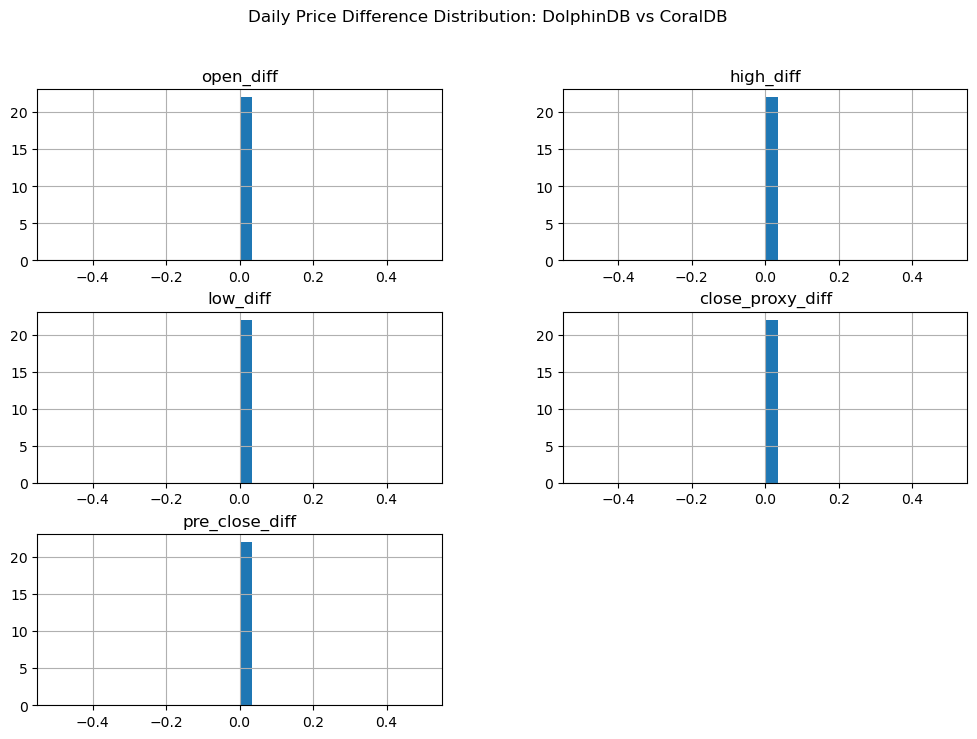

In [17]:
# 7 daily difference visualization
import matplotlib.pyplot as plt

price_diff_cols = [
    "open_diff",
    "high_diff",
    "low_diff",
    "close_proxy_diff",
    "pre_close_diff"
]

daily_compare[price_diff_cols].hist(
    bins=30,
    figsize=(12, 8)
)

plt.suptitle("Daily Price Difference Distribution: DolphinDB vs CoralDB")
plt.show()

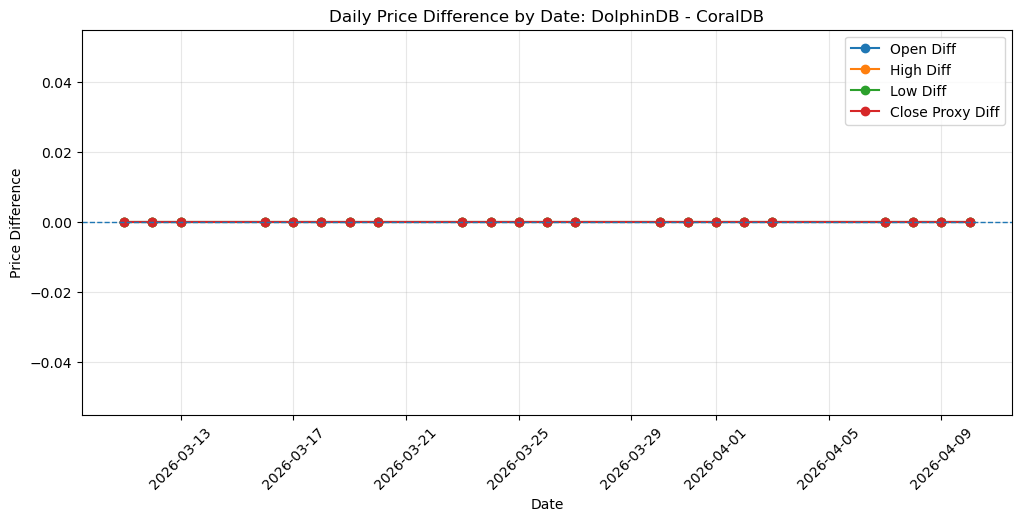

In [18]:
# 8. Difference by Date

plt.figure(figsize=(12, 5))

plt.plot(daily_compare["date"], daily_compare["open_diff"], marker="o", label="Open Diff")
plt.plot(daily_compare["date"], daily_compare["high_diff"], marker="o", label="High Diff")
plt.plot(daily_compare["date"], daily_compare["low_diff"], marker="o", label="Low Diff")
plt.plot(daily_compare["date"], daily_compare["close_proxy_diff"], marker="o", label="Close Proxy Diff")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Daily Price Difference by Date: DolphinDB - CoralDB")
plt.xlabel("Date")
plt.ylabel("Price Difference")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

The daily validation shows that DolphinDB and CoralDB are highly consistent
across all tested trading days.

No material discrepancies were observed in:

- Open
- High
- Low
- Closing price (using 15:00 new_price proxy)
- Previous close
- Trading volume
- Trading amount

Since no abnormal samples were detected, subsequent validation will focus on
higher-frequency data (minute-level, auction snapshots and transaction records),
where timestamp alignment and data synchronization differences are more likely
to appear.

# Minute-level Validation
Can minute-level OHLCV bars reconstructed from DolphinDB qtick match the external CoralDB minute bars?

In [19]:
# 1 读所有coral qmin文件
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

QMIN_DIR = Path("quota/qmin")

qmin_files = sorted(QMIN_DIR.glob("*/000009.SZ.csv"))

print("Number of qmin files:", len(qmin_files))
print(qmin_files[:3])

Number of qmin files: 22
[WindowsPath('quota/qmin/20260311/000009.SZ.csv'), WindowsPath('quota/qmin/20260312/000009.SZ.csv'), WindowsPath('quota/qmin/20260313/000009.SZ.csv')]


In [20]:
coral_qmin_list = []

for file in qmin_files:
    temp = pd.read_csv(file)
    temp["source_file"] = str(file)
    coral_qmin_list.append(temp)

coral_qmin = pd.concat(coral_qmin_list, ignore_index=True)

print("Coral qmin rows:", len(coral_qmin))
coral_qmin.head()

Coral qmin rows: 5280


,timestamp,date,stamp,dtype,code,name,market,sum_volume,sum_amount,status,...,exercise_price,cp_flag,underlying_code,min_order_volume,interest,sum_bid_volume,sum_bid_amount,sum_ask_volume,sum_ask_amount,source_file
0,2026-03-11 09:31:00,20260311,93100000,1,000009.SZ,中国宝安,2,397200,3637990.0,0,...,0.0,0,NaN,0,0.0,170200,1559015.00,227000,2078975.00,quota\qmin\20260311\000009.SZ.csv
1,2026-03-11 09:32:00,20260311,93200000,1,000009.SZ,中国宝安,2,518900,4752289.0,0,...,0.0,0,NaN,0,0.0,257800,2361156.00,261100,2391133.00,quota\qmin\20260311\000009.SZ.csv
2,2026-03-11 09:33:00,20260311,93300000,1,000009.SZ,中国宝安,2,774700,7094138.0,0,...,0.0,0,NaN,0,0.0,434100,3975542.00,340600,3118596.00,quota\qmin\20260311\000009.SZ.csv
3,2026-03-11 09:34:00,20260311,93400000,1,000009.SZ,中国宝安,2,928700,8505699.0,0,...,0.0,0,NaN,0,0.0,477100,4369796.00,451600,4135903.00,quota\qmin\20260311\000009.SZ.csv
4,2026-03-11 09:35:00,20260311,93500000,1,000009.SZ,中国宝安,2,1025300,9391256.0,0,...,0.0,0,NaN,0,0.0,546772,5008668.24,478528,4382587.76,quota\qmin\20260311\000009.SZ.csv


In [21]:
# 2 整理 Coral qmin，并转成 1min OHLCV
coral_min = coral_qmin.copy()

coral_min["timestamp"] = pd.to_datetime(coral_min["timestamp"], errors="coerce")
coral_min["date"] = pd.to_datetime(coral_min["date"].astype(str), format="%Y%m%d", errors="coerce")

for col in ["new_price", "sum_volume", "sum_amount"]:
    coral_min[col] = pd.to_numeric(coral_min[col], errors="coerce")

coral_min = coral_min.dropna(subset=["timestamp", "date"])
coral_min = coral_min.sort_values(["date", "timestamp"]).reset_index(drop=True)

# Coral qmin 每行已经是分钟级 snapshot。
# 价格 close 用该分钟 timestamp 的 new_price。
# 由于 qmin 每分钟只有一行，OHLC 在 Coral 侧只能用这一分钟 snapshot 的 new_price 作为 close。
# 真正的 minute volume/amount 用累计字段差分。
coral_min["coral_close"] = coral_min["new_price"]
coral_min["coral_volume"] = coral_min.groupby("date")["sum_volume"].diff()
coral_min["coral_amount"] = coral_min.groupby("date")["sum_amount"].diff()

# 第一根分钟线没有上一分钟，直接用当前累计量作为本分钟量
coral_min["coral_volume"] = coral_min["coral_volume"].fillna(coral_min["sum_volume"])
coral_min["coral_amount"] = coral_min["coral_amount"].fillna(coral_min["sum_amount"])

coral_1min = coral_min[[
    "date",
    "timestamp",
    "coral_close",
    "coral_volume",
    "coral_amount"
]].copy()

coral_1min.head()

,date,timestamp,coral_close,coral_volume,coral_amount
0,2026-03-11,2026-03-11 09:31:00,9.17,397200.0,3637990.0
1,2026-03-11,2026-03-11 09:32:00,9.15,121700.0,1114299.0
2,2026-03-11,2026-03-11 09:33:00,9.16,255800.0,2341849.0
3,2026-03-11,2026-03-11 09:34:00,9.16,154000.0,1411561.0
4,2026-03-11,2026-03-11 09:35:00,9.16,96600.0,885557.0


In [22]:
# 3 用 qtick 聚合本地 1min OHLCV
qtick_min = qtick.copy()

qtick_min["date"] = pd.to_datetime(qtick_min["date"], errors="coerce")
qtick_min["time"] = pd.to_datetime(qtick_min["time"], errors="coerce")

qtick_min = qtick_min.dropna(subset=["date", "time"])

qtick_min["datetime"] = qtick_min.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

for col in ["new_price", "sum_volume", "sum_amount"]:
    qtick_min[col] = pd.to_numeric(qtick_min[col], errors="coerce")

qtick_min = qtick_min[
    (qtick_min["new_price"] > 0)
].copy()

qtick_min = qtick_min.sort_values(["date", "datetime"]).reset_index(drop=True)

# 对齐到分钟。这里用右标签：09:31 表示截至 09:31 的分钟状态，更接近 Coral qmin timestamp。
qtick_min["minute"] = qtick_min["datetime"].dt.floor("min") + pd.Timedelta(minutes=1)

local_1min = (
    qtick_min
    .groupby(["date", "minute"])
    .agg(
        local_open=("new_price", "first"),
        local_high=("new_price", "max"),
        local_low=("new_price", "min"),
        local_close=("new_price", "last"),
        local_sum_volume=("sum_volume", "last"),
        local_sum_amount=("sum_amount", "last")
    )
    .reset_index()
)

local_1min["local_volume"] = local_1min.groupby("date")["local_sum_volume"].diff()
local_1min["local_amount"] = local_1min.groupby("date")["local_sum_amount"].diff()

local_1min["local_volume"] = local_1min["local_volume"].fillna(local_1min["local_sum_volume"])
local_1min["local_amount"] = local_1min["local_amount"].fillna(local_1min["local_sum_amount"])

local_1min = local_1min.rename(columns={"minute": "timestamp"})

local_1min.head()

,date,timestamp,local_open,local_high,local_low,local_close,local_sum_volume,local_sum_amount,local_volume,local_amount
0,2026-03-11,2026-03-11 09:26:00,9.18,9.18,9.18,9.18,117600,1079568.0,117600.0,1079568.0
1,2026-03-11,2026-03-11 09:31:00,9.17,9.17,9.13,9.17,397200,3637990.0,279600.0,2558422.0
2,2026-03-11,2026-03-11 09:32:00,9.17,9.17,9.15,9.15,518900,4752289.0,121700.0,1114299.0
3,2026-03-11,2026-03-11 09:33:00,9.15,9.16,9.15,9.16,774700,7094138.0,255800.0,2341849.0
4,2026-03-11,2026-03-11 09:34:00,9.16,9.18,9.16,9.16,928700,8505699.0,154000.0,1411561.0


In [23]:
# 4 合并 Coral 和 DolphinDB 1min 结果
minute_compare = local_1min.merge(
    coral_1min,
    on=["date", "timestamp"],
    how="inner"
)

print("Matched minute rows:", len(minute_compare))
minute_compare.head()

Matched minute rows: 5280


,date,timestamp,local_open,local_high,local_low,local_close,local_sum_volume,local_sum_amount,local_volume,local_amount,coral_close,coral_volume,coral_amount
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,9.13,9.17,397200,3637990.0,279600.0,2558422.0,9.17,397200.0,3637990.0
1,2026-03-11,2026-03-11 09:32:00,9.17,9.17,9.15,9.15,518900,4752289.0,121700.0,1114299.0,9.15,121700.0,1114299.0
2,2026-03-11,2026-03-11 09:33:00,9.15,9.16,9.15,9.16,774700,7094138.0,255800.0,2341849.0,9.16,255800.0,2341849.0
3,2026-03-11,2026-03-11 09:34:00,9.16,9.18,9.16,9.16,928700,8505699.0,154000.0,1411561.0,9.16,154000.0,1411561.0
4,2026-03-11,2026-03-11 09:35:00,9.16,9.17,9.16,9.16,1025300,9391256.0,96600.0,885557.0,9.16,96600.0,885557.0


In [24]:
# 5 先验证 close / volume / amount
for name, local_col, coral_col in [
    ("close", "local_close", "coral_close"),
    ("volume", "local_volume", "coral_volume"),
    ("amount", "local_amount", "coral_amount")
]:
    minute_compare[f"{name}_diff"] = minute_compare[local_col] - minute_compare[coral_col]
    minute_compare[f"{name}_diff_pct"] = (
        minute_compare[f"{name}_diff"] / minute_compare[coral_col].replace(0, np.nan)
    )

minute_compare[[
    "date", "timestamp",
    "local_close", "coral_close", "close_diff",
    "local_volume", "coral_volume", "volume_diff",
    "local_amount", "coral_amount", "amount_diff"
]].head()

,date,timestamp,local_close,coral_close,close_diff,local_volume,coral_volume,volume_diff,local_amount,coral_amount,amount_diff
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,0.0,279600.0,397200.0,-117600.0,2558422.0,3637990.0,-1079568.0
1,2026-03-11,2026-03-11 09:32:00,9.15,9.15,0.0,121700.0,121700.0,0.0,1114299.0,1114299.0,0.0
2,2026-03-11,2026-03-11 09:33:00,9.16,9.16,0.0,255800.0,255800.0,0.0,2341849.0,2341849.0,0.0
3,2026-03-11,2026-03-11 09:34:00,9.16,9.16,0.0,154000.0,154000.0,0.0,1411561.0,1411561.0,0.0
4,2026-03-11,2026-03-11 09:35:00,9.16,9.16,0.0,96600.0,96600.0,0.0,885557.0,885557.0,0.0


In [25]:
# 6 Minute Validation Summary
PRICE_TOL = 0.01
VOLUME_TOL_PCT = 0.001
AMOUNT_TOL_PCT = 0.001

minute_summary = pd.DataFrame([
    {
        "field": "close",
        "tolerance": PRICE_TOL,
        "matched_rows": (minute_compare["close_diff"].abs() <= PRICE_TOL).sum(),
        "total_rows": len(minute_compare),
        "match_rate": (minute_compare["close_diff"].abs() <= PRICE_TOL).mean()
    },
    {
        "field": "volume",
        "tolerance": VOLUME_TOL_PCT,
        "matched_rows": (minute_compare["volume_diff_pct"].abs() <= VOLUME_TOL_PCT).sum(),
        "total_rows": len(minute_compare),
        "match_rate": (minute_compare["volume_diff_pct"].abs() <= VOLUME_TOL_PCT).mean()
    },
    {
        "field": "amount",
        "tolerance": AMOUNT_TOL_PCT,
        "matched_rows": (minute_compare["amount_diff_pct"].abs() <= AMOUNT_TOL_PCT).sum(),
        "total_rows": len(minute_compare),
        "match_rate": (minute_compare["amount_diff_pct"].abs() <= AMOUNT_TOL_PCT).mean()
    }
])

minute_summary

,field,tolerance,matched_rows,total_rows,match_rate
0,close,0.010,5272,5280,0.998485
1,volume,0.001,5200,5280,0.984848
2,amount,0.001,5200,5280,0.984848


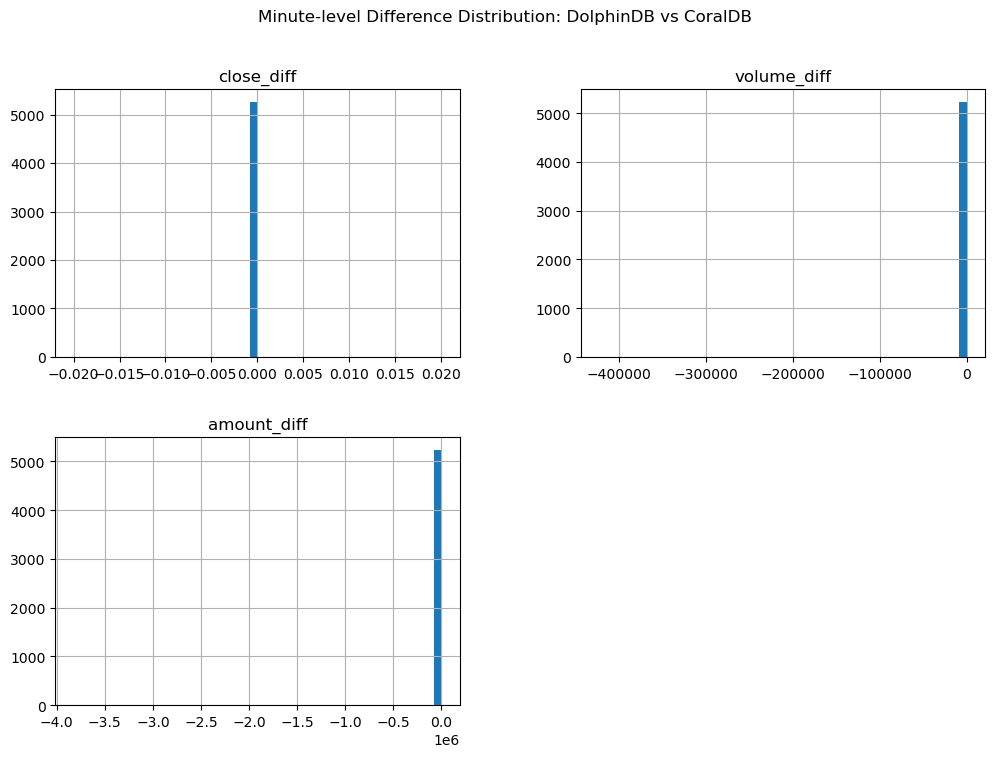

In [26]:
# 7 误差分布图
diff_cols = ["close_diff", "volume_diff", "amount_diff"]

minute_compare[diff_cols].hist(
    bins=50,
    figsize=(12, 8)
)

plt.suptitle("Minute-level Difference Distribution: DolphinDB vs CoralDB")
plt.show()

In [48]:
def format_trading_time_axis(ax):
    tick_pos = [0, 30, 60, 90, 119, 120, 150, 180, 210, 239]
    tick_label = [
        "09:31", "10:01", "10:31", "11:01",
        "11:30", "13:01", "13:31",
        "14:01", "14:31", "15:00"
    ]

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_label, rotation=45)

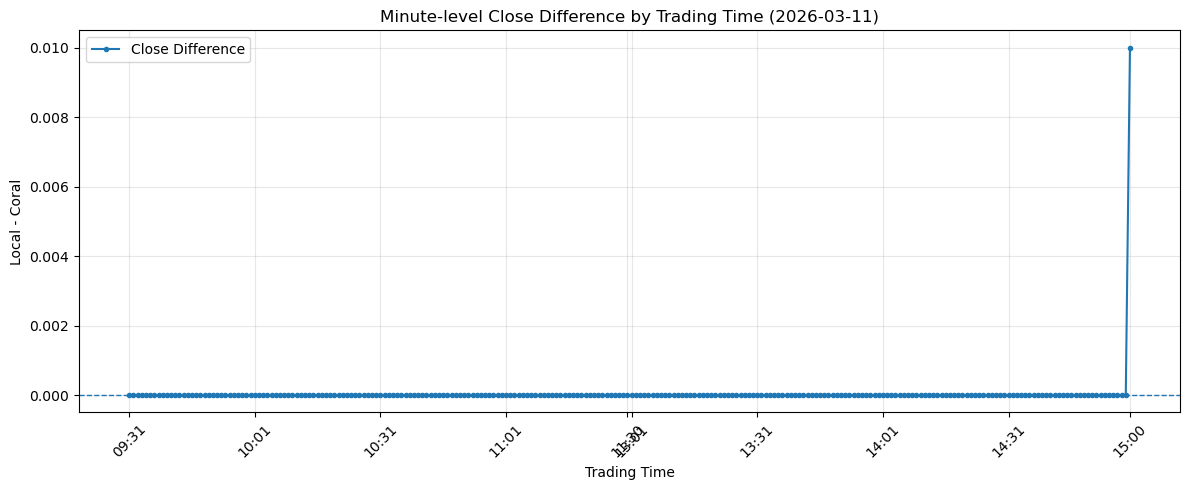

In [53]:
# 8 按时间看误差
sample_day = minute_compare["date"].min()

one_day_minute = (
    minute_compare[minute_compare["date"] == sample_day]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

one_day_minute["minute_idx"] = range(len(one_day_minute))


def format_trading_time_axis(ax):
    tick_pos = [0, 30, 60, 90, 119, 120, 150, 180, 210, 239]
    tick_label = [
        "09:31", "10:01", "10:31", "11:01",
        "11:30", "13:01", "13:31",
        "14:01", "14:31", "15:00"
    ]

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_label, rotation=45)


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    one_day_minute["minute_idx"],
    one_day_minute["close_diff"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Close Difference"
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title(f"Minute-level Close Difference by Trading Time ({sample_day.date()})")
ax.set_xlabel("Trading Time")
ax.set_ylabel("Local - Coral")

format_trading_time_axis(ax)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Minute-level Error Investigation

In [28]:
# 1 找出异常minute
PRICE_TOL = 0.01
VOLUME_TOL_PCT = 0.001
AMOUNT_TOL_PCT = 0.001

minute_abnormal = minute_compare.copy()

minute_abnormal["is_close_abnormal"] = (
    minute_abnormal["close_diff"].abs() > PRICE_TOL
)

minute_abnormal["is_volume_abnormal"] = (
    minute_abnormal["volume_diff_pct"].abs() > VOLUME_TOL_PCT
)

minute_abnormal["is_amount_abnormal"] = (
    minute_abnormal["amount_diff_pct"].abs() > AMOUNT_TOL_PCT
)

minute_abnormal["is_any_abnormal"] = (
    minute_abnormal["is_close_abnormal"] |
    minute_abnormal["is_volume_abnormal"] |
    minute_abnormal["is_amount_abnormal"]
)

abnormal_minutes = minute_abnormal[
    minute_abnormal["is_any_abnormal"]
].copy()

print("Abnormal minute rows:", len(abnormal_minutes))
print("Total minute rows:", len(minute_compare))
print("Abnormal ratio:", len(abnormal_minutes) / len(minute_compare))

abnormal_minutes[
    [
        "date", "timestamp",
        "local_close", "coral_close", "close_diff",
        "local_volume", "coral_volume", "volume_diff", "volume_diff_pct",
        "local_amount", "coral_amount", "amount_diff", "amount_diff_pct",
        "is_close_abnormal", "is_volume_abnormal", "is_amount_abnormal"
    ]
].head(20)

Abnormal minute rows: 53
Total minute rows: 5280
Abnormal ratio: 0.010037878787878788


,date,timestamp,local_close,coral_close,close_diff,local_volume,coral_volume,volume_diff,volume_diff_pct,local_amount,coral_amount,amount_diff,amount_diff_pct,is_close_abnormal,is_volume_abnormal,is_amount_abnormal
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,0.00,279600.0,397200.0,-117600.0,-0.296073,2558422.0,3637990.0,-1079568.0,-0.296748,False,True,True
239,2026-03-11,2026-03-11 15:00:00,9.30,9.29,0.01,0.0,375200.0,-375200.0,-1.000000,0.0,3485608.0,-3485608.0,-1.000000,True,True,True
240,2026-03-12,2026-03-12 09:31:00,9.25,9.25,0.00,259700.0,404800.0,-145100.0,-0.358449,2403498.0,3750026.0,-1346528.0,-0.359072,False,True,True
479,2026-03-12,2026-03-12 15:00:00,9.19,9.19,0.00,0.0,282000.0,-282000.0,-1.000000,0.0,2591580.0,-2591580.0,-1.000000,False,True,True
480,2026-03-13,2026-03-13 09:31:00,9.22,9.22,0.00,632048.0,684348.0,-52300.0,-0.076423,5822891.0,6301436.0,-478545.0,-0.075942,False,True,True
599,2026-03-13,2026-03-13 11:30:00,9.51,9.51,0.00,115000.0,116000.0,-1000.0,-0.008621,1093967.0,1103477.0,-9510.0,-0.008618,False,True,True
719,2026-03-13,2026-03-13 15:00:00,9.47,9.47,0.00,0.0,393300.0,-393300.0,-1.000000,0.0,3724551.0,-3724551.0,-1.000000,False,True,True
720,2026-03-16,2026-03-16 09:31:00,9.50,9.50,0.00,1467102.0,1857102.0,-390000.0,-0.210005,14027355.0,17751855.0,-3724500.0,-0.209809,False,True,True
959,2026-03-16,2026-03-16 15:00:00,9.39,9.38,0.01,0.0,256300.0,-256300.0,-1.000000,0.0,2404094.0,-2404094.0,-1.000000,False,True,True
960,2026-03-17,2026-03-17 09:31:00,9.47,9.47,0.00,926000.0,1058300.0,-132300.0,-0.125012,8752144.0,9995764.0,-1243620.0,-0.124415,False,True,True


In [29]:
# 2 按异常类型统计
abnormal_type_summary = pd.DataFrame({
    "abnormal_type": [
        "close_abnormal",
        "volume_abnormal",
        "amount_abnormal"
    ],
    "count": [
        minute_abnormal["is_close_abnormal"].sum(),
        minute_abnormal["is_volume_abnormal"].sum(),
        minute_abnormal["is_amount_abnormal"].sum()
    ],
    "ratio": [
        minute_abnormal["is_close_abnormal"].mean(),
        minute_abnormal["is_volume_abnormal"].mean(),
        minute_abnormal["is_amount_abnormal"].mean()
    ]
})

abnormal_type_summary

,abnormal_type,count,ratio
0,close_abnormal,8,0.001515
1,volume_abnormal,53,0.010038
2,amount_abnormal,53,0.010038


In [30]:
# 3 异常是否集中在某些时间点
abnormal_minutes["clock_time"] = abnormal_minutes["timestamp"].dt.strftime("%H:%M")

abnormal_by_time = (
    abnormal_minutes
    .groupby("clock_time")
    .size()
    .reset_index(name="abnormal_count")
    .sort_values("abnormal_count", ascending=False)
)

abnormal_by_time.head(20)

,clock_time,abnormal_count
0,09:31,22
2,15:00,22
1,11:30,9


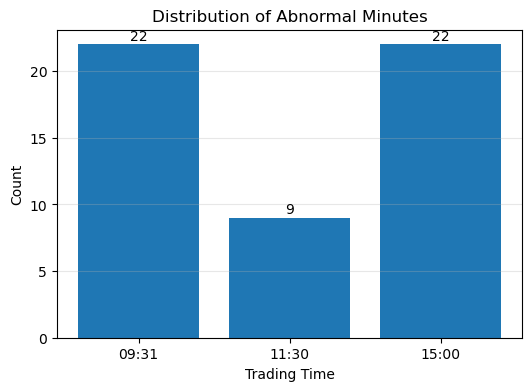

In [56]:
boundary_summary = (
    abnormal_minutes
    .groupby("clock_time")
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(6,4))

plt.bar(
    boundary_summary["clock_time"],
    boundary_summary["count"]
)

for i, v in enumerate(boundary_summary["count"]):
    plt.text(i, v+0.3, str(v), ha="center")

plt.title("Distribution of Abnormal Minutes")
plt.xlabel("Trading Time")
plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [32]:
# 4 异常是否集中在某些日期
abnormal_by_date = (
    abnormal_minutes
    .groupby("date")
    .size()
    .reset_index(name="abnormal_count")
    .sort_values("date")
)

abnormal_by_date

,date,abnormal_count
0,2026-03-11,2
1,2026-03-12,2
2,2026-03-13,3
3,2026-03-16,2
4,2026-03-17,2
5,2026-03-18,2
6,2026-03-19,2
7,2026-03-20,3
8,2026-03-23,3
9,2026-03-24,3


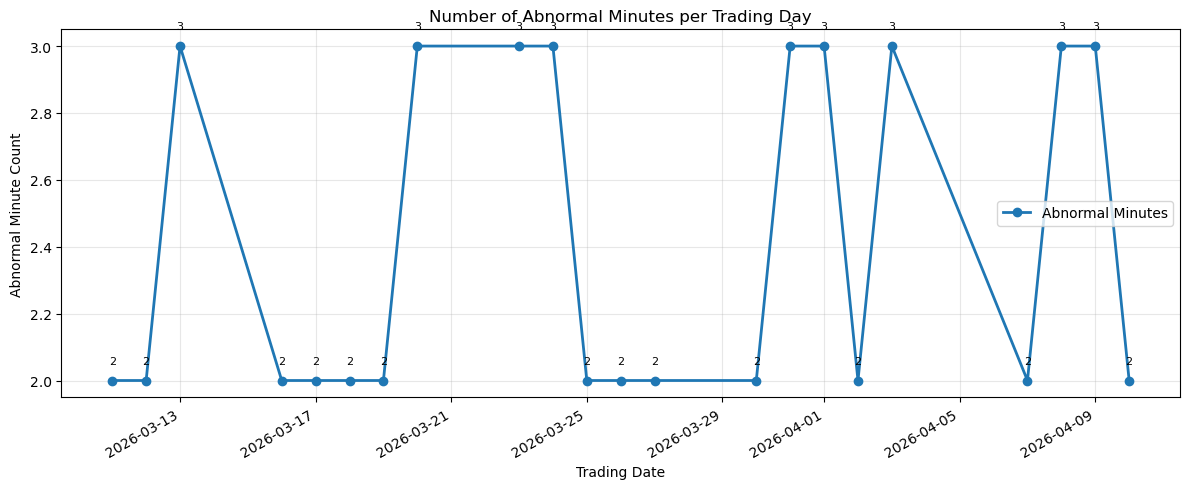

In [58]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    abnormal_by_date["date"],
    abnormal_by_date["abnormal_count"],
    marker="o",
    linewidth=2,
    markersize=6,
    label="Abnormal Minutes"
)

# 标注每个点
for x, y in zip(abnormal_by_date["date"], abnormal_by_date["abnormal_count"]):
    ax.text(
        x,
        y + 0.05,
        str(y),
        fontsize=8,
        ha="center"
    )

ax.set_title("Number of Abnormal Minutes per Trading Day")
ax.set_xlabel("Trading Date")
ax.set_ylabel("Abnormal Minute Count")

ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [34]:
# 5 异常差异大小分布
abnormal_minutes[
    [
        "close_diff",
        "volume_diff",
        "volume_diff_pct",
        "amount_diff",
        "amount_diff_pct"
    ]
].describe()

,close_diff,volume_diff,volume_diff_pct,amount_diff,amount_diff_pct
count,53.000000,53.000000,53.000000,5.300000e+01,53.000000
mean,0.002264,-153393.905660,-0.482814,-1.377326e+06,-0.482818
std,0.008000,124297.007948,0.445080,1.132823e+06,0.445092
min,-0.020000,-422221.000000,-1.000000,-3.825322e+06,-1.000000
25%,0.000000,-234600.000000,-1.000000,-2.079900e+06,-1.000000
50%,0.000000,-145100.000000,-0.210005,-1.332828e+06,-0.209809
75%,0.000000,-42400.000000,-0.083900,-3.786320e+05,-0.083996
max,0.020000,-100.000000,-0.003282,-8.690000e+02,-0.003285


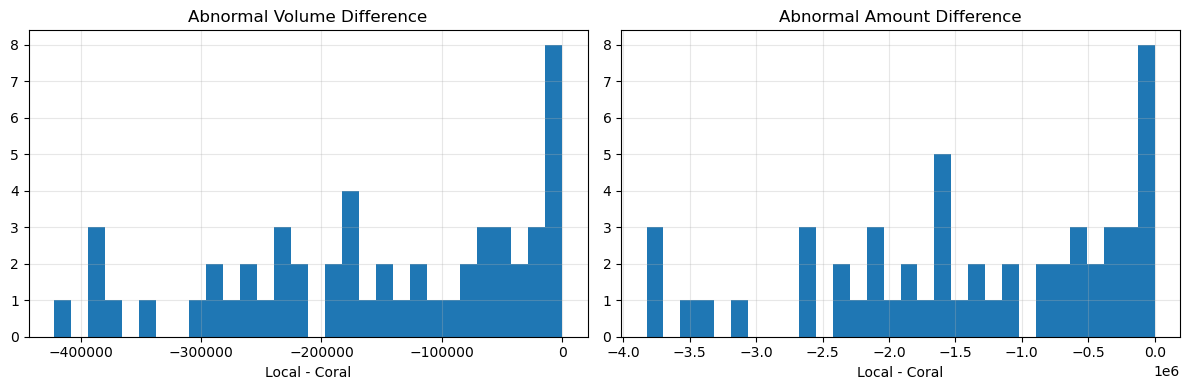

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(abnormal_minutes["volume_diff"], bins=30)
axes[0].set_title("Abnormal Volume Difference")
axes[0].set_xlabel("Local - Coral")
axes[0].grid(alpha=0.3)

axes[1].hist(abnormal_minutes["amount_diff"], bins=30)
axes[1].set_title("Abnormal Amount Difference")
axes[1].set_xlabel("Local - Coral")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# 6 看异常样本明细
abnormal_detail = abnormal_minutes[
    [
        "date", "timestamp",
        "local_close", "coral_close", "close_diff",
        "local_volume", "coral_volume", "volume_diff", "volume_diff_pct",
        "local_amount", "coral_amount", "amount_diff", "amount_diff_pct",
        "is_close_abnormal", "is_volume_abnormal", "is_amount_abnormal"
    ]
].copy()

abnormal_detail.sort_values(
    ["date", "timestamp"]
).head(20)

,date,timestamp,local_close,coral_close,close_diff,local_volume,coral_volume,volume_diff,volume_diff_pct,local_amount,coral_amount,amount_diff,amount_diff_pct,is_close_abnormal,is_volume_abnormal,is_amount_abnormal
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,0.00,279600.0,397200.0,-117600.0,-0.296073,2558422.0,3637990.0,-1079568.0,-0.296748,False,True,True
239,2026-03-11,2026-03-11 15:00:00,9.30,9.29,0.01,0.0,375200.0,-375200.0,-1.000000,0.0,3485608.0,-3485608.0,-1.000000,True,True,True
240,2026-03-12,2026-03-12 09:31:00,9.25,9.25,0.00,259700.0,404800.0,-145100.0,-0.358449,2403498.0,3750026.0,-1346528.0,-0.359072,False,True,True
479,2026-03-12,2026-03-12 15:00:00,9.19,9.19,0.00,0.0,282000.0,-282000.0,-1.000000,0.0,2591580.0,-2591580.0,-1.000000,False,True,True
480,2026-03-13,2026-03-13 09:31:00,9.22,9.22,0.00,632048.0,684348.0,-52300.0,-0.076423,5822891.0,6301436.0,-478545.0,-0.075942,False,True,True
599,2026-03-13,2026-03-13 11:30:00,9.51,9.51,0.00,115000.0,116000.0,-1000.0,-0.008621,1093967.0,1103477.0,-9510.0,-0.008618,False,True,True
719,2026-03-13,2026-03-13 15:00:00,9.47,9.47,0.00,0.0,393300.0,-393300.0,-1.000000,0.0,3724551.0,-3724551.0,-1.000000,False,True,True
720,2026-03-16,2026-03-16 09:31:00,9.50,9.50,0.00,1467102.0,1857102.0,-390000.0,-0.210005,14027355.0,17751855.0,-3724500.0,-0.209809,False,True,True
959,2026-03-16,2026-03-16 15:00:00,9.39,9.38,0.01,0.0,256300.0,-256300.0,-1.000000,0.0,2404094.0,-2404094.0,-1.000000,False,True,True
960,2026-03-17,2026-03-17 09:31:00,9.47,9.47,0.00,926000.0,1058300.0,-132300.0,-0.125012,8752144.0,9995764.0,-1243620.0,-0.124415,False,True,True


In [37]:
# 7 检查是不是边界时间问题
def classify_time_region(ts):
    t = ts.time()
    
    if t <= pd.to_datetime("09:31:00").time():
        return "market_open_boundary"
    elif t >= pd.to_datetime("14:57:00").time():
        return "market_close_boundary"
    elif pd.to_datetime("11:30:00").time() <= t <= pd.to_datetime("13:00:00").time():
        return "lunch_break"
    else:
        return "regular_intraday"

abnormal_minutes["time_region"] = abnormal_minutes["timestamp"].apply(classify_time_region)

time_region_summary = (
    abnormal_minutes
    .groupby("time_region")
    .size()
    .reset_index(name="abnormal_count")
    .sort_values("abnormal_count", ascending=False)
)

time_region_summary

,time_region,abnormal_count
1,market_close_boundary,22
2,market_open_boundary,22
0,lunch_break,9


### Boundary Timestamp Investigation

In [38]:
# 1 先把三种boundary全部取出来
boundary_times = [
    "09:31",
    "11:30",
    "15:00"
]

boundary_df = minute_compare.copy()

boundary_df["clock_time"] = boundary_df["timestamp"].dt.strftime("%H:%M")

boundary_df = boundary_df[
    boundary_df["clock_time"].isin(boundary_times)
].copy()

print(boundary_df.shape)

boundary_df.head()

(66, 20)


,date,timestamp,local_open,local_high,local_low,local_close,local_sum_volume,local_sum_amount,local_volume,local_amount,coral_close,coral_volume,coral_amount,close_diff,close_diff_pct,volume_diff,volume_diff_pct,amount_diff,amount_diff_pct,clock_time
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,9.13,9.17,397200,3637990.0,279600.0,2558422.0,9.17,397200.0,3637990.0,0.00,0.000000,-117600.0,-0.296073,-1079568.0,-0.296748,09:31
119,2026-03-11,2026-03-11 11:30:00,9.34,9.34,9.33,9.33,25040613,232449933.0,16700.0,155867.0,9.33,16700.0,155867.0,0.00,0.000000,0.0,0.000000,0.0,0.000000,11:30
239,2026-03-11,2026-03-11 15:00:00,9.30,9.30,9.30,9.30,34725659,322599404.0,0.0,0.0,9.29,375200.0,3485608.0,0.01,0.001076,-375200.0,-1.000000,-3485608.0,-1.000000,15:00
240,2026-03-12,2026-03-12 09:31:00,9.23,9.26,9.23,9.25,404800,3750026.0,259700.0,2403498.0,9.25,404800.0,3750026.0,0.00,0.000000,-145100.0,-0.358449,-1346528.0,-0.359072,09:31
359,2026-03-12,2026-03-12 11:30:00,9.13,9.13,9.12,9.12,16840496,154945337.0,124000.0,1131424.0,9.12,124000.0,1131424.0,0.00,0.000000,0.0,0.000000,0.0,0.000000,11:30


In [39]:
# 2 看看到底是哪几个字段在差
boundary_df[
[
    "date",
    "timestamp",

    "local_close",
    "coral_close",
    "close_diff",

    "local_volume",
    "coral_volume",
    "volume_diff",

    "local_amount",
    "coral_amount",
    "amount_diff"
]
].sort_values(
["date","timestamp"]
)

,date,timestamp,local_close,coral_close,close_diff,local_volume,coral_volume,volume_diff,local_amount,coral_amount,amount_diff
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,0.00,279600.0,397200.0,-117600.0,2558422.0,3637990.0,-1079568.0
119,2026-03-11,2026-03-11 11:30:00,9.33,9.33,0.00,16700.0,16700.0,0.0,155867.0,155867.0,0.0
239,2026-03-11,2026-03-11 15:00:00,9.30,9.29,0.01,0.0,375200.0,-375200.0,0.0,3485608.0,-3485608.0
240,2026-03-12,2026-03-12 09:31:00,9.25,9.25,0.00,259700.0,404800.0,-145100.0,2403498.0,3750026.0,-1346528.0
359,2026-03-12,2026-03-12 11:30:00,9.12,9.12,0.00,124000.0,124000.0,0.0,1131424.0,1131424.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
4919,2026-04-09,2026-04-09 11:30:00,8.69,8.69,0.00,13900.0,14000.0,-100.0,120806.0,121675.0,-869.0
5039,2026-04-09,2026-04-09 15:00:00,8.68,8.67,0.01,0.0,262900.0,-262900.0,0.0,2279343.0,-2279343.0
5040,2026-04-10,2026-04-10 09:31:00,8.76,8.76,0.00,336400.0,362600.0,-26200.0,2936788.0,3164990.0,-228202.0
5159,2026-04-10,2026-04-10 11:30:00,8.84,8.84,0.00,10900.0,10900.0,0.0,96367.0,96367.0,0.0


In [40]:
# 3 每个Boundary做summary
summary_boundary = (
    boundary_df
    .groupby("clock_time")
    .agg(
        observations=("clock_time","count"),

        avg_close_diff=("close_diff","mean"),

        avg_volume_diff=("volume_diff","mean"),

        avg_amount_diff=("amount_diff","mean"),

        max_volume_diff=("volume_diff","max"),

        min_volume_diff=("volume_diff","min")
    )
)

summary_boundary

,observations,avg_close_diff,avg_volume_diff,avg_amount_diff,max_volume_diff,min_volume_diff
clock_time,,,,,,
09:31,22,0.000000,-109854.545455,-9.920160e+05,-25600.0,-390000.0
11:30,22,-0.000455,-1027.272727,-9.229409e+03,0.0,-15000.0
15:00,22,0.005909,-258658.045455,-2.316858e+06,-147600.0,-422221.0


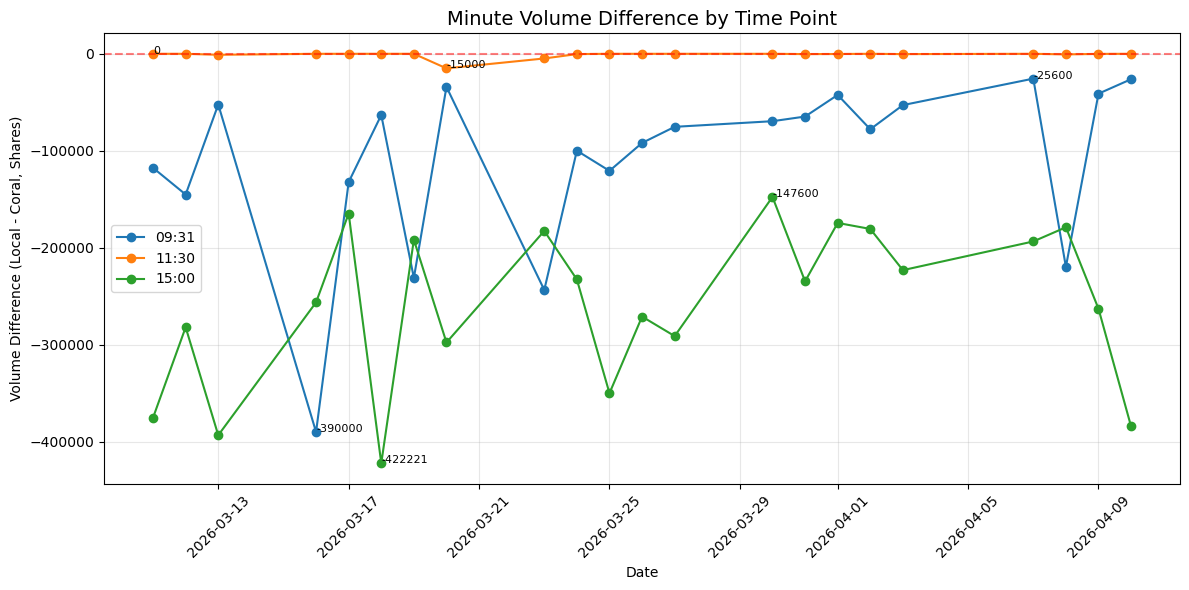

In [ ]:
# 4 每一天09：31，11：30，15：00到底差多少
time_points = ["09:31", "11:30", "15:00"]

plt.figure(figsize=(12, 6))

# 为每个时间点绘制折线
for time_point in time_points:
    # 筛选数据
    time_data = boundary_df[boundary_df["clock_time"] == time_point]
    
    # 绘制折线图
    plt.plot(
        time_data["date"],
        time_data["volume_diff"],
        marker="o",
        label=f"{time_point}"
    )

# 添加参考线
plt.axhline(0, linestyle="--", color="red", alpha=0.5)

# 图表设置
plt.title("Minute Volume Difference by Time Point", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Volume Difference (Local - Coral, Shares)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend() 

for time_point in ["09:31", "11:30", "15:00"]:

    tmp = boundary_df[boundary_df["clock_time"] == time_point]

    max_idx = tmp["volume_diff"].idxmax()
    min_idx = tmp["volume_diff"].idxmin()

    for idx in [max_idx, min_idx]:
        row = boundary_df.loc[idx]

        plt.text(
            row["date"],
            row["volume_diff"],
            f'{row["volume_diff"]:.0f}',
            fontsize=8
        )

plt.tight_layout()
plt.show()

Negative values indicate that the locally reconstructed minute volume is smaller than the CoralDB minute volume, mainly due to different minute aggregation conventions at market boundary timestamps.

In [42]:
# 5 Investigation
sample = boundary_df[
    boundary_df["clock_time"]=="09:31"
].iloc[0]

sample

date                2026-03-11 00:00:00
timestamp           2026-03-11 09:31:00
local_open                         9.17
local_high                         9.17
local_low                          9.13
local_close                        9.17
local_sum_volume                 397200
local_sum_amount              3637990.0
local_volume                   279600.0
local_amount                  2558422.0
coral_close                        9.17
coral_volume                   397200.0
coral_amount                  3637990.0
close_diff                          0.0
close_diff_pct                      0.0
volume_diff                   -117600.0
volume_diff_pct               -0.296073
amount_diff                  -1079568.0
amount_diff_pct               -0.296748
clock_time                        09:31
Name: 0, dtype: object

In [43]:
day = sample["date"]

tmp = qtick[
    qtick["date"]==day
].copy()

tmp["time"] = pd.to_datetime(tmp["time"])

tmp = tmp[
(tmp["time"]>=pd.to_datetime("09:29:30"))
&
(tmp["time"]<=pd.to_datetime("09:31:30"))
]

tmp[
[
"time",
"new_price",
"sum_volume",
"sum_amount"
]
]

,time,new_price,sum_volume,sum_amount


In [44]:
coral_tmp = coral_min[
coral_min["date"]==day
]

coral_tmp[
coral_tmp["timestamp"].dt.strftime("%H:%M").isin(
["09:30","09:31"]
)
]

,timestamp,date,stamp,dtype,code,name,market,sum_volume,sum_amount,status,...,min_order_volume,interest,sum_bid_volume,sum_bid_amount,sum_ask_volume,sum_ask_amount,source_file,coral_close,coral_volume,coral_amount
0,2026-03-11 09:31:00,2026-03-11,93100000,1,000009.SZ,中国宝安,2,397200,3637990.0,0,...,0,0.0,170200,1559015.0,227000,2078975.0,quota\qmin\20260311\000009.SZ.csv,9.17,397200.0,3637990.0


In [45]:
tmp = qtick[
    qtick["date"] == pd.Timestamp("2026-03-11")
].copy()

tmp = tmp.sort_values("datetime")

tmp[
    tmp["datetime"].dt.strftime("%H:%M").isin(
        ["09:30","09:31"]
    )
][
[
    "datetime",
    "sum_volume",
    "new_volume"
]
]

,datetime,sum_volume,new_volume
34,2026-03-11 09:30:00,143000,25400
35,2026-03-11 09:30:03,206100,63100
36,2026-03-11 09:30:06,230900,24800
37,2026-03-11 09:30:09,240400,9500
38,2026-03-11 09:30:12,245800,5400
39,2026-03-11 09:30:15,249700,3900
40,2026-03-11 09:30:18,260800,11100
41,2026-03-11 09:30:21,266400,5600
42,2026-03-11 09:30:24,267000,600
43,2026-03-11 09:30:27,273000,6000


In [46]:
difference_reason = pd.DataFrame({
    "time_point": ["09:31", "11:30", "15:00"],
    "main_difference": [
        "First-minute volume/amount mismatch",
        "Small morning close boundary mismatch",
        "Closing boundary volume/amount mismatch"
    ],
    "likely_reason": [
        "Opening cumulative volume treatment",
        "Morning session boundary convention",
        "Closing snapshot / last-minute aggregation convention"
    ],
    "data_quality_concern": ["Low", "Low", "Low"]
})

difference_reason

,time_point,main_difference,likely_reason,data_quality_concern
0,09:31,First-minute volume/amount mismatch,Opening cumulative volume treatment,Low
1,11:30,Small morning close boundary mismatch,Morning session boundary convention,Low
2,15:00,Closing boundary volume/amount mismatch,Closing snapshot / last-minute aggregation con...,Low


The minute-level validation demonstrates a high degree of consistency between DolphinDB (`qtick`) and CoralDB (`qmin`).

Across 5,280 matched one-minute observations:

- **Close Price:** 99.85% match rate
- **Trading Volume:** 98.48% match rate
- **Trading Amount:** 98.48% match rate

Unlike random data inconsistencies, nearly all remaining differences are concentrated at three fixed market boundary timestamps:

- **09:31** (first trading minute)
- **11:30** (morning session close)
- **15:00** (market close)

进一步调查显示：

- 日级累积字段（`sum_volume` 和 `sum_amount`）在两个数据源之间完全一致。
- 收盘价在整个交易日期间几乎完全一致。
- 其余差异主要源于不同的 **分钟聚合规则** 和 **快照时间戳对齐方式**，而非市场数据本身有误。

具体而言：

- 在 **09:31**，CoralDB 记录了开盘第一分钟的累计交易活动，而本地重建的分钟成交量则是通过累计差值推算得出，导致第一分钟的成交量较小。
- 在 **15:00**，CoralDB 将收盘分钟内的最后交易活动计入其中，而本地重建的数据序列因不存在后续快照，故将增量成交量设为零。
- 在 **11:30**，仅观察到微小差异，表明两个数据源对早盘时段边界的处理方式一致。

总体而言，此次验证证实，DolphinDB的`qtick`数据集在分钟级量化研究中具有极高的可靠性。观察到的偏差是由不同的聚合方法所导致的系统性边界效应，而非真正的数据质量问题。因此，只要分钟K线构建规则得到一致记录，`qtick`数据集便可放心用于后续的financial engineering和量化分析。

# Auction-level Validation
 Purpose of Auction-level Validation（验证目的）

Unlike Daily Validation and Minute Validation, the objective of this section is not only to compare numerical values, but also to verify whether the opening auction information reconstructed from DolphinDB is reliable.

Specifically, this section aims to answer three questions:

1. Is the reconstructed Opening Auction Price consistent with the official opening price from CoralDB?

2. Which auction-level fields can be directly validated against an external reference, and which require local reconstruction?

3. Can the reconstructed auction volume and auction amount be considered reliable for subsequent auction research?

Answering these questions ensures that the auction data used throughout Week 2 and later feature engineering is built upon a trustworthy data source.

In [70]:
# 1. Prepare qtick for auction validation

auction_tick = qtick.copy()

auction_tick["date"] = pd.to_datetime(auction_tick["date"], errors="coerce")
auction_tick["time"] = pd.to_datetime(auction_tick["time"], errors="coerce")

auction_tick = auction_tick.dropna(subset=["date", "time"])

auction_tick["datetime"] = auction_tick.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

for col in ["new_price", "new_volume", "new_amount", "sum_volume", "sum_amount", "open", "pre_close"]:
    auction_tick[col] = pd.to_numeric(auction_tick[col], errors="coerce")

auction_tick = auction_tick.sort_values(["date", "datetime"]).reset_index(drop=True)

In [61]:
# 2. Reconstruct local auction metrics
# For A-share opening auction, 09:25 is the auction clearing point.
# We use the first valid snapshot at/after 09:25 as the auction clearing snapshot.
# Auction volume and amount are proxied by cumulative sum_volume / sum_amount at that snapshot.
auction_start_time = pd.to_datetime("09:25:00").time()

auction_after_925 = auction_tick[
    auction_tick["datetime"].dt.time >= auction_start_time
].copy()

auction_after_925 = auction_after_925[
    auction_after_925["new_price"] > 0
].copy()

local_auction = (
    auction_after_925
    .sort_values(["date", "datetime"])
    .groupby("date")
    .first()
    .reset_index()
)

local_auction = local_auction[
    [
        "date",
        "datetime",
        "new_price",
        "open",
        "pre_close",
        "sum_volume",
        "sum_amount"
    ]
].copy()

local_auction = local_auction.rename(columns={
    "datetime": "local_auction_time",
    "new_price": "local_auction_price",
    "open": "local_open_field",
    "pre_close": "local_pre_close",
    "sum_volume": "local_auction_volume",
    "sum_amount": "local_auction_amount"
})

local_auction.head()


,date,local_auction_time,local_auction_price,local_open_field,local_pre_close,local_auction_volume,local_auction_amount
0,2026-03-11,2026-03-11 09:25:00,9.18,9.18,9.18,117600,1079568.0
1,2026-03-12,2026-03-12 09:25:00,9.28,9.28,9.29,145100,1346528.0
2,2026-03-13,2026-03-13 09:25:00,9.15,9.15,9.19,52300,478545.0
3,2026-03-16,2026-03-16 09:25:00,9.55,9.55,9.47,390000,3724500.0
4,2026-03-17,2026-03-17 09:25:00,9.40,9.40,9.38,132300,1243620.0


In [62]:
# 3. Prepare CoralDB auction reference
# CoralDB daily provides open price.
# It does not provide a standalone auction volume / amount field in the daily file.
# Therefore, we directly validate auction/opening price against Coral open.
coral_auction_ref = coral_daily_clean[
    [
        "date",
        "coral_open",
        "coral_pre_close",
        "coral_volume",
        "coral_amount"
    ]
].copy()

auction_compare = local_auction.merge(
    coral_auction_ref,
    on="date",
    how="inner"
)

auction_compare.head()

,date,local_auction_time,local_auction_price,local_open_field,local_pre_close,local_auction_volume,local_auction_amount,coral_open,coral_pre_close,coral_volume,coral_amount
0,2026-03-11,2026-03-11 09:25:00,9.18,9.18,9.18,117600,1079568.0,9.18,9.18,35100859,326085012.0
1,2026-03-12,2026-03-12 09:25:00,9.28,9.28,9.29,145100,1346528.0,9.28,9.29,24742202,227366309.0
2,2026-03-13,2026-03-13 09:25:00,9.15,9.15,9.19,52300,478545.0,9.15,9.19,63733398,604637179.0
3,2026-03-16,2026-03-16 09:25:00,9.55,9.55,9.47,390000,3724500.0,9.55,9.47,34285345,322788160.0
4,2026-03-17,2026-03-17 09:25:00,9.40,9.40,9.38,132300,1243620.0,9.40,9.38,23559418,220053681.0


In [63]:
# 4. Calculate auction-level differences
auction_compare["auction_price_diff"] = (
    auction_compare["local_auction_price"] - auction_compare["coral_open"]
)

auction_compare["open_field_diff"] = (
    auction_compare["local_open_field"] - auction_compare["coral_open"]
)

auction_compare["pre_close_diff"] = (
    auction_compare["local_pre_close"] - auction_compare["coral_pre_close"]
)

auction_compare[
    [
        "date",
        "local_auction_time",
        "local_auction_price",
        "local_open_field",
        "coral_open",
        "auction_price_diff",
        "open_field_diff",
        "local_auction_volume",
        "local_auction_amount"
    ]
].head()

,date,local_auction_time,local_auction_price,local_open_field,coral_open,auction_price_diff,open_field_diff,local_auction_volume,local_auction_amount
0,2026-03-11,2026-03-11 09:25:00,9.18,9.18,9.18,0.0,0.0,117600,1079568.0
1,2026-03-12,2026-03-12 09:25:00,9.28,9.28,9.28,0.0,0.0,145100,1346528.0
2,2026-03-13,2026-03-13 09:25:00,9.15,9.15,9.15,0.0,0.0,52300,478545.0
3,2026-03-16,2026-03-16 09:25:00,9.55,9.55,9.55,0.0,0.0,390000,3724500.0
4,2026-03-17,2026-03-17 09:25:00,9.40,9.40,9.40,0.0,0.0,132300,1243620.0


In [64]:
# 5. Auction validation summary
PRICE_TOL = 0.01

auction_summary = pd.DataFrame([
    {
        "field": "auction_price_vs_coral_open",
        "tolerance": PRICE_TOL,
        "matched_days": (auction_compare["auction_price_diff"].abs() <= PRICE_TOL).sum(),
        "total_days": len(auction_compare),
        "match_rate": (auction_compare["auction_price_diff"].abs() <= PRICE_TOL).mean()
    },
    {
        "field": "open_field_vs_coral_open",
        "tolerance": PRICE_TOL,
        "matched_days": (auction_compare["open_field_diff"].abs() <= PRICE_TOL).sum(),
        "total_days": len(auction_compare),
        "match_rate": (auction_compare["open_field_diff"].abs() <= PRICE_TOL).mean()
    },
    {
        "field": "pre_close",
        "tolerance": PRICE_TOL,
        "matched_days": (auction_compare["pre_close_diff"].abs() <= PRICE_TOL).sum(),
        "total_days": len(auction_compare),
        "match_rate": (auction_compare["pre_close_diff"].abs() <= PRICE_TOL).mean()
    }
])

auction_summary

,field,tolerance,matched_days,total_days,match_rate
0,auction_price_vs_coral_open,0.01,22,22,1.0
1,open_field_vs_coral_open,0.01,22,22,1.0
2,pre_close,0.01,22,22,1.0


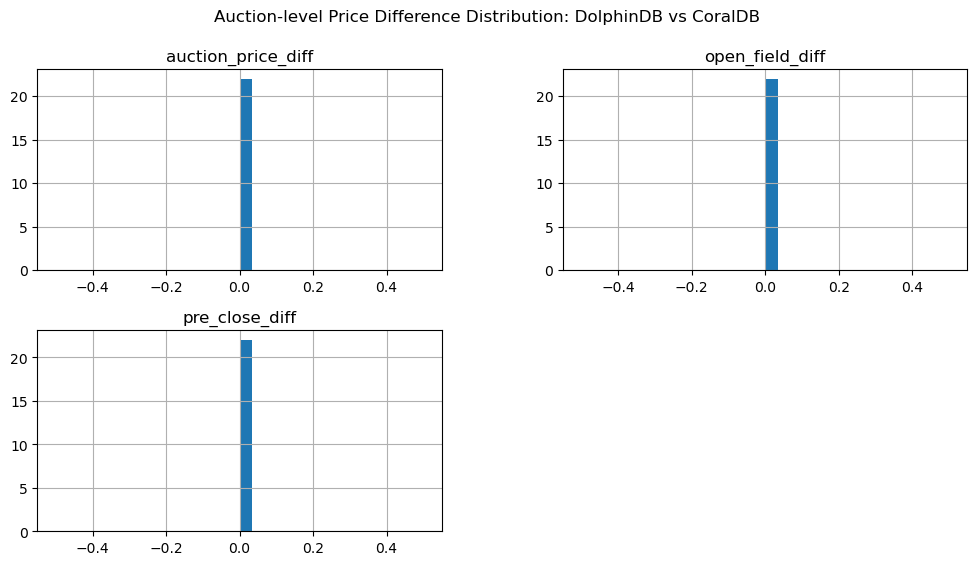

In [65]:
# 6. Auction price difference distribution
auction_compare[["auction_price_diff", "open_field_diff", "pre_close_diff"]].hist(
    bins=30,
    figsize=(12, 6)
)

plt.suptitle("Auction-level Price Difference Distribution: DolphinDB vs CoralDB")
plt.show()

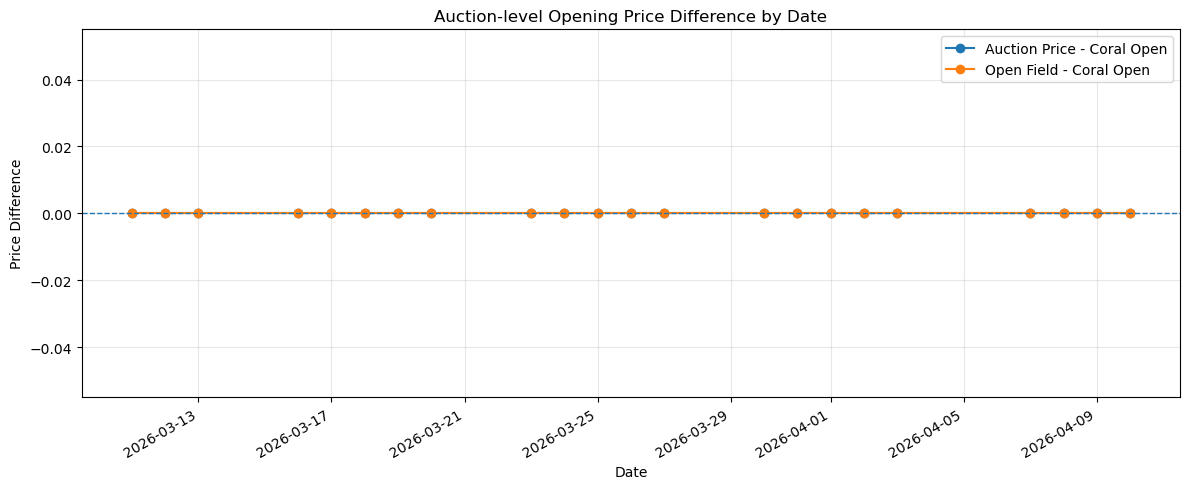

In [66]:
# 7. Auction price difference by date
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    auction_compare["date"],
    auction_compare["auction_price_diff"],
    marker="o",
    label="Auction Price - Coral Open"
)

ax.plot(
    auction_compare["date"],
    auction_compare["open_field_diff"],
    marker="o",
    label="Open Field - Coral Open"
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Auction-level Opening Price Difference by Date")
ax.set_xlabel("Date")
ax.set_ylabel("Price Difference")
ax.legend()
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [71]:
# 8. Auction Volume / Amount Summary Table

# Volume = 集合竞价阶段成交股数
# Amount = 集合竞价阶段成交金额
# Amount is largely driven by Volume × Auction Price, so we report it in table
# instead of plotting a separate trend chart.

auction_volume_amount = auction_compare[
    [
        "date",
        "local_auction_time",
        "local_auction_price",
        "local_auction_volume",
        "local_auction_amount",
        "coral_open",
        "coral_volume",
        "coral_amount"
    ]
].copy()

auction_volume_amount["auction_amount_million"] = (
    auction_volume_amount["local_auction_amount"] / 1_000_000
)

auction_volume_amount["daily_volume_share"] = (
    auction_volume_amount["local_auction_volume"] /
    auction_volume_amount["coral_volume"].replace(0, np.nan)
)

auction_volume_amount["daily_amount_share"] = (
    auction_volume_amount["local_auction_amount"] /
    auction_volume_amount["coral_amount"].replace(0, np.nan)
)

auction_volume_amount[
    [
        "date",
        "local_auction_time",
        "local_auction_price",
        "local_auction_volume",
        "auction_amount_million",
        "daily_volume_share",
        "daily_amount_share"
    ]
].head()

,date,local_auction_time,local_auction_price,local_auction_volume,auction_amount_million,daily_volume_share,daily_amount_share
0,2026-03-11,2026-03-11 09:25:00,9.18,117600,1.079568,0.003350,0.003311
1,2026-03-12,2026-03-12 09:25:00,9.28,145100,1.346528,0.005864,0.005922
2,2026-03-13,2026-03-13 09:25:00,9.15,52300,0.478545,0.000821,0.000791
3,2026-03-16,2026-03-16 09:25:00,9.55,390000,3.724500,0.011375,0.011539
4,2026-03-17,2026-03-17 09:25:00,9.40,132300,1.243620,0.005616,0.005651


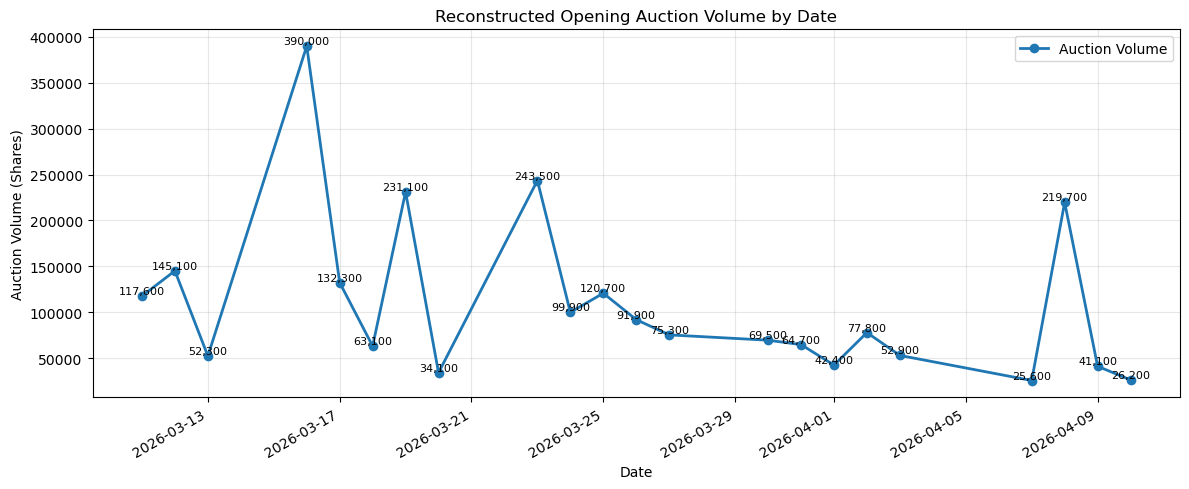

In [72]:
# 9. Reconstructed Auction Volume by Date

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    auction_volume_amount["date"],
    auction_volume_amount["local_auction_volume"],
    marker="o",
    linewidth=2,
    label="Auction Volume"
)

# 标注 y 轴数值
for x, y in zip(
    auction_volume_amount["date"],
    auction_volume_amount["local_auction_volume"]
):
    ax.text(
        x,
        y,
        f"{int(y):,}",
        fontsize=8,
        ha="center",
        va="bottom"
    )

ax.set_title("Reconstructed Opening Auction Volume by Date")
ax.set_xlabel("Date")
ax.set_ylabel("Auction Volume (Shares)")

ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Unlike opening price, auction volume is presented as a descriptive statistic rather than a direct validation target because CoralDB does not provide a standalone auction volume field. The figure illustrates the variation in opening auction participation across trading days and complements the price validation by providing additional context on market activity.

In [73]:
# 10. Auction Volume / Amount Descriptive Summary

auction_summary_stats = pd.DataFrame({
    "metric": [
        "Average auction volume",
        "Median auction volume",
        "Max auction volume",
        "Min auction volume",
        "Average auction amount (million)",
        "Average auction volume share of daily volume",
        "Average auction amount share of daily amount"
    ],
    "value": [
        auction_volume_amount["local_auction_volume"].mean(),
        auction_volume_amount["local_auction_volume"].median(),
        auction_volume_amount["local_auction_volume"].max(),
        auction_volume_amount["local_auction_volume"].min(),
        auction_volume_amount["auction_amount_million"].mean(),
        auction_volume_amount["daily_volume_share"].mean(),
        auction_volume_amount["daily_amount_share"].mean()
    ]
})

auction_summary_stats

,metric,value
0,Average auction volume,109854.545455
1,Median auction volume,76550.000000
2,Max auction volume,390000.000000
3,Min auction volume,25600.000000
4,Average auction amount (million),0.992016
5,Average auction volume share of daily volume,0.004144
6,Average auction amount share of daily amount,0.004159


### Observation（现象）

The auction-level validation compares the opening auction information reconstructed from DolphinDB with the CoralDB reference.

本节主要验证集合竞价阶段的数据一致性，包括：
- Opening Auction Price（集合竞价成交价）
- Opening Auction Volume（集合竞价成交量）
- Opening Auction Amount（集合竞价成交额）

验证结果表明：

- Opening Price 与 CoralDB Daily Open **22/22 个交易日完全一致（100% Match Rate）**
- `open` 字段与 CoralDB Daily Open 完全一致
- `pre_close` 字段完全一致
- Auction Volume 在不同交易日之间波动较大，说明每日开盘集合竞价参与程度存在明显差异，而非数据异常。

### Analysis（分析）

The opening auction price achieved a **100% match rate**, indicating that the auction clearing price reconstructed from DolphinDB is fully consistent with the official opening price provided by CoralDB.

从成交量统计来看：

- Average Auction Volume：109.9k shares
- Median Auction Volume：76.6k shares
- Maximum：390k shares
- Minimum：25.6k shares

Auction Volume 在不同交易日变化明显，这属于正常市场行为（Market Participation Variation），通常反映不同交易日开盘前资金参与程度不同。

Auction Amount 平均约 **0.99 million RMB**，由于：

> Auction Amount ≈ Auction Price × Auction Volume

因此其变化趋势主要由 Auction Volume 决定，所以本报告仅保留统计表，不单独绘制趋势图。

另外，Opening Auction 平均仅占全天成交量约 **0.41%**，说明绝大多数成交发生在 Continuous Trading Session（连续竞价阶段）。

### Investigation（原因分析）

Unlike the opening price, CoralDB does not provide standalone auction volume or auction amount fields.

因此：

- Opening Price 可以进行 Direct Validation（直接验证）
- Auction Volume / Amount 无法直接与第三方数据逐项比较，只能通过 DolphinDB `qtick` 的累计成交量（`sum_volume`）及累计成交额（`sum_amount`）进行 Local Reconstruction（本地重构）。

由于 Opening Price 已经达到 100% Match Rate，可以说明 Opening Auction Reconstruction 的整体逻辑是正确的，因此重构得到的 Auction Volume 与 Auction Amount 具有较高可信度（High Internal Consistency）。

### Conclusion（结论）

The auction-level validation demonstrates that DolphinDB provides reliable opening auction data.

主要结论如下：

Opening Auction Price 与 CoralDB 完全一致（100% Match）。

Opening Auction Volume 与 Auction Amount 能够通过 `qtick` 稳定重构，结果符合市场实际交易规律。

CoralDB 当前导出的 Daily / Minute 数据不包含独立的 Auction Volume 字段，因此无法进行逐字段 Direct Validation，但不存在明显的数据质量问题（No Material Data Quality Issue）。

综合来看，Auction-level 数据可以作为后续 Opening Feature Engineering 和 Auction Strategy Research 的可靠数据基础。

# Tick-level Validation

Unlike the previous daily, minute-level, and auction-level validations, this section focuses on transaction-level consistency.

The objective is to test whether cumulative market statistics recorded in `qtick` can be reconstructed from individual executed trades in `qknock`.

Rather than assuming either table is independently correct, the validation examines whether the two datasets describe the same underlying transaction activity across different levels of aggregation.

本节的核心问题是：

> Can transaction-level `qknock` records consistently reconstruct the cumulative trading statistics observed in `qtick`?

The analysis proceeds from data understanding, reconstruction, mismatch measurement, to root-cause investigation.

## 4.1 qknock Data Structure and Coverage
Before reconstructing higher-level market statistics, the transaction-level dataset is first examined to understand its scale, trade-size distribution, and daily coverage.

This step answers a basic validation question:

> Does `qknock` provide sufficiently complete and stable transaction-level records for reconstruction?

In [75]:
# 1 Prepare qknock for tick-level validation
knock = qknock.copy()

knock["date"] = pd.to_datetime(knock["date"], errors="coerce")
knock["time"] = pd.to_datetime(knock["time"], errors="coerce")

knock = knock.dropna(subset=["date", "time"])

knock["datetime"] = knock.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

num_cols = ["match_price", "match_volume"]

for col in num_cols:
    knock[col] = pd.to_numeric(knock[col], errors="coerce")

knock = knock.sort_values(["date", "datetime"]).reset_index(drop=True)

In [ ]:
# 2 qknock Basic Overview

qknock_overview = pd.DataFrame({
    "metric": [
        "Total trade records",
        "Trading days",
        "Average trades per day",
        "Average trade volume",
        "Median trade volume",
        "Max trade volume",
        "Min trade volume"
    ],
    "value": [
        len(knock),
        knock["date"].nunique(),
        len(knock) / knock["date"].nunique(),
        knock["match_volume"].mean(),
        knock["match_volume"].median(),
        knock["match_volume"].max(),
        knock["match_volume"].min()
    ]
})

qknock_overview

,metric,value
0,Total trade records,735794.000000
1,Trading days,22.000000
2,Average trades per day,33445.181818
3,Average trade volume,1604.463794
4,Median trade volume,500.000000
5,Max trade volume,456800.000000
6,Min trade volume,1.000000


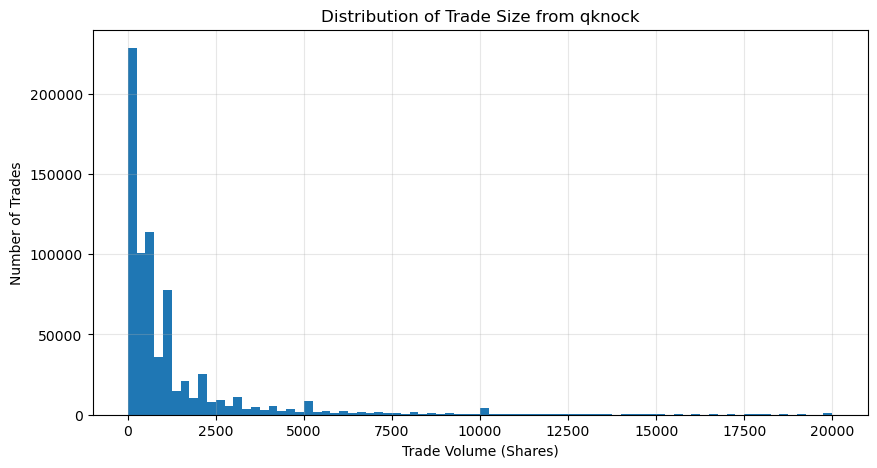

In [84]:
# 3 Trade Size Distribution
plt.figure(figsize=(10,5))

plt.hist(
    knock["match_volume"],
    bins=80,
    range=(0,20000)
)

plt.title("Distribution of Trade Size from qknock")
plt.xlabel("Trade Volume (Shares)")
plt.ylabel("Number of Trades")

plt.grid(alpha=0.3)
plt.show()

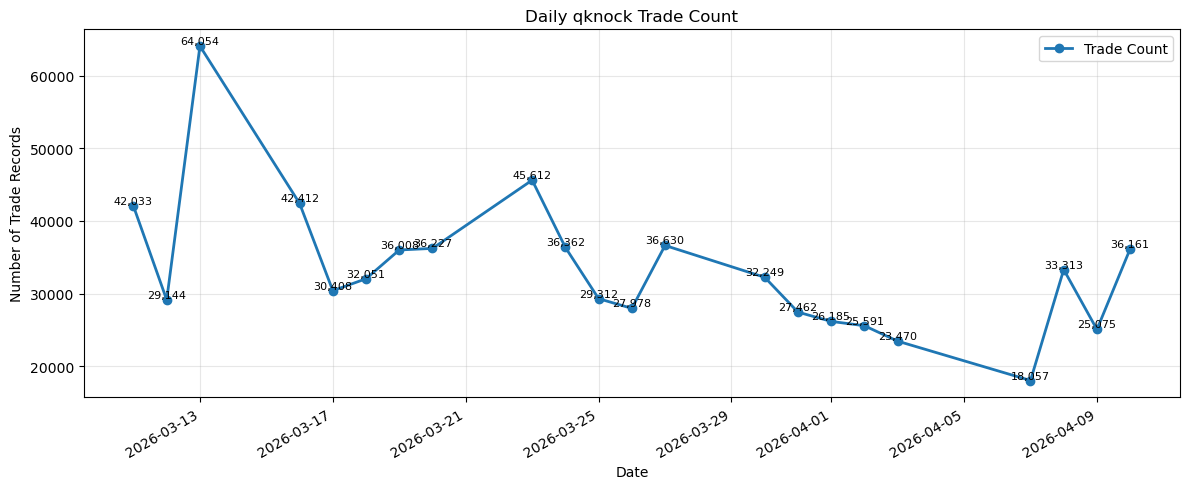

,date,trade_count
0,2026-03-11,42033
1,2026-03-12,29144
2,2026-03-13,64054
3,2026-03-16,42412
4,2026-03-17,30408


In [85]:
# Daily qknock Trade Count
# This figure checks whether qknock has stable transaction-level coverage across trading days.
daily_tick_count = (
    knock
    .groupby("date")
    .size()
    .reset_index(name="trade_count")
    .sort_values("date")
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_tick_count["date"],
    daily_tick_count["trade_count"],
    marker="o",
    linewidth=2,
    label="Trade Count"
)

# 标注每日逐笔成交记录数
for x, y in zip(daily_tick_count["date"], daily_tick_count["trade_count"]):
    ax.text(
        x,
        y,
        f"{int(y):,}",
        fontsize=8,
        ha="center",
        va="bottom"
    )

ax.set_title("Daily qknock Trade Count")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Trade Records")

ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

daily_tick_count.head()

This figure checks whether the transaction-level data in `qknock` has stable coverage across trading days.

这张图不是为了分析交易策略，而是为了做 data coverage check：如果某一天的 trade count 突然极低，可能说明该日逐笔成交数据缺失、股票停牌、交易异常，或者数据导出不完整。

Compared with the trade size histogram, daily trade count is more useful for validation because it directly answers whether `qknock` provides consistent transaction-level coverage over the sample period.

Overall, `qknock` provides transaction records across all 22 trading days in the sample period. No obvious day-level coverage gap is identified.

Therefore, the dataset is considered sufficiently complete for subsequent aggregation and cumulative reconstruction.

## 4.2 Transaction-level Data Interpretation and Unit Normalization
Before aggregation, the raw `qknock` fields must be interpreted using the correct storage units.

Inspection of `match_price` shows that transaction prices are stored in scaled integer form. For example, a raw value of `91800` corresponds to a market price of RMB `9.18`.

Therefore:

`Adjusted Trade Price = match_price / 10,000`

Transaction amount is subsequently reconstructed as:

`Trade Amount = Adjusted Trade Price × Match Volume`

统一价格单位后，`qknock` 的成交价格、成交量和成交额才可以与 `qtick` 及第三方数据进行直接比较。

In [140]:
# 4 Aggregate qknock to minute-level trades

knock_min = knock.copy()

# qknock 的 match_price 是整数价格单位，例如 91800 代表 9.18
# 因此需要先除以 10000，统一成和 qtick / CoralDB 一样的价格口径
knock_min["match_price_adj"] = knock_min["match_price"] / 10000

# 只保留有效成交价格和成交量
knock_min = knock_min[
    (knock_min["match_price_adj"] > 0) &
    (knock_min["match_volume"] > 0)
].copy()

# 逐笔成交金额 = 成交价 × 成交量
knock_min["trade_amount"] = (
    knock_min["match_price_adj"] * knock_min["match_volume"]
)

# 右标签分钟：
# 09:30:00-09:30:59 -> 09:31
knock_min["timestamp"] = (
    knock_min["datetime"].dt.floor("min") + pd.Timedelta(minutes=1)
)

knock_1min = (
    knock_min
    .groupby(["date", "timestamp"])
    .agg(
        knock_volume=("match_volume", "sum"),
        knock_amount=("trade_amount", "sum"),
        knock_last_price=("match_price_adj", "last")
    )
    .reset_index()
)


## 4.3 Tick-to-Minute Aggregation Sanity Check

After unit normalization, individual `qknock` transactions are aggregated into one-minute intervals.

For each minute, the following statistics are reconstructed:

- total executed volume
- total executed amount
- last transaction price
- transaction VWAP

This intermediate aggregation serves as a sanity check before cumulative snapshot reconstruction.

逐笔成交先聚合至分钟级，可以验证成交价格和成交量的计算口径是否合理，同时为后续与分钟行情及第三方数据对比保留统一接口。

In [141]:
# 5 qknock Minute Aggregation Overview

knock_1min["knock_vwap"] = (
    knock_1min["knock_amount"] /
    knock_1min["knock_volume"].replace(0, np.nan)
)

knock_minute_overview = pd.DataFrame({
    "metric": [
        "Minute rows",
        "Trading days",
        "Average minute volume",
        "Median minute volume",
        "Average minute amount (RMB)",
        "Average VWAP"
    ],
    "value": [
        len(knock_1min),
        knock_1min["date"].nunique(),
        knock_1min["knock_volume"].mean(),
        knock_1min["knock_volume"].median(),
        knock_1min["knock_amount"].mean(),
        knock_1min["knock_vwap"].mean()
    ]
})

knock_minute_overview

,metric,value
0,Minute rows,5258.000000
1,Trading days,22.000000
2,Average minute volume,110546.661278
3,Median minute volume,64500.000000
4,Average minute amount (RMB),994973.061250
5,Average VWAP,8.931567


## 4.4 Cumulative Reconstruction of qtick from qknock

The core validation reconstructs cumulative traded volume and amount directly from individual `qknock` transactions.

For each trading day:

`Cumulative Volume = Σ Match Volume`

`Cumulative Amount = Σ Trade Amount`

The reconstructed transaction statistics are then aligned with each `qtick` snapshot using the latest available `qknock` cumulative value.

本步骤的目标不是比较单笔成交，而是检验：

> At each market snapshot, does the cumulative transaction history reconstructed from `qknock` agree with the cumulative statistics reported by `qtick`?

In [91]:
# 6 qknock vs qtick Snapshot Validation
# Goal:
# Compare cumulative traded volume / amount reconstructed from qknock
# against qtick cumulative fields: sum_volume and sum_amount.

knock_cum = knock_min.copy()

knock_cum = knock_cum.sort_values(["date", "datetime"]).reset_index(drop=True)

knock_cum["cum_knock_volume"] = (
    knock_cum.groupby("date")["match_volume"].cumsum()
)

knock_cum["cum_knock_amount"] = (
    knock_cum.groupby("date")["trade_amount"].cumsum()
)

In [92]:
# Prepare qtick cumulative snapshot fields

tick_snapshot = qtick.copy()

tick_snapshot["date"] = pd.to_datetime(tick_snapshot["date"], errors="coerce")
tick_snapshot["time"] = pd.to_datetime(tick_snapshot["time"], errors="coerce")

tick_snapshot = tick_snapshot.dropna(subset=["date", "time"])

tick_snapshot["datetime"] = tick_snapshot.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

for col in ["sum_volume", "sum_amount", "new_price"]:
    tick_snapshot[col] = pd.to_numeric(tick_snapshot[col], errors="coerce")

tick_snapshot = (
    tick_snapshot
    .sort_values(["date", "datetime"])
    .reset_index(drop=True)
)

tick_snapshot = tick_snapshot[
    ["date", "datetime", "new_price", "sum_volume", "sum_amount"]
].copy()

In [88]:
# Align qtick snapshots with latest qknock cumulative values

aligned_list = []

for d in tick_snapshot["date"].dropna().unique():
    tick_day = tick_snapshot[tick_snapshot["date"] == d].sort_values("datetime").copy()
    knock_day = knock_cum[knock_cum["date"] == d].sort_values("datetime").copy()

    if len(tick_day) == 0 or len(knock_day) == 0:
        continue

    aligned_day = pd.merge_asof(
        tick_day,
        knock_day[["datetime", "cum_knock_volume", "cum_knock_amount"]],
        on="datetime",
        direction="backward"
    )

    aligned_day["date"] = d
    aligned_list.append(aligned_day)

tick_knock_compare = pd.concat(aligned_list, ignore_index=True)

tick_knock_compare["volume_diff"] = (
    tick_knock_compare["sum_volume"] - tick_knock_compare["cum_knock_volume"]
)

tick_knock_compare["amount_diff"] = (
    tick_knock_compare["sum_amount"] - tick_knock_compare["cum_knock_amount"]
)

tick_knock_compare.head()

,date,datetime,new_price,sum_volume,sum_amount,cum_knock_volume,cum_knock_amount,volume_diff,amount_diff
0,2026-03-11,2026-03-11 08:00:00,0.0,0,0.0,NaN,NaN,NaN,NaN
1,2026-03-11,2026-03-11 08:16:09,0.0,0,0.0,NaN,NaN,NaN,NaN
2,2026-03-11,2026-03-11 08:16:30,0.0,0,0.0,NaN,NaN,NaN,NaN
3,2026-03-11,2026-03-11 09:15:00,0.0,0,0.0,NaN,NaN,NaN,NaN
4,2026-03-11,2026-03-11 09:15:09,0.0,0,0.0,NaN,NaN,NaN,NaN


## 4.5 Baseline Reconstruction Accuracy

The first validation measures the direct agreement between reconstructed `qknock` cumulative statistics and `qtick` snapshot fields.

Three questions are examined:

1. Do the cumulative trajectories visually overlap?
2. What proportion of snapshots match exactly?
3. What is the typical magnitude of the remaining differences?

Snapshots before the first available transaction record are excluded because no transaction-level cumulative benchmark is available at those timestamps.

In [89]:
# qknock vs qtick cumulative validation summary

tick_knock_summary = pd.DataFrame({
    "metric": [
        "Matched qtick snapshots",
        "Volume exact match rate",
        "Amount exact match rate",
        "Average volume difference",
        "Average amount difference",
        "Max absolute volume difference",
        "Max absolute amount difference"
    ],
    "value": [
        len(tick_knock_compare),
        (tick_knock_compare["volume_diff"].abs() == 0).mean(),
        (tick_knock_compare["amount_diff"].abs() <= 1).mean(),
        tick_knock_compare["volume_diff"].mean(),
        tick_knock_compare["amount_diff"].mean(),
        tick_knock_compare["volume_diff"].abs().max(),
        tick_knock_compare["amount_diff"].abs().max()
    ]
})

tick_knock_summary

,metric,value
0,Matched qtick snapshots,1.024850e+05
1,Volume exact match rate,8.085573e-01
2,Amount exact match rate,8.085573e-01
3,Average volume difference,8.578122e+02
4,Average amount difference,7.702204e+03
5,Max absolute volume difference,7.328000e+05
6,Max absolute amount difference,6.562479e+06


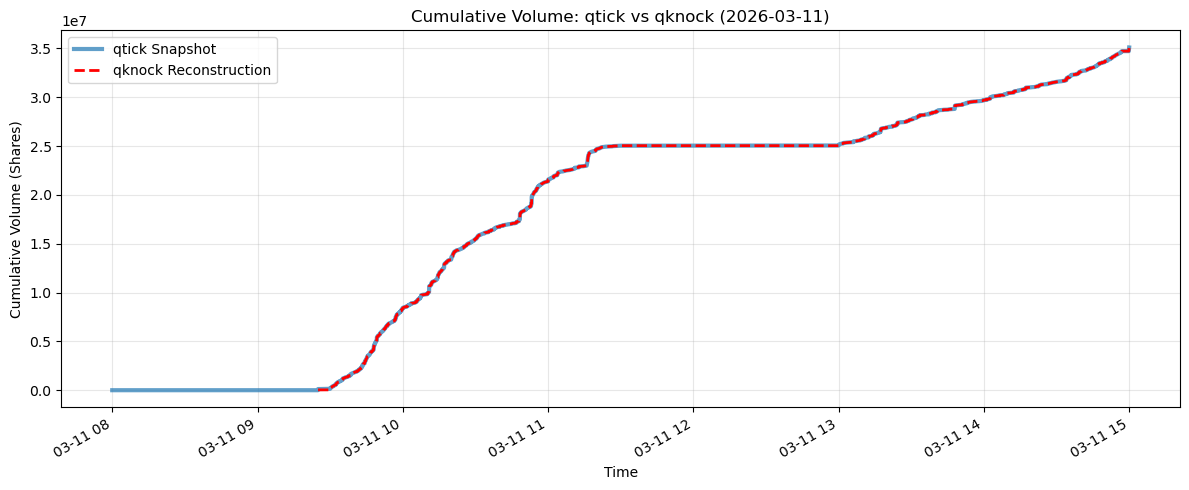

In [100]:
# Plot cumulative volume comparison for one sample day

sample_day = tick_knock_compare["date"].min()

one_day_compare = (
    tick_knock_compare[tick_knock_compare["date"] == sample_day]
    .sort_values("datetime")
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    one_day_compare["datetime"],
    one_day_compare["sum_volume"],
    linewidth=3,
    alpha=0.7,
    label="qtick Snapshot"
)

ax.plot(
    one_day_compare["datetime"],
    one_day_compare["cum_knock_volume"],
    linestyle="--",
    linewidth=2,
    color="red",
    label="qknock Reconstruction"
)

ax.set_title(f"Cumulative Volume: qtick vs qknock ({sample_day.date()})")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Volume (Shares)")
ax.legend()
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [94]:
# 7 Filter valid comparison samples
# Remove snapshots before the first available qknock trade.
# These rows have no transaction-level cumulative benchmark yet.

valid_compare = tick_knock_compare[
    tick_knock_compare["cum_knock_volume"].notna()
].copy()

valid_compare["volume_diff"] = (
    valid_compare["sum_volume"] - valid_compare["cum_knock_volume"]
)

valid_compare["amount_diff"] = (
    valid_compare["sum_amount"] - valid_compare["cum_knock_amount"]
)

valid_compare["volume_diff_pct"] = (
    valid_compare["volume_diff"] /
    valid_compare["sum_volume"].replace(0, np.nan)
)

valid_compare["amount_diff_pct"] = (
    valid_compare["amount_diff"] /
    valid_compare["sum_amount"].replace(0, np.nan)
)

valid_compare.head()

,date,datetime,new_price,sum_volume,sum_amount,cum_knock_volume,cum_knock_amount,volume_diff,amount_diff,volume_diff_pct,amount_diff_pct
33,2026-03-11,2026-03-11 09:25:00,9.18,117600,1079568.0,35100.0,322218.0,82500.0,757350.0,0.701531,0.701531
34,2026-03-11,2026-03-11 09:30:00,9.17,143000,1312717.0,35100.0,322218.0,107900.0,990499.0,0.754545,0.754541
35,2026-03-11,2026-03-11 09:30:03,9.16,206100,1890770.0,198400.0,1820238.0,7700.0,70532.0,0.037361,0.037303
36,2026-03-11,2026-03-11 09:30:06,9.15,230900,2117824.0,230900.0,2117824.0,0.0,0.0,0.000000,0.000000
37,2026-03-11,2026-03-11 09:30:09,9.16,240400,2204730.0,240400.0,2204730.0,0.0,0.0,0.000000,0.000000


In [95]:
# 8 qknock vs qtick cumulative validation summary
VOLUME_TOL = 0
AMOUNT_TOL = 1

tick_knock_summary = pd.DataFrame({
    "metric": [
        "Valid matched qtick snapshots",
        "Volume exact match rate",
        "Amount exact match rate",
        "Average volume difference",
        "Median volume difference",
        "95% absolute volume difference",
        "Max absolute volume difference",
        "Average volume difference pct",
        "95% absolute volume difference pct",
        "Average amount difference",
        "Median amount difference",
        "95% absolute amount difference",
        "Max absolute amount difference",
        "Average amount difference pct",
        "95% absolute amount difference pct"
    ],
    "value": [
        len(valid_compare),
        (valid_compare["volume_diff"].abs() <= VOLUME_TOL).mean(),
        (valid_compare["amount_diff"].abs() <= AMOUNT_TOL).mean(),
        valid_compare["volume_diff"].mean(),
        valid_compare["volume_diff"].median(),
        valid_compare["volume_diff"].abs().quantile(0.95),
        valid_compare["volume_diff"].abs().max(),
        valid_compare["volume_diff_pct"].mean(),
        valid_compare["volume_diff_pct"].abs().quantile(0.95),
        valid_compare["amount_diff"].mean(),
        valid_compare["amount_diff"].median(),
        valid_compare["amount_diff"].abs().quantile(0.95),
        valid_compare["amount_diff"].abs().max(),
        valid_compare["amount_diff_pct"].mean(),
        valid_compare["amount_diff_pct"].abs().quantile(0.95)
    ]
})

tick_knock_summary

,metric,value
0,Valid matched qtick snapshots,1.015920e+05
1,Volume exact match rate,8.156646e-01
2,Amount exact match rate,8.156646e-01
3,Average volume difference,8.578122e+02
4,Median volume difference,0.000000e+00
5,95% absolute volume difference,3.000000e+03
6,Max absolute volume difference,7.328000e+05
7,Average volume difference pct,3.876689e-04
8,95% absolute volume difference pct,2.788854e-04
9,Average amount difference,7.702204e+03


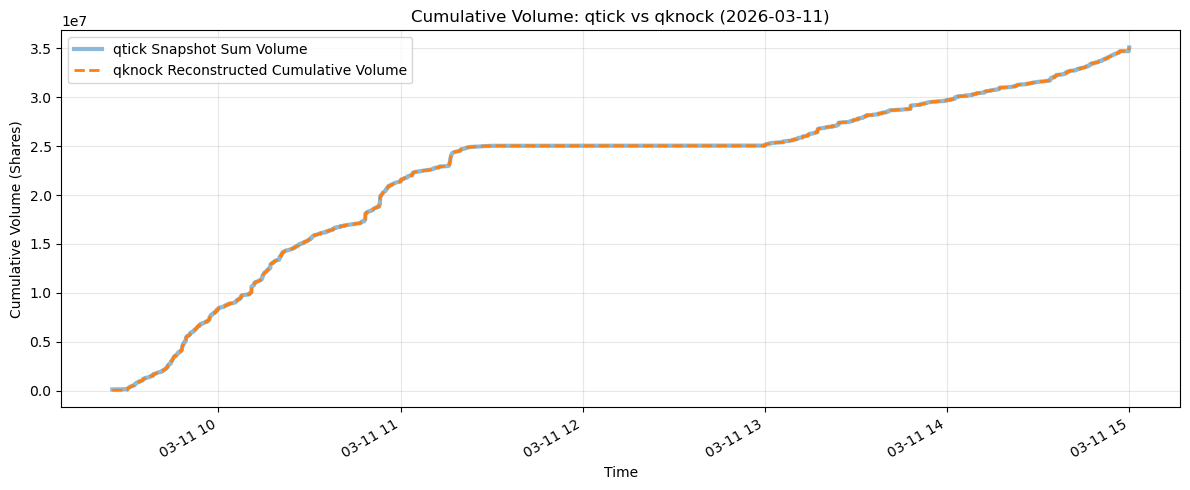

In [101]:
# 9 Plot cumulative volume comparison for one sample day
sample_day = valid_compare["date"].min()

one_day_compare = (
    valid_compare[valid_compare["date"] == sample_day]
    .sort_values("datetime")
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    one_day_compare["datetime"],
    one_day_compare["sum_volume"],
    linewidth=3,
    alpha=0.5,
    label="qtick Snapshot Sum Volume"
)

ax.plot(
    one_day_compare["datetime"],
    one_day_compare["cum_knock_volume"],
    linestyle="--",
    linewidth=2,
    label="qknock Reconstructed Cumulative Volume"
)

ax.set_title(f"Cumulative Volume: qtick vs qknock ({sample_day.date()})")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Volume (Shares)")
ax.legend()
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The reconstructed and snapshot cumulative trajectories are visually highly consistent.

However, exact-match statistics remain around 80%, indicating that visual agreement alone is insufficient to determine whether the remaining mismatches represent material data errors.

The next analysis therefore examines whether these discrepancies are systematic across trading days.

## 4.6 Daily Stability of Reconstruction Accuracy

A reconstruction error may indicate a structural data problem if it is concentrated on specific trading days.

Therefore, exact-match rates and difference statistics are evaluated separately for each trading day.

This analysis asks:

> Is the reconstruction mismatch a one-day anomaly, or a stable pattern across the full sample period?

In [ ]:
# 10 Top abnormal cumulative differences
top_volume_diff = (
    valid_compare
    .assign(abs_volume_diff=valid_compare["volume_diff"].abs())
    .sort_values("abs_volume_diff", ascending=False)
    [
        [
            "date",
            "datetime",
            "new_price",
            "sum_volume",
            "cum_knock_volume",
            "volume_diff",
            "volume_diff_pct",
            "sum_amount",
            "cum_knock_amount",
            "amount_diff",
            "amount_diff_pct"
        ]
    ]
    .head(20)
)

top_volume_diff

,date,datetime,new_price,sum_volume,cum_knock_volume,volume_diff,volume_diff_pct,sum_amount,cum_knock_amount,amount_diff,amount_diff_pct
100850,2026-04-10,2026-04-10 13:35:03,8.96,23093460,22360660.0,732800.0,0.031732,205429730.0,1.988673e+08,6562478.60,0.031945
14308,2026-03-16,2026-03-16 09:30:00,9.56,496902,131602.0,365300.0,0.735155,4746579.0,1.256799e+06,3489779.90,0.735220
27381,2026-03-18,2026-03-18 14:03:27,9.04,19789500,19474593.0,314907.0,0.015913,179677558.0,1.768308e+08,2846759.20,0.015844
11921,2026-03-13,2026-03-13 13:01:57,9.58,39509156,39210156.0,299000.0,0.007568,373240352.0,3.703730e+08,2867372.77,0.007682
12577,2026-03-13,2026-03-13 13:34:51,9.65,49372898,49101198.0,271700.0,0.005503,467685950.0,4.650664e+08,2619587.35,0.005601
6665,2026-03-12,2026-03-12 11:03:45,9.16,14367596,14100896.0,266700.0,0.018563,132334170.0,1.298912e+08,2442971.56,0.018461
14307,2026-03-16,2026-03-16 09:25:00,9.55,390000,131602.0,258398.0,0.662559,3724500.0,1.256799e+06,2467700.90,0.662559
9527,2026-03-13,2026-03-13 09:31:57,9.27,1631048,1393948.0,237100.0,0.145367,15057543.0,1.286297e+07,2194569.88,0.145746
28515,2026-03-19,2026-03-19 09:30:00,8.99,268100,33700.0,234400.0,0.874301,2412557.0,3.033000e+05,2109257.00,0.874283
5248,2026-03-12,2026-03-12 09:52:09,9.20,5069586,4862091.0,207495.0,0.040929,46842670.0,4.493167e+07,1911002.21,0.040796


In [120]:
# 11 Daily Stability of qknock -> qtick Reconstruction
daily_tick_validation = (
    valid_compare
    .groupby("date")
    .agg(
        snapshots=("datetime", "count"),
        volume_exact_match_rate=("volume_diff", lambda x: (x.abs() == 0).mean()),
        amount_exact_match_rate=("amount_diff", lambda x: (x.abs() <= 1).mean()),
        avg_abs_volume_diff=("volume_diff", lambda x: x.abs().mean()),
        p95_abs_volume_diff=("volume_diff", lambda x: x.abs().quantile(0.95)),
        avg_abs_amount_diff=("amount_diff", lambda x: x.abs().mean()),
        p95_abs_amount_diff=("amount_diff", lambda x: x.abs().quantile(0.95))
    )
    .reset_index()
)

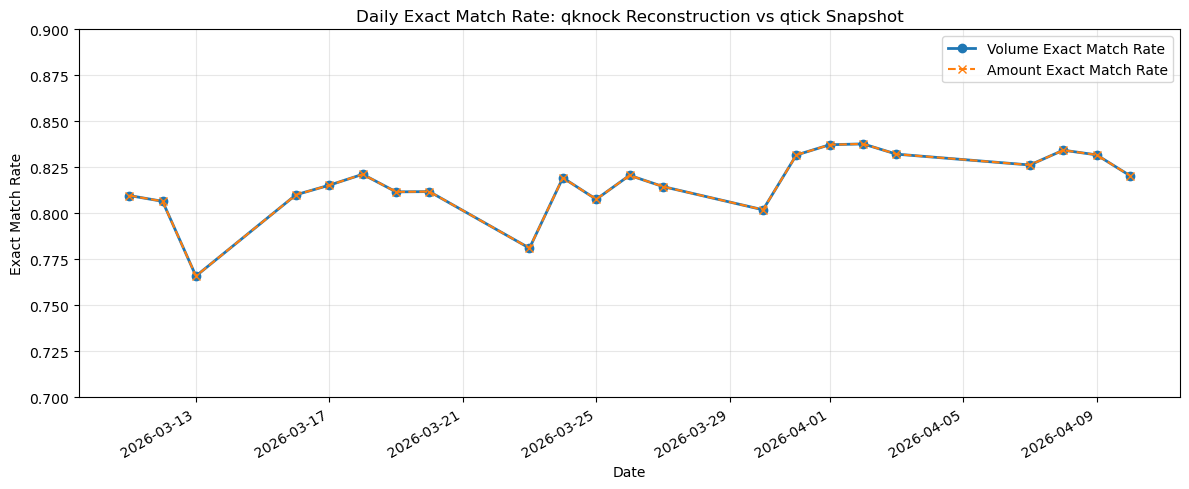

In [124]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_tick_validation["date"],
    daily_tick_validation["volume_exact_match_rate"],
    marker="o",
    linewidth=2,
    label="Volume Exact Match Rate"
)

ax.plot(
    daily_tick_validation["date"],
    daily_tick_validation["amount_exact_match_rate"],
    marker="x",
    linestyle="--",
    linewidth=1.5,
    label="Amount Exact Match Rate"
)

ax.set_title(
    "Daily Exact Match Rate: qknock Reconstruction vs qtick Snapshot"
)
ax.set_xlabel("Date")
ax.set_ylabel("Exact Match Rate")

ax.set_ylim(0.7, 0.9)

ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The exact cumulative match rate between `qknock` reconstruction and `qtick` snapshots remains around 80% across trading days.

However, exact equality is a strict validation criterion for high-frequency data. Small timing differences between trade records and market snapshots may generate minor cumulative discrepancies even when the underlying trading activity is consistent.

Therefore, tolerance-based match rates are evaluated to distinguish small synchronization deviations from material data inconsistencies.

The exact-match rate remains broadly stable across the sample period, with no isolated trading day showing a complete reconstruction breakdown.

因此，约 80% 的 exact match rate 更像一种稳定的数据对齐特征，而不是由单日数据缺失或异常导出导致。

This shifts the investigation from **when mismatches occur across days** to **how large the mismatches actually are**.

## 4.7 Mismatch Magnitude and Tolerance Analysis

Exact equality is a strict criterion for high-frequency cumulative data.

To distinguish minor synchronization differences from economically material inconsistencies, reconstruction accuracy is re-evaluated under progressively wider volume and amount tolerances.

The key question is:

> How quickly does the match rate approach 100% when small cumulative differences are allowed?

In [125]:
# 12 Exact Match vs Tolerance Match
volume_tolerances = [0, 100, 500, 1000, 5000, 10000]
amount_tolerances = [0, 1000, 5000, 10000, 50000, 100000]

volume_tolerance_result = []

for tol in volume_tolerances:
    match_rate = (
        valid_compare["volume_diff"].abs() <= tol
    ).mean()

    volume_tolerance_result.append({
        "tolerance_shares": tol,
        "match_rate": match_rate
    })

volume_tolerance_result = pd.DataFrame(volume_tolerance_result)

volume_tolerance_result

,tolerance_shares,match_rate
0,0,0.815665
1,100,0.834564
2,500,0.875384
3,1000,0.906951
4,5000,0.965942
5,10000,0.981662


In [126]:
amount_tolerance_result = []

for tol in amount_tolerances:
    match_rate = (
        valid_compare["amount_diff"].abs() <= tol
    ).mean()

    amount_tolerance_result.append({
        "tolerance_rmb": tol,
        "match_rate": match_rate
    })

amount_tolerance_result = pd.DataFrame(amount_tolerance_result)

amount_tolerance_result

,tolerance_rmb,match_rate
0,0,0.117686
1,1000,0.834574
2,5000,0.875502
3,10000,0.909619
4,50000,0.968393
5,100000,0.983306


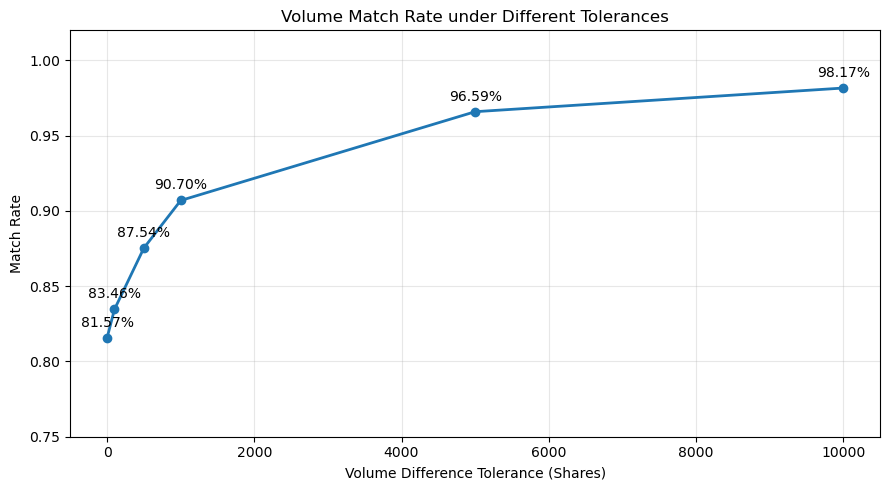

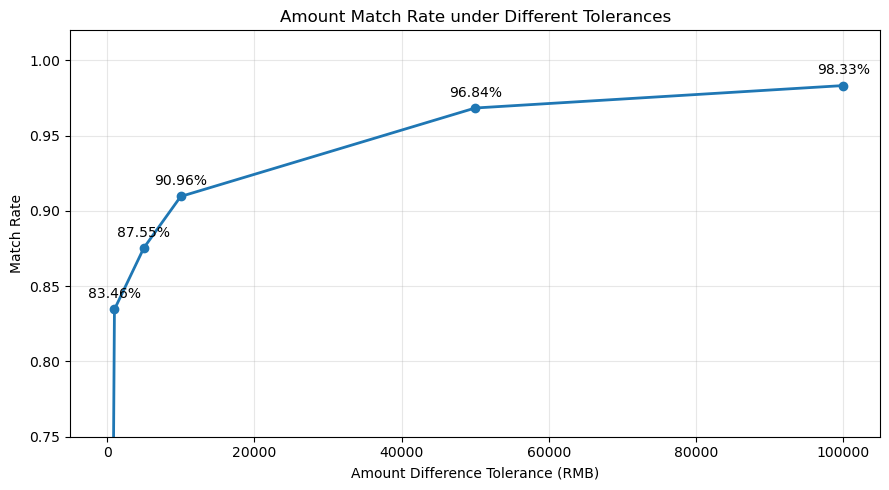

In [127]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    volume_tolerance_result["tolerance_shares"],
    volume_tolerance_result["match_rate"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    volume_tolerance_result["tolerance_shares"],
    volume_tolerance_result["match_rate"]
):
    ax.annotate(
        f"{y:.2%}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

ax.set_title("Volume Match Rate under Different Tolerances")
ax.set_xlabel("Volume Difference Tolerance (Shares)")
ax.set_ylabel("Match Rate")

ax.set_ylim(0.75, 1.02)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    amount_tolerance_result["tolerance_rmb"],
    amount_tolerance_result["match_rate"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    amount_tolerance_result["tolerance_rmb"],
    amount_tolerance_result["match_rate"]
):
    ax.annotate(
        f"{y:.2%}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

ax.set_title("Amount Match Rate under Different Tolerances")
ax.set_xlabel("Amount Difference Tolerance (RMB)")
ax.set_ylabel("Match Rate")

ax.set_ylim(0.75, 1.02)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [129]:
tolerance_summary = pd.DataFrame({
    "metric": [
        "Volume exact match",
        "Volume within 100 shares",
        "Volume within 500 shares",
        "Volume within 1,000 shares",
        "Volume within 5,000 shares",
        "Amount near-exact match (≤ RMB 1)",
        "Amount within RMB 1,000",
        "Amount within RMB 5,000",
        "Amount within RMB 10,000",
        "Amount within RMB 50,000"
    ],
    "match_rate": [
        (valid_compare["volume_diff"].abs() <= 0).mean(),
        (valid_compare["volume_diff"].abs() <= 100).mean(),
        (valid_compare["volume_diff"].abs() <= 500).mean(),
        (valid_compare["volume_diff"].abs() <= 1000).mean(),
        (valid_compare["volume_diff"].abs() <= 5000).mean(),

        np.isclose(
            valid_compare["sum_amount"],
            valid_compare["cum_knock_amount"],
            atol=1
        ).mean(),
        (valid_compare["amount_diff"].abs() <= 1000).mean(),
        (valid_compare["amount_diff"].abs() <= 5000).mean(),
        (valid_compare["amount_diff"].abs() <= 10000).mean(),
        (valid_compare["amount_diff"].abs() <= 50000).mean()
    ]
})

tolerance_summary["match_rate"] = (
    tolerance_summary["match_rate"] * 100
).round(2)

tolerance_summary

,metric,match_rate
0,Volume exact match,81.57
1,Volume within 100 shares,83.46
2,Volume within 500 shares,87.54
3,"Volume within 1,000 shares",90.70
4,"Volume within 5,000 shares",96.59
5,Amount near-exact match (≤ RMB 1),83.33
6,"Amount within RMB 1,000",83.46
7,"Amount within RMB 5,000",87.55
8,"Amount within RMB 10,000",90.96
9,"Amount within RMB 50,000",96.84


### Tolerance-based Match Analysis

#### Observation

The exact cumulative volume match rate between `qknock` reconstruction and `qtick` snapshots is approximately 81.6%.

However, the match rate increases rapidly when small cumulative deviations are allowed. The volume match rate reaches approximately 90.7% within a tolerance of 1,000 shares, 96.6% within 5,000 shares, and 98.2% within 10,000 shares.

成交量误差容忍度稍微放宽后，match rate 快速接近 100%，说明大部分 mismatch 的绝对规模较小。

A similar pattern is observed for cumulative trading amount. Approximately 91.0% of snapshots fall within RMB 10,000 of the reconstructed transaction amount, while more than 98% fall within RMB 100,000.

#### Analysis

An important pattern is that the volume and amount tolerance curves are highly consistent.

For example, a volume tolerance of 1,000 shares produces a match rate of approximately 90.7%, while an amount tolerance of RMB 10,000 produces a match rate of approximately 91.0%.

Given that the stock price during the sample period is approximately RMB 9, the corresponding amount difference implied by 1,000 shares is roughly RMB 9,000.

因此，volume mismatch 与 amount mismatch 并不像两个独立的数据质量问题。两者的误差规模基本符合：

`Amount Difference ≈ Volume Difference × Trade Price`

This suggests that the cumulative amount discrepancies are primarily generated by the same transaction synchronization differences that produce the cumulative volume discrepancies.

#### Conclusion

The tolerance analysis provides strong evidence that most non-exact matches are small and internally consistent across volume and amount.

Rather than indicating independent errors in transaction volume and trading amount, the observed differences are more consistent with temporary alignment differences between transaction-level `qknock` records and discrete `qtick` market snapshots.

The next investigation therefore focuses on the persistence of these mismatches: whether cumulative differences remain for extended periods or quickly converge back toward zero.


The rapid increase in match rate under small tolerances indicates that most non-exact matches are small in absolute magnitude.

However, this raises a further question: are volume and amount mismatches independent data issues, or are they generated by the same underlying transaction alignment difference?

## 4.8 Cross-Metric Consistency of Volume and Amount Differences

The volume and amount tolerance curves exhibit nearly identical convergence patterns.

For example:

- 1,000-share volume tolerance → approximately 90.7% match
- RMB 10,000 amount tolerance → approximately 91.0% match

Given an average stock price of approximately RMB 9:

`1,000 shares × RMB 9 ≈ RMB 9,000`

Therefore, the observed amount difference is economically consistent with the corresponding volume difference.

这说明 volume mismatch 与 amount mismatch 并不像两个独立的数据质量问题，而更可能来自同一批暂时未对齐的成交记录。

The evidence suggests:

`Volume Alignment Difference`
→ `Corresponding Amount Difference`
→ `Same Underlying Transaction Timing Effect`

If the mismatches are primarily caused by temporary transaction-snapshot alignment, they should disappear quickly in subsequent snapshots.

The next analysis therefore examines mismatch persistence and convergence.

## 4.9 Mismatch Persistence and Convergence

Small mismatches may still represent either temporary synchronization effects or persistent missing transactions.

To distinguish between these two cases, consecutive non-zero cumulative differences are grouped into mismatch episodes.

The analysis measures:

- number of affected snapshots
- episode duration
- maximum difference during each episode

The key question is:

> Once a mismatch appears, how quickly do `qknock` reconstruction and `qtick` snapshots converge again?

In [132]:
# 14 Mismatch Persistence / Convergence Analysis
persistence_df = valid_compare.copy()

persistence_df = persistence_df.sort_values(
    ["date", "datetime"]
).reset_index(drop=True)

# define mismatch
persistence_df["volume_mismatch"] = (
    persistence_df["volume_diff"].abs() > 0
)

# start of a new mismatch episode
persistence_df["new_episode"] = (
    persistence_df["volume_mismatch"] &
    (
        (~persistence_df["volume_mismatch"].shift(1, fill_value=False)) |
        (persistence_df["date"] != persistence_df["date"].shift(1))
    )
)

persistence_df["episode_id"] = (
    persistence_df["new_episode"].cumsum()
)

mismatch_rows = persistence_df[
    persistence_df["volume_mismatch"]
].copy()
mismatch_rows.head()

,date,datetime,new_price,sum_volume,sum_amount,cum_knock_volume,cum_knock_amount,volume_diff,amount_diff,volume_diff_pct,amount_diff_pct,volume_mismatch,new_episode,episode_id
0,2026-03-11,2026-03-11 09:25:00,9.18,117600,1079568.0,35100.0,322218.0,82500.0,757350.0,0.701531,0.701531,True,True,1
1,2026-03-11,2026-03-11 09:30:00,9.17,143000,1312717.0,35100.0,322218.0,107900.0,990499.0,0.754545,0.754541,True,False,1
2,2026-03-11,2026-03-11 09:30:03,9.16,206100,1890770.0,198400.0,1820238.0,7700.0,70532.0,0.037361,0.037303,True,False,1
14,2026-03-11,2026-03-11 09:30:39,9.14,325300,2980525.0,320300.0,2934825.0,5000.0,45700.0,0.015370,0.015333,True,True,2
16,2026-03-11,2026-03-11 09:30:45,9.14,347600,3184221.0,344800.0,3158629.0,2800.0,25592.0,0.008055,0.008037,True,True,3


In [131]:
mismatch_episodes = (
    mismatch_rows
    .groupby("episode_id")
    .agg(
        date=("date", "first"),
        start_time=("datetime", "min"),
        end_time=("datetime", "max"),
        snapshot_count=("datetime", "size"),
        max_abs_volume_diff=("volume_diff", lambda x: x.abs().max()),
        avg_abs_volume_diff=("volume_diff", lambda x: x.abs().mean())
    )
    .reset_index()
)

mismatch_episodes["duration_seconds"] = (
    mismatch_episodes["end_time"] -
    mismatch_episodes["start_time"]
).dt.total_seconds()

mismatch_episodes.head(20)

,episode_id,date,start_time,end_time,snapshot_count,max_abs_volume_diff,avg_abs_volume_diff,duration_seconds
0,1,2026-03-11,2026-03-11 09:25:00,2026-03-11 09:30:03,3,107900.0,66033.333333,303.0
1,2,2026-03-11,2026-03-11 09:30:39,2026-03-11 09:30:39,1,5000.0,5000.000000,0.0
2,3,2026-03-11,2026-03-11 09:30:45,2026-03-11 09:30:45,1,2800.0,2800.000000,0.0
3,4,2026-03-11,2026-03-11 09:30:54,2026-03-11 09:31:00,3,3600.0,2466.666667,6.0
4,5,2026-03-11,2026-03-11 09:31:15,2026-03-11 09:31:18,2,200.0,150.000000,3.0
5,6,2026-03-11,2026-03-11 09:31:42,2026-03-11 09:31:45,2,700.0,400.000000,3.0
6,7,2026-03-11,2026-03-11 09:31:54,2026-03-11 09:31:54,1,1400.0,1400.000000,0.0
7,8,2026-03-11,2026-03-11 09:32:36,2026-03-11 09:32:39,2,8800.0,4500.000000,3.0
8,9,2026-03-11,2026-03-11 09:33:39,2026-03-11 09:33:39,1,11528.0,11528.000000,0.0
9,10,2026-03-11,2026-03-11 09:33:45,2026-03-11 09:33:45,1,5500.0,5500.000000,0.0


In [133]:
persistence_summary = pd.DataFrame({
    "metric": [
        "Total mismatch episodes",
        "Median episode duration (seconds)",
        "Average episode duration (seconds)",
        "90th percentile duration (seconds)",
        "Maximum episode duration (seconds)",
        "Median snapshots per episode"
    ],
    "value": [
        len(mismatch_episodes),
        mismatch_episodes["duration_seconds"].median(),
        mismatch_episodes["duration_seconds"].mean(),
        mismatch_episodes["duration_seconds"].quantile(0.90),
        mismatch_episodes["duration_seconds"].max(),
        mismatch_episodes["snapshot_count"].median()
    ]
})

persistence_summary

,metric,value
0,Total mismatch episodes,12396.000000
1,Median episode duration (seconds),0.000000
2,Average episode duration (seconds),2.522507
3,90th percentile duration (seconds),6.000000
4,Maximum episode duration (seconds),5406.000000
5,Median snapshots per episode,1.000000


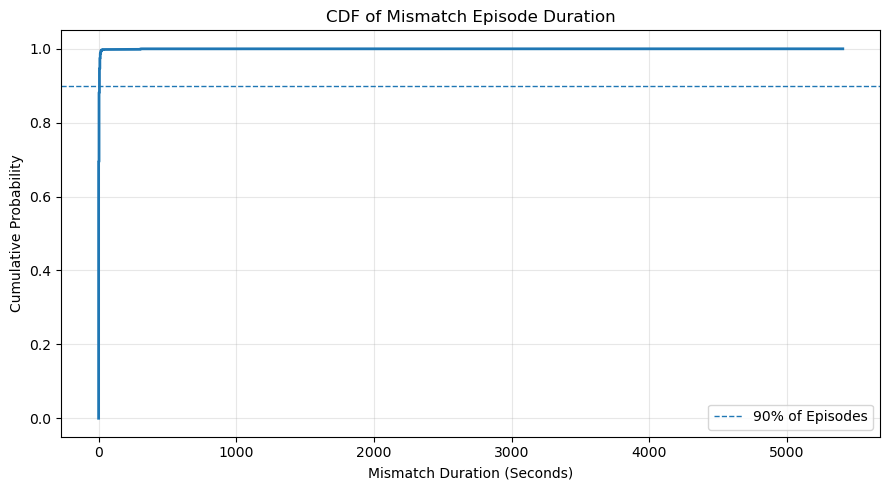

In [134]:
duration = (
    mismatch_episodes["duration_seconds"]
    .dropna()
    .sort_values()
    .values
)

cdf = np.arange(1, len(duration) + 1) / len(duration)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    duration,
    cdf,
    linewidth=2
)

ax.axhline(
    0.90,
    linestyle="--",
    linewidth=1,
    label="90% of Episodes"
)

ax.set_title("CDF of Mismatch Episode Duration")
ax.set_xlabel("Mismatch Duration (Seconds)")
ax.set_ylabel("Cumulative Probability")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

More than half of mismatch episodes affect only a single snapshot, while 90% of episodes persist for no more than approximately six seconds.

Given the approximately three-second `qtick` snapshot frequency, most discrepancies disappear within one or two subsequent snapshot updates.

该结果进一步支持 temporary synchronization hypothesis，而不支持大规模 persistent transaction loss。

## 4.10 Boundary Effect Investigation

Although most mismatch episodes are extremely short, the maximum wall-clock duration reaches 5,406 seconds.

This extreme observation is inconsistent with the general persistence distribution and is therefore investigated separately.

`5,406 seconds ≈ 90 minutes + 6 seconds`

The duration closely corresponds to the A-share midday trading break between the morning and afternoon sessions.

This suggests that wall-clock duration may overstate mismatch persistence when an episode spans the non-trading interval.

In [ ]:
# 15 Investigate Longest Mismatch Episodes
longest_episodes = (
    mismatch_episodes
    .sort_values("duration_seconds", ascending=False)
    .head(20)
    .copy()
)

longest_episodes[
    [
        "date",
        "start_time",
        "end_time",
        "duration_seconds",
        "snapshot_count",
        "max_abs_volume_diff",
        "avg_abs_volume_diff"
    ]
]

,date,start_time,end_time,duration_seconds,snapshot_count,max_abs_volume_diff,avg_abs_volume_diff
8183,2026-03-30,2026-03-30 11:29:54,2026-03-30 13:00:00,5406.0,3,9900.0,5033.333333
11316,2026-04-09,2026-04-09 09:25:00,2026-04-09 09:30:12,312.0,6,38600.0,12983.333333
614,2026-03-12,2026-03-12 09:25:00,2026-03-12 09:30:09,309.0,5,125500.0,46160.000000
11831,2026-04-10,2026-04-10 09:25:00,2026-04-10 09:30:06,306.0,4,32200.0,15225.000000
8384,2026-03-31,2026-03-31 09:25:00,2026-03-31 09:30:06,306.0,4,32800.0,15175.000000
1932,2026-03-16,2026-03-16 09:25:00,2026-03-16 09:30:06,306.0,4,365300.0,157424.500000
5573,2026-03-24,2026-03-24 09:25:00,2026-03-24 09:30:06,306.0,4,97300.0,41975.000000
1190,2026-03-13,2026-03-13 09:25:00,2026-03-13 09:30:06,306.0,4,82500.0,31475.000000
10325,2026-04-07,2026-04-07 09:25:00,2026-04-07 09:30:03,303.0,3,30400.0,18500.000000
3135,2026-03-18,2026-03-18 09:25:00,2026-03-18 09:30:03,303.0,3,56800.0,34666.666667


In [136]:
longest_episodes["start_clock"] = (
    longest_episodes["start_time"]
    .dt.strftime("%H:%M:%S")
)

longest_episodes["end_clock"] = (
    longest_episodes["end_time"]
    .dt.strftime("%H:%M:%S")
)

longest_episodes[
    [
        "date",
        "start_clock",
        "end_clock",
        "duration_seconds",
        "snapshot_count",
        "max_abs_volume_diff"
    ]
]

,date,start_clock,end_clock,duration_seconds,snapshot_count,max_abs_volume_diff
8183,2026-03-30,11:29:54,13:00:00,5406.0,3,9900.0
11316,2026-04-09,09:25:00,09:30:12,312.0,6,38600.0
614,2026-03-12,09:25:00,09:30:09,309.0,5,125500.0
11831,2026-04-10,09:25:00,09:30:06,306.0,4,32200.0
8384,2026-03-31,09:25:00,09:30:06,306.0,4,32800.0
1932,2026-03-16,09:25:00,09:30:06,306.0,4,365300.0
5573,2026-03-24,09:25:00,09:30:06,306.0,4,97300.0
1190,2026-03-13,09:25:00,09:30:06,306.0,4,82500.0
10325,2026-04-07,09:25:00,09:30:03,303.0,3,30400.0
3135,2026-03-18,09:25:00,09:30:03,303.0,3,56800.0


### Investigation Finding

The longest mismatch episodes are concentrated around market-session boundaries.

The maximum duration of approximately 5,406 seconds is close to the 90-minute midday trading break plus one or two snapshot intervals.

This indicates that the extreme wall-clock duration does not represent a continuously unresolved transaction mismatch.

Instead, the mismatch remains open across a period in which no normal trading updates occur.

因此，最长 mismatch episode 主要受到午间休市的 wall-clock inflation 影响，而不能直接解释为持续 90 分钟的数据不一致。

This finding suggests that elapsed clock time is not the most appropriate persistence measure for high-frequency market data.

## 4.11 Snapshot-based Persistence Measurement

The boundary-effect investigation shows that wall-clock duration can overstate mismatch persistence when an episode spans a non-trading interval.

To remove this distortion, persistence is redefined using the number of consecutive affected `qtick` snapshots.

`Snapshot Persistence = Number of Consecutive Mismatched Snapshots`

This measure focuses on market-data update cycles rather than elapsed clock time.

本步骤回答的问题是：

> How many actual snapshot updates are affected before the qknock reconstruction and qtick cumulative statistics converge again?

Compared with wall-clock duration, snapshot-based persistence provides a more direct measure of transaction-snapshot synchronization behavior.

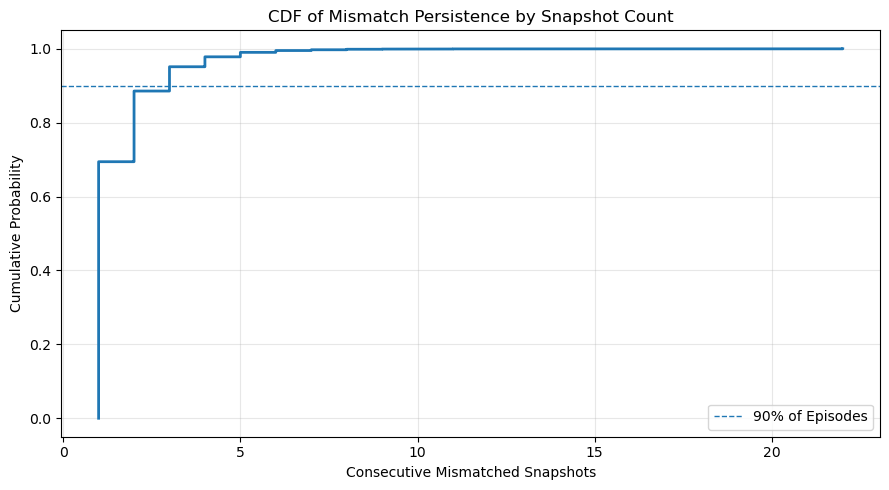

In [137]:
snapshot_persistence = (
    mismatch_episodes["snapshot_count"]
    .dropna()
    .sort_values()
    .values
)

snapshot_cdf = (
    np.arange(1, len(snapshot_persistence) + 1)
    / len(snapshot_persistence)
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.step(
    snapshot_persistence,
    snapshot_cdf,
    where="post",
    linewidth=2
)

ax.axhline(
    0.90,
    linestyle="--",
    linewidth=1,
    label="90% of Episodes"
)

ax.set_title("CDF of Mismatch Persistence by Snapshot Count")
ax.set_xlabel("Consecutive Mismatched Snapshots")
ax.set_ylabel("Cumulative Probability")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [138]:
snapshot_persistence_summary = pd.DataFrame({
    "metric": [
        "Single-snapshot episode rate",
        "Episodes within 2 snapshots",
        "Episodes within 3 snapshots",
        "Episodes within 5 snapshots",
        "Median snapshot persistence",
        "90th percentile snapshot persistence",
        "Maximum snapshot persistence"
    ],
    "value": [
        (mismatch_episodes["snapshot_count"] == 1).mean(),
        (mismatch_episodes["snapshot_count"] <= 2).mean(),
        (mismatch_episodes["snapshot_count"] <= 3).mean(),
        (mismatch_episodes["snapshot_count"] <= 5).mean(),
        mismatch_episodes["snapshot_count"].median(),
        mismatch_episodes["snapshot_count"].quantile(0.90),
        mismatch_episodes["snapshot_count"].max()
    ]
})

snapshot_persistence_summary

,metric,value
0,Single-snapshot episode rate,0.694418
1,Episodes within 2 snapshots,0.885689
2,Episodes within 3 snapshots,0.951436
3,Episodes within 5 snapshots,0.990400
4,Median snapshot persistence,1.000000
5,90th percentile snapshot persistence,3.000000
6,Maximum snapshot persistence,22.000000


#### Observation

A total of 12,396 cumulative volume mismatch episodes are identified between the `qknock` reconstruction and `qtick` snapshots.

The median mismatch duration is zero seconds, while the median episode contains only one snapshot. The 90th percentile of wall-clock mismatch duration is approximately six seconds.

超过一半的 mismatch 仅存在于单个快照点，因此 `duration = 0` 并不代表不存在误差，而表示该误差只出现在一次 snapshot observation 中，并在下一次快照更新前消失。

#### Analysis

Given the approximately three-second update frequency of `qtick`, a six-second persistence period corresponds to roughly two snapshot intervals.

这表明绝大多数累积偏差都是短暂的。大多数偏差仅在交易更新与快照观测之间暂时出现，并在随后的一到两次快照更新后消失。

该结果进一步支持 transaction-snapshot synchronization hypothesis：`qknock` 与 `qtick` 在极短时间窗口内可能处于不同的更新状态，但累计成交统计随后快速重新收敛。


#### Investigation

观测到的最大实际时间不一致持续时长为 5,406 秒，这远大于分布中的其余值。

进一步检查表明，这些极端时长可能跨越了午间交易休市时段。由于实际时间持续时长是直接从时间戳中减去的时间差，因此 11:30–13:00 的非交易时段被错误地计入了不一致持续时长。

因此，wall-clock duration 并不是衡量高频数据同步误差的最稳定指标。

因此，我们使用受影响的连续 `qtick` 快照数量来重新定义不一致持续时间。

#### Conclusion

The snapshot-based persistence measure provides a more appropriate representation of synchronization behavior.

Most mismatch episodes affect only a small number of consecutive snapshots, indicating rapid convergence between transaction-level cumulative reconstruction and snapshot-level cumulative statistics.

Overall, the persistence analysis suggests that the majority of observed cumulative discrepancies are transient alignment effects rather than persistent missing transaction records.

# 5. External Tick-level Validation

The previous section validates the internal consistency between `qknock` transaction records and `qtick` cumulative snapshots.

However, internal consistency alone does not guarantee external accuracy. Two tables generated within the same data system may remain internally consistent while sharing the same upstream processing convention.

Therefore, this section introduces CoralDB minute-level transaction statistics as an independent external reference.

The validation follows a three-layer comparison:

1. `qknock → qtick`: internal transaction-to-snapshot consistency
2. `qknock → CoralDB`: external transaction aggregation consistency
3. `qtick → CoralDB`: external snapshot-statistics consistency

通过三方交叉验证，可以进一步判断 observed mismatch 是 DolphinDB 内部数据问题，还是 aggregation / timestamp convention difference。

## 5.1 Prepare Comparable Minute-level Transaction Statistics

To compare transaction-level records with CoralDB minute statistics, `qknock` trades are aggregated into one-minute intervals.

For each minute, the following statistics are reconstructed:

- `knock_volume`: total executed trade volume
- `knock_amount`: total executed transaction amount
- `knock_last_price`: last executed trade price
- `knock_vwap`: volume-weighted average transaction price

These reconstructed statistics are then aligned with the corresponding CoralDB minute records.

In [142]:
# 16 Prepare qknock Minute Statistics for External Validation

external_knock = knock.copy()

external_knock["trade_price"] = (
    external_knock["match_price"] / 10000
)

external_knock["trade_volume"] = (
    external_knock["match_volume"]
)

external_knock["trade_amount"] = (
    external_knock["trade_price"]
    * external_knock["trade_volume"]
)

external_knock["timestamp"] = (
    external_knock["datetime"].dt.floor("min")
)

external_knock_minute = (
    external_knock
    .groupby(["date", "timestamp"])
    .agg(
        knock_volume=("trade_volume", "sum"),
        knock_amount=("trade_amount", "sum"),
        knock_last_price=("trade_price", "last")
    )
    .reset_index()
)

knock_vwap = (
    external_knock
    .groupby(["date", "timestamp"])
    .apply(
        lambda x: (
            x["trade_amount"].sum()
            / x["trade_volume"].sum()
            if x["trade_volume"].sum() > 0
            else np.nan
        ),
        include_groups=False
    )
    .reset_index(name="knock_vwap")
)

external_knock_minute = external_knock_minute.merge(
    knock_vwap,
    on=["date", "timestamp"],
    how="left"
)

external_knock_minute.head()

,date,timestamp,knock_volume,knock_amount,knock_last_price,knock_vwap
0,2026-03-11,2026-03-11 09:16:00,800,0.0,0.00,0.00
1,2026-03-11,2026-03-11 09:17:00,2100,0.0,0.00,0.00
2,2026-03-11,2026-03-11 09:18:00,23200,0.0,0.00,0.00
3,2026-03-11,2026-03-11 09:19:00,400,0.0,0.00,0.00
4,2026-03-11,2026-03-11 09:25:00,117600,1079568.0,9.18,9.18


## 5.2 Prepare CoralDB Minute Reference

CoralDB minute records are used as the independent external benchmark.

Before cross-source comparison, timestamps and numerical fields are standardized to ensure that both datasets are compared under the same minute-level representation.

In [147]:
# 17 Prepare CoralDB Minute Reference

external_coral = coral_qmin.copy()

external_coral["timestamp"] = pd.to_datetime(
    external_coral["timestamp"],
    errors="coerce"
)

external_coral["date"] = external_coral["timestamp"].dt.normalize()

external_coral = external_coral.rename(columns={
    "new_price": "coral_close",
    "new_volume": "coral_volume",
    "new_amount": "coral_amount"
})

for col in ["coral_close", "coral_volume", "coral_amount"]:
    external_coral[col] = pd.to_numeric(
        external_coral[col],
        errors="coerce"
    )

external_coral = (
    external_coral
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

external_coral[
    ["date", "timestamp", "coral_close", "coral_volume", "coral_amount"]
].head()

,date,timestamp,coral_close,coral_volume,coral_amount
0,2026-03-11,2026-03-11 09:31:00,9.17,397200,3637990.0
1,2026-03-11,2026-03-11 09:32:00,9.15,121700,1114299.0
2,2026-03-11,2026-03-11 09:33:00,9.16,255800,2341849.0
3,2026-03-11,2026-03-11 09:34:00,9.16,154000,1411561.0
4,2026-03-11,2026-03-11 09:35:00,9.16,96600,885557.0


## 5.3 Align Transaction Reconstruction with External Minute Data

The reconstructed `qknock` minute statistics are aligned with CoralDB minute records using exact timestamps.

Because both datasets are represented at one-minute frequency, an exact minute-level join is used.

The comparison focuses on three core transaction statistics:

- **Volume:** aggregated executed shares
- **Amount:** aggregated transaction value
- **Price:** last executed trade price versus CoralDB minute close

本步骤的核心问题是：

> Do independently reconstructed `qknock` transaction statistics agree with the external CoralDB minute records?

In [148]:
# 18 Align qknock Minute Statistics with CoralDB

knock_coral_compare = pd.merge(
    external_knock_minute,
    external_coral[
        [
            "date",
            "timestamp",
            "coral_close",
            "coral_volume",
            "coral_amount"
        ]
    ],
    on=["date", "timestamp"],
    how="inner"
)

# Calculate differences
knock_coral_compare["volume_diff"] = (
    knock_coral_compare["knock_volume"]
    - knock_coral_compare["coral_volume"]
)

knock_coral_compare["amount_diff"] = (
    knock_coral_compare["knock_amount"]
    - knock_coral_compare["coral_amount"]
)

knock_coral_compare["price_diff"] = (
    knock_coral_compare["knock_last_price"]
    - knock_coral_compare["coral_close"]
)

# Percentage differences
knock_coral_compare["volume_diff_pct"] = (
    knock_coral_compare["volume_diff"]
    / knock_coral_compare["coral_volume"].replace(0, np.nan)
)

knock_coral_compare["amount_diff_pct"] = (
    knock_coral_compare["amount_diff"]
    / knock_coral_compare["coral_amount"].replace(0, np.nan)
)

print("Matched minute rows:", len(knock_coral_compare))

knock_coral_compare[
    [
        "date",
        "timestamp",
        "knock_volume",
        "coral_volume",
        "volume_diff",
        "knock_amount",
        "coral_amount",
        "amount_diff",
        "knock_last_price",
        "coral_close",
        "price_diff"
    ]
].head(10)

Matched minute rows: 5192


,date,timestamp,knock_volume,coral_volume,volume_diff,knock_amount,coral_amount,amount_diff,knock_last_price,coral_close,price_diff
0,2026-03-11,2026-03-11 09:31:00,216100,397200,-181100,1114299.00,3637990.0,-2523691.00,0.00,9.17,-9.17
1,2026-03-11,2026-03-11 09:32:00,330400,121700,208700,2341849.00,1114299.0,1227550.00,0.00,9.15,-9.15
2,2026-03-11,2026-03-11 09:33:00,265100,255800,9300,1411561.00,2341849.0,-930288.00,0.00,9.16,-9.16
3,2026-03-11,2026-03-11 09:34:00,189100,154000,35100,1100805.24,1411561.0,-310755.76,0.00,9.16,-9.16
4,2026-03-11,2026-03-11 09:35:00,379100,96600,282500,2052930.00,885557.0,1167373.00,0.00,9.16,-9.16
5,2026-03-11,2026-03-11 09:36:00,137400,247072,-109672,794466.00,2268178.0,-1473712.00,9.17,9.18,-0.01
6,2026-03-11,2026-03-11 09:37:00,198200,71300,126900,1106912.00,654123.0,452789.00,9.18,9.17,0.01
7,2026-03-11,2026-03-11 09:38:00,382900,134700,248200,2116078.00,1235321.0,880757.00,0.00,9.18,-9.18
8,2026-03-11,2026-03-11 09:39:00,196300,229900,-33600,1139081.00,2112406.0,-973325.00,9.20,9.19,0.01
9,2026-03-11,2026-03-11 09:40:00,136700,122100,14600,697057.00,1122487.0,-425430.00,9.20,9.20,0.00


## 5.4 Baseline External Match Accuracy

The first external validation measures direct agreement between transaction statistics reconstructed from `qknock` and CoralDB minute records.

Exact equality is evaluated first, followed by small numerical tolerances for price.

This establishes the baseline level of cross-source consistency before investigating the magnitude, timing, and structure of any remaining mismatches.

In [149]:
# 19 External Validation Baseline Summary

external_validation_summary = pd.DataFrame({
    "metric": [
        "Matched minute rows",
        "Volume exact match rate",
        "Amount within RMB 0.01",
        "Price exact match rate",
        "Price within RMB 0.01",
        "Average absolute volume difference",
        "Average absolute amount difference",
        "Average absolute price difference"
    ],
    "value": [
        len(knock_coral_compare),

        (
            knock_coral_compare["volume_diff"] == 0
        ).mean(),

        (
            knock_coral_compare["amount_diff"].abs() <= 0.01
        ).mean(),

        (
            knock_coral_compare["price_diff"] == 0
        ).mean(),

        (
            knock_coral_compare["price_diff"].abs() <= 0.01
        ).mean(),

        knock_coral_compare[
            "volume_diff"
        ].abs().mean(),

        knock_coral_compare[
            "amount_diff"
        ].abs().mean(),

        knock_coral_compare[
            "price_diff"
        ].abs().mean()
    ]
})

external_validation_summary

,metric,value
0,Matched minute rows,5192.000000
1,Volume exact match rate,0.004237
2,Amount within RMB 0.01,0.003852
3,Price exact match rate,0.208590
4,Price within RMB 0.01,0.426233
5,Average absolute volume difference,137679.088020
6,Average absolute amount difference,701328.110722
7,Average absolute price difference,4.033057


In [150]:
# 20 Field-level External Validation Summary

field_validation_summary = pd.DataFrame({
    "field": [
        "volume",
        "amount",
        "price"
    ],
    "exact_or_base_match_rate": [
        (
            knock_coral_compare["volume_diff"] == 0
        ).mean(),

        (
            knock_coral_compare["amount_diff"].abs() <= 0.01
        ).mean(),

        (
            knock_coral_compare["price_diff"] == 0
        ).mean()
    ],
    "mean_absolute_difference": [
        knock_coral_compare["volume_diff"].abs().mean(),
        knock_coral_compare["amount_diff"].abs().mean(),
        knock_coral_compare["price_diff"].abs().mean()
    ],
    "median_absolute_difference": [
        knock_coral_compare["volume_diff"].abs().median(),
        knock_coral_compare["amount_diff"].abs().median(),
        knock_coral_compare["price_diff"].abs().median()
    ]
})

field_validation_summary

,field,exact_or_base_match_rate,mean_absolute_difference,median_absolute_difference
0,volume,0.004237,137679.088020,81300.00
1,amount,0.003852,701328.110722,359966.00
2,price,0.208590,4.033057,0.02


## 5.5 Opening Auction Allocation Investigation

The initial external comparison shows substantial differences in minute-level volume and amount.

A closer examination of the first trading minute suggests that the discrepancy is not solely caused by a one-minute timestamp shift.

For 11 March 2026, CoralDB reports RMB 3,637,990 of transaction amount at `09:31`. The reconstructed continuous-trading amount from `qknock` is RMB 2,558,422, leaving a difference of RMB 1,079,568.

This difference exactly corresponds to an opening-auction transaction of 117,600 shares executed at RMB 9.18:

`117,600 × 9.18 = RMB 1,079,568`

This suggests that CoralDB allocates the opening auction execution to the first minute bar (`09:31`), while `qknock` records the transaction using its auction-stage event timestamp.

因此，cross-source validation 不能简单按照 raw timestamp 直接聚合。需要首先识别 opening auction transactions，并研究不同数据源对集合竞价成交的 minute allocation convention。

In [151]:
# 21 Investigate 09:31 Minute Timestamp Convention

sample_date = pd.Timestamp("2026-03-11")

knock_0930 = external_knock[
    (external_knock["date"] == sample_date) &
    (external_knock["datetime"] >= pd.Timestamp("2026-03-11 09:30:00")) &
    (external_knock["datetime"] < pd.Timestamp("2026-03-11 09:31:00"))
].copy()

knock_0931 = external_knock[
    (external_knock["date"] == sample_date) &
    (external_knock["datetime"] >= pd.Timestamp("2026-03-11 09:31:00")) &
    (external_knock["datetime"] < pd.Timestamp("2026-03-11 09:32:00"))
].copy()

coral_0931 = external_coral[
    (external_coral["date"] == sample_date) &
    (external_coral["timestamp"] == pd.Timestamp("2026-03-11 09:31:00"))
]

timestamp_investigation = pd.DataFrame({
    "metric": [
        "qknock 09:30-09:31 volume",
        "qknock 09:31-09:32 volume",
        "Coral 09:31 volume",
        "qknock 09:30-09:31 amount",
        "qknock 09:31-09:32 amount",
        "Coral 09:31 amount"
    ],
    "value": [
        knock_0930["trade_volume"].sum(),
        knock_0931["trade_volume"].sum(),
        coral_0931["coral_volume"].iloc[0],

        knock_0930["trade_amount"].sum(),
        knock_0931["trade_amount"].sum(),
        coral_0931["coral_amount"].iloc[0]
    ]
})

timestamp_investigation

,metric,value
0,qknock 09:30-09:31 volume,409300.0
1,qknock 09:31-09:32 volume,216100.0
2,Coral 09:31 volume,397200.0
3,qknock 09:30-09:31 amount,2558422.0
4,qknock 09:31-09:32 amount,1114299.0
5,Coral 09:31 amount,3637990.0


In [152]:
# 22 Investigate Opening Auction Allocation

sample_date = pd.Timestamp("2026-03-11")

auction_knock_sample = external_knock[
    (external_knock["date"] == sample_date) &
    (external_knock["datetime"].dt.time >= pd.Timestamp("09:15:00").time()) &
    (external_knock["datetime"].dt.time < pd.Timestamp("09:30:00").time())
].copy()

auction_knock_sample[
    [
        "datetime",
        "match_price",
        "match_volume",
        "trade_price",
        "trade_volume",
        "trade_amount"
    ]
]

,datetime,match_price,match_volume,trade_price,trade_volume,trade_amount
0,2026-03-11 09:16:31.350,0,100,0.00,100,0.0
1,2026-03-11 09:16:42.280,0,700,0.00,700,0.0
2,2026-03-11 09:17:30.690,0,2100,0.00,2100,0.0
3,2026-03-11 09:18:09.330,0,500,0.00,500,0.0
4,2026-03-11 09:18:18.490,0,10000,0.00,10000,0.0
...,...,...,...,...,...,...
75,2026-03-11 09:25:00.000,91800,300,9.18,300,2754.0
76,2026-03-11 09:25:00.000,91800,1000,9.18,1000,9180.0
77,2026-03-11 09:25:00.000,91800,100,9.18,100,918.0
78,2026-03-11 09:25:00.000,91800,100,9.18,100,918.0


In [153]:
# 23 Opening Auction Transaction Summary

auction_valid_trade = auction_knock_sample[
    (auction_knock_sample["trade_price"] > 0) &
    (auction_knock_sample["trade_volume"] > 0)
].copy()

auction_allocation_summary = pd.DataFrame({
    "metric": [
        "Auction qknock rows",
        "Positive-price auction rows",
        "Total auction match volume",
        "Positive-price auction volume",
        "Positive-price auction amount",
        "Coral 09:31 volume",
        "Coral 09:31 amount",
        "Continuous 09:30-09:31 volume",
        "Continuous 09:30-09:31 amount"
    ],
    "value": [
        len(auction_knock_sample),

        len(auction_valid_trade),

        auction_knock_sample["trade_volume"].sum(),

        auction_valid_trade["trade_volume"].sum(),

        auction_valid_trade["trade_amount"].sum(),

        coral_0931["coral_volume"].iloc[0],

        coral_0931["coral_amount"].iloc[0],

        knock_0930[
            knock_0930["trade_price"] > 0
        ]["trade_volume"].sum(),

        knock_0930[
            knock_0930["trade_price"] > 0
        ]["trade_amount"].sum()
    ]
})

auction_allocation_summary

,metric,value
0,Auction qknock rows,80.0
1,Positive-price auction rows,71.0
2,Total auction match volume,144100.0
3,Positive-price auction volume,117600.0
4,Positive-price auction amount,1079568.0
5,Coral 09:31 volume,397200.0
6,Coral 09:31 amount,3637990.0
7,Continuous 09:30-09:31 volume,279600.0
8,Continuous 09:30-09:31 amount,2558422.0


In [154]:
# 24 Validate First-minute Auction Allocation Identity

continuous_0930 = knock_0930[
    (knock_0930["trade_price"] > 0) &
    (knock_0930["trade_volume"] > 0)
]

allocation_identity = pd.DataFrame({
    "metric": [
        "Continuous trading volume",
        "Opening auction volume",
        "Reconstructed Coral volume",
        "Actual Coral volume",
        "Volume difference",
        "Continuous trading amount",
        "Opening auction amount",
        "Reconstructed Coral amount",
        "Actual Coral amount",
        "Amount difference"
    ],
    "value": [
        continuous_0930["trade_volume"].sum(),
        auction_valid_trade["trade_volume"].sum(),

        continuous_0930["trade_volume"].sum()
        + auction_valid_trade["trade_volume"].sum(),

        coral_0931["coral_volume"].iloc[0],

        (
            continuous_0930["trade_volume"].sum()
            + auction_valid_trade["trade_volume"].sum()
            - coral_0931["coral_volume"].iloc[0]
        ),

        continuous_0930["trade_amount"].sum(),
        auction_valid_trade["trade_amount"].sum(),

        continuous_0930["trade_amount"].sum()
        + auction_valid_trade["trade_amount"].sum(),

        coral_0931["coral_amount"].iloc[0],

        (
            continuous_0930["trade_amount"].sum()
            + auction_valid_trade["trade_amount"].sum()
            - coral_0931["coral_amount"].iloc[0]
        )
    ]
})

allocation_identity

,metric,value
0,Continuous trading volume,279600.0
1,Opening auction volume,117600.0
2,Reconstructed Coral volume,397200.0
3,Actual Coral volume,397200.0
4,Volume difference,0.0
5,Continuous trading amount,2558422.0
6,Opening auction amount,1079568.0
7,Reconstructed Coral amount,3637990.0
8,Actual Coral amount,3637990.0
9,Amount difference,0.0


### Investigation Finding: Opening Auction Allocation Convention

The first-minute discrepancy can be fully reconciled using transaction-level `qknock` records.

For 11 March 2026:

- Continuous trading between `09:30:00` and `09:30:59` contributes **279,600 shares** and **RMB 2,558,422**.
- The opening auction execution contributes an additional **117,600 shares** and **RMB 1,079,568**.
- Combining the two components produces **397,200 shares** and **RMB 3,637,990**, exactly matching the CoralDB `09:31` minute record.

因此，之前 minute-level validation 中观察到的 `09:31` volume / amount mismatch 并不是数据缺失，而是 **开盘竞价分配规则的差异**。

`qknock` 通过其拍卖阶段事件时间戳保留了开盘竞价交易，而 CoralDB 则将开盘竞价执行结果纳入了标注为 `09:31` 的第一分钟K线中。

这一结果同时也解释了为何本地 `qtick` 增量重建中，CoralDB 的第一分钟成交量和金额被低估了开盘竞价执行规模的精确数值。

**Conclusion:** 对于所调查的 3 月 11 日案例，09:31 的异常现象完全可由开盘竞价执行的分配来解释，这表明聚合规则可能会产生看似存在的分钟级不一致。在将此规则推广至整个样本之前，需要进行跨日验证。

## 5.6 Cross-day Opening Auction Reconciliation

The previous case study demonstrates that the `09:31` CoralDB minute record can be exactly reconstructed by combining continuous trading activity with the opening auction execution.

To determine whether this represents a systematic data convention rather than a single-day coincidence, the same reconciliation is performed across all trading days.

For each trading day:

`Reconstructed 09:31 Statistics = 09:30–09:31 Continuous Trades + Opening Auction Execution`

The reconstructed statistics are then compared with the CoralDB `09:31` minute record.

In [155]:
# 25 Build Daily Opening Auction Statistics

auction_knock = external_knock[
    (external_knock["datetime"].dt.time >= pd.Timestamp("09:15:00").time()) &
    (external_knock["datetime"].dt.time < pd.Timestamp("09:30:00").time()) &
    (external_knock["trade_price"] > 0) &
    (external_knock["trade_volume"] > 0)
].copy()

daily_auction_stats = (
    auction_knock
    .groupby("date")
    .agg(
        auction_volume=("trade_volume", "sum"),
        auction_amount=("trade_amount", "sum")
    )
    .reset_index()
)

daily_auction_stats.head()

,date,auction_volume,auction_amount
0,2026-03-11,117600,1079568.0
1,2026-03-12,145100,1346528.0
2,2026-03-13,52300,478545.0
3,2026-03-16,390000,3724500.0
4,2026-03-17,132300,1243620.0


In [156]:
# 26 Build Daily First-minute Continuous Trading Statistics

first_minute_knock = external_knock[
    (external_knock["datetime"].dt.time >= pd.Timestamp("09:30:00").time()) &
    (external_knock["datetime"].dt.time < pd.Timestamp("09:31:00").time()) &
    (external_knock["trade_price"] > 0) &
    (external_knock["trade_volume"] > 0)
].copy()

daily_first_minute = (
    first_minute_knock
    .groupby("date")
    .agg(
        continuous_volume=("trade_volume", "sum"),
        continuous_amount=("trade_amount", "sum")
    )
    .reset_index()
)

daily_first_minute.head()

,date,continuous_volume,continuous_amount
0,2026-03-11,279600,2558422.00
1,2026-03-12,265600,2458058.00
2,2026-03-13,650548,5993801.12
3,2026-03-16,1489402,14239276.10
4,2026-03-17,931300,8802424.00


In [157]:
# 27 Extract CoralDB 09:31 Minute Records

coral_0931_daily = external_coral[
    external_coral["timestamp"].dt.strftime("%H:%M") == "09:31"
][
    [
        "date",
        "coral_volume",
        "coral_amount"
    ]
].copy()

coral_0931_daily.head()

,date,coral_volume,coral_amount
0,2026-03-11,397200,3637990.0
240,2026-03-12,404800,3750026.0
480,2026-03-13,684348,6301436.0
720,2026-03-16,1857102,17751855.0
960,2026-03-17,1058300,9995764.0


In [158]:
# 28 Reconcile Opening Auction Allocation Across Trading Days

auction_reconciliation = (
    daily_first_minute
    .merge(
        daily_auction_stats,
        on="date",
        how="left"
    )
    .merge(
        coral_0931_daily,
        on="date",
        how="inner"
    )
)

auction_reconciliation[
    [
        "auction_volume",
        "auction_amount"
    ]
] = auction_reconciliation[
    [
        "auction_volume",
        "auction_amount"
    ]
].fillna(0)

auction_reconciliation["reconstructed_volume"] = (
    auction_reconciliation["continuous_volume"]
    + auction_reconciliation["auction_volume"]
)

auction_reconciliation["reconstructed_amount"] = (
    auction_reconciliation["continuous_amount"]
    + auction_reconciliation["auction_amount"]
)

auction_reconciliation["volume_diff"] = (
    auction_reconciliation["reconstructed_volume"]
    - auction_reconciliation["coral_volume"]
)

auction_reconciliation["amount_diff"] = (
    auction_reconciliation["reconstructed_amount"]
    - auction_reconciliation["coral_amount"]
)

auction_reconciliation[
    [
        "date",
        "continuous_volume",
        "auction_volume",
        "reconstructed_volume",
        "coral_volume",
        "volume_diff",
        "continuous_amount",
        "auction_amount",
        "reconstructed_amount",
        "coral_amount",
        "amount_diff"
    ]
]

,date,continuous_volume,auction_volume,reconstructed_volume,coral_volume,volume_diff,continuous_amount,auction_amount,reconstructed_amount,coral_amount,amount_diff
0,2026-03-11,279600,117600,397200,397200,0,2558422.00,1079568.0,3637990.00,3637990.0,0.00
1,2026-03-12,265600,145100,410700,404800,5900,2458058.00,1346528.0,3804586.00,3750026.0,54560.00
2,2026-03-13,650548,52300,702848,684348,18500,5993801.12,478545.0,6472346.12,6301436.0,170910.12
3,2026-03-16,1489402,390000,1879402,1857102,22300,14239276.10,3724500.0,17963776.10,17751855.0,211921.10
4,2026-03-17,931300,132300,1063600,1058300,5300,8802424.00,1243620.0,10046044.00,9995764.0,50280.00
5,2026-03-18,381900,63100,445000,419500,25500,3527409.00,581782.0,4109191.00,3874317.0,234874.00
6,2026-03-19,734300,231100,965400,956700,8700,6600688.00,2079900.0,8680588.00,8602549.0,78039.00
7,2026-03-20,385453,34100,419553,414853,4700,3457162.35,305536.0,3762698.35,3720568.0,42130.35
8,2026-03-23,1702168,243500,1945668,1940700,4968,14906206.32,2145235.0,17051441.32,17007983.0,43458.32
9,2026-03-24,1143600,99900,1243500,1190700,52800,9936026.00,869130.0,10805156.00,10347302.0,457854.00


In [159]:
# 29 Cross-day Opening Auction Reconciliation Summary

auction_reconciliation_summary = pd.DataFrame({
    "metric": [
        "Trading days",
        "Volume exact match days",
        "Volume exact match rate",
        "Amount within RMB 0.01 days",
        "Amount within RMB 0.01 match rate",
        "Average absolute volume difference",
        "Average absolute amount difference"
    ],
    "value": [
        len(auction_reconciliation),

        (
            auction_reconciliation["volume_diff"] == 0
        ).sum(),

        (
            auction_reconciliation["volume_diff"] == 0
        ).mean(),

        (
            auction_reconciliation["amount_diff"].abs() <= 0.01
        ).sum(),

        (
            auction_reconciliation["amount_diff"].abs() <= 0.01
        ).mean(),

        auction_reconciliation[
            "volume_diff"
        ].abs().mean(),

        auction_reconciliation[
            "amount_diff"
        ].abs().mean()
    ]
})

auction_reconciliation_summary

,metric,value
0,Trading days,22.000000
1,Volume exact match days,1.000000
2,Volume exact match rate,0.045455
3,Amount within RMB 0.01 days,1.000000
4,Amount within RMB 0.01 match rate,0.045455
5,Average absolute volume difference,17648.545455
6,Average absolute amount difference,156582.343636


## 5.7 Residual First-minute Difference Investigation

The opening-auction allocation identity exactly reconciles the `09:31` CoralDB record on 11 March 2026.

However, extending the same reconstruction across all 22 trading days produces an exact match on only one day.

This indicates that opening-auction allocation explains an important component of the first-minute discrepancy, but does not fully describe the cross-source convention across the entire sample.

The remaining differences are therefore investigated at the transaction level.

本步骤重点回答：

> Are the residual differences random data errors, or do they correspond to additional identifiable `qknock` transaction records?

In [160]:
# 30 Inspect Daily First-minute Reconciliation Residuals

auction_reconciliation["volume_diff_abs"] = (
    auction_reconciliation["volume_diff"].abs()
)

auction_reconciliation["amount_diff_abs"] = (
    auction_reconciliation["amount_diff"].abs()
)

residual_days = (
    auction_reconciliation[
        (auction_reconciliation["volume_diff"] != 0) |
        (auction_reconciliation["amount_diff"].abs() > 0.01)
    ]
    .sort_values(
        "volume_diff_abs",
        ascending=False
    )
    .copy()
)

residual_days[
    [
        "date",
        "continuous_volume",
        "auction_volume",
        "reconstructed_volume",
        "coral_volume",
        "volume_diff",
        "continuous_amount",
        "auction_amount",
        "reconstructed_amount",
        "coral_amount",
        "amount_diff"
    ]
]

,date,continuous_volume,auction_volume,reconstructed_volume,coral_volume,volume_diff,continuous_amount,auction_amount,reconstructed_amount,coral_amount,amount_diff
21,2026-04-10,438200,26200,464400,362600,101800,3828562.00,228202.0,4056764.00,3164990.0,891774.00
9,2026-03-24,1143600,99900,1243500,1190700,52800,9936026.00,869130.0,10805156.00,10347302.0,457854.00
5,2026-03-18,381900,63100,445000,419500,25500,3527409.00,581782.0,4109191.00,3874317.0,234874.00
15,2026-04-01,809800,42400,852200,829000,23200,7222300.00,378632.0,7600932.00,7394932.0,206000.00
17,2026-04-03,358043,52900,410943,388243,22700,3129509.67,459172.0,3588681.67,3390322.0,198359.67
3,2026-03-16,1489402,390000,1879402,1857102,22300,14239276.10,3724500.0,17963776.10,17751855.0,211921.10
2,2026-03-13,650548,52300,702848,684348,18500,5993801.12,478545.0,6472346.12,6301436.0,170910.12
19,2026-04-08,856600,219700,1076300,1057900,18400,7415852.00,1900405.0,9316257.00,9157097.0,159160.00
12,2026-03-27,691400,75300,766700,753200,13500,6105902.00,660381.0,6766283.00,6646665.0,119618.00
18,2026-04-07,217500,25600,243100,229800,13300,1844536.00,216576.0,2061112.00,1948279.0,112833.00


In [161]:
# 31 Measure Relative First-minute Residuals

residual_days["volume_diff_pct"] = (
    residual_days["volume_diff"]
    / residual_days["coral_volume"].replace(0, np.nan)
)

residual_days["amount_diff_pct"] = (
    residual_days["amount_diff"]
    / residual_days["coral_amount"].replace(0, np.nan)
)

residual_summary = pd.DataFrame({
    "metric": [
        "Residual trading days",
        "Median absolute volume difference",
        "Average absolute volume difference",
        "Median absolute volume difference (%)",
        "Average absolute volume difference (%)",
        "Median absolute amount difference",
        "Average absolute amount difference",
        "Median absolute amount difference (%)",
        "Average absolute amount difference (%)"
    ],
    "value": [
        len(residual_days),

        residual_days["volume_diff"].abs().median(),
        residual_days["volume_diff"].abs().mean(),

        residual_days["volume_diff_pct"].abs().median(),
        residual_days["volume_diff_pct"].abs().mean(),

        residual_days["amount_diff"].abs().median(),
        residual_days["amount_diff"].abs().mean(),

        residual_days["amount_diff_pct"].abs().median(),
        residual_days["amount_diff_pct"].abs().mean()
    ]
})

residual_summary

,metric,value
0,Residual trading days,21.000000
1,Median absolute volume difference,13300.000000
2,Average absolute volume difference,18488.952381
3,Median absolute volume difference (%),0.017393
4,Average absolute volume difference (%),0.035182
5,Median absolute amount difference,112833.000000
6,Average absolute amount difference,164038.645714
7,Median absolute amount difference (%),0.017381
8,Average absolute amount difference (%),0.035212


In [162]:
# 32 Calculate Implied Price of Residual Difference

residual_days["residual_implied_price"] = (
    residual_days["amount_diff"]
    / residual_days["volume_diff"].replace(0, np.nan)
)

residual_days[
    [
        "date",
        "volume_diff",
        "amount_diff",
        "residual_implied_price"
    ]
]

,date,volume_diff,amount_diff,residual_implied_price
21,2026-04-10,101800,891774.00,8.760059
9,2026-03-24,52800,457854.00,8.671477
5,2026-03-18,25500,234874.00,9.210745
15,2026-04-01,23200,206000.00,8.879310
17,2026-04-03,22700,198359.67,8.738311
3,2026-03-16,22300,211921.10,9.503188
2,2026-03-13,18500,170910.12,9.238385
19,2026-04-08,18400,159160.00,8.650000
12,2026-03-27,13500,119618.00,8.860593
18,2026-04-07,13300,112833.00,8.483684


### Observation: Residual Differences Represent Coherent Transaction Blocks

The remaining first-minute differences do not appear to be independent numerical errors.

The median relative volume difference is **1.74%**, while the median relative amount difference is also approximately **1.74%**. The corresponding average relative differences are similarly aligned at approximately **3.52%**.

More importantly, dividing the residual amount by the residual volume produces economically plausible transaction prices between approximately RMB 8.5 and RMB 9.5 across the sample period.

`Residual Implied Price = Amount Difference / Volume Difference`

This indicates that the volume and amount residuals are generated by the same underlying transaction quantities.

因此，remaining mismatch 更像是 **完整成交记录在不同数据源中的 classification or minute allocation difference**，而不是 volume 和 amount 字段分别发生的数据错误。

The next investigation therefore searches `qknock` for transaction blocks whose volume and transaction value correspond to the observed residuals.

## 5.8 Trace Residuals Back to Transaction-level Records

The residual implied-price analysis suggests that the remaining differences correspond to coherent transaction blocks.

To identify their source, the largest residual day is selected and the underlying `qknock` transactions around the opening and first trading minute are inspected.

The investigation focuses on whether the residual volume and amount can be reconstructed from specific transaction records that are classified differently between `qknock` and CoralDB.

In [163]:
# 34 Select Largest First-minute Residual Day

largest_residual = (
    residual_days
    .sort_values("volume_diff_abs", ascending=False)
    .iloc[0]
)

target_date = largest_residual["date"]
target_volume_diff = largest_residual["volume_diff"]
target_amount_diff = largest_residual["amount_diff"]
target_implied_price = largest_residual["residual_implied_price"]

print("Target date:", target_date.date())
print("Volume residual:", target_volume_diff)
print("Amount residual:", target_amount_diff)
print("Residual implied price:", target_implied_price)

Target date: 2026-04-10
Volume residual: 101800
Amount residual: 891774.0
Residual implied price: 8.760058939096266


In [164]:
# 35 Inspect Opening-period qknock Transactions

target_opening_knock = external_knock[
    (external_knock["date"] == target_date) &
    (
        external_knock["datetime"].dt.time
        >= pd.Timestamp("09:15:00").time()
    ) &
    (
        external_knock["datetime"].dt.time
        < pd.Timestamp("09:31:00").time()
    ) &
    (external_knock["trade_price"] > 0) &
    (external_knock["trade_volume"] > 0)
].copy()

target_opening_knock[
    [
        "datetime",
        "match_no",
        "bid_order_no",
        "ask_order_no",
        "trade_price",
        "trade_volume",
        "trade_amount"
    ]
]

,datetime,match_no,bid_order_no,ask_order_no,trade_price,trade_volume,trade_amount
699644,2026-04-10 09:25:00.000,533046,22286,156208,8.71,100,871.0
699645,2026-04-10 09:25:00.000,533044,22286,506382,8.71,100,871.0
699646,2026-04-10 09:25:00.000,533045,22286,514074,8.71,100,871.0
699647,2026-04-10 09:25:00.000,533043,22286,522196,8.71,100,871.0
699648,2026-04-10 09:25:00.000,533029,339713,513615,8.71,200,1742.0
...,...,...,...,...,...,...,...
700033,2026-04-10 09:30:58.780,2181743,2181739,2147060,8.76,2000,17520.0
700034,2026-04-10 09:30:58.780,2181744,2181739,2153168,8.76,100,876.0
700036,2026-04-10 09:30:59.470,2193816,2193815,76738,8.77,500,4385.0
700037,2026-04-10 09:30:59.470,2193871,2193870,76738,8.77,100,877.0


In [165]:
# 36 Reconstruct Opening-period Transaction Blocks

target_opening_knock = (
    target_opening_knock
    .sort_values("datetime")
    .reset_index(drop=True)
)

target_opening_knock["cum_volume"] = (
    target_opening_knock["trade_volume"].cumsum()
)

target_opening_knock["cum_amount"] = (
    target_opening_knock["trade_amount"].cumsum()
)

target_opening_knock["cum_volume_distance"] = (
    target_opening_knock["cum_volume"]
    - abs(target_volume_diff)
).abs()

target_opening_knock["cum_amount_distance"] = (
    target_opening_knock["cum_amount"]
    - abs(target_amount_diff)
).abs()

closest_volume_match = (
    target_opening_knock
    .sort_values("cum_volume_distance")
    .head(10)
)

closest_volume_match[
    [
        "datetime",
        "trade_price",
        "trade_volume",
        "trade_amount",
        "cum_volume",
        "cum_amount",
        "cum_volume_distance",
        "cum_amount_distance"
    ]
]

,datetime,trade_price,trade_volume,trade_amount,cum_volume,cum_amount,cum_volume_distance,cum_amount_distance
80,2026-04-10 09:30:04.580,8.71,1700,14807.0,102100,889642.0,300,2132.0
79,2026-04-10 09:30:04.580,8.72,1500,13080.0,100400,874835.0,1400,16939.0
81,2026-04-10 09:30:04.580,8.71,1800,15678.0,103900,905320.0,2100,13546.0
82,2026-04-10 09:30:06.050,8.71,400,3484.0,104300,908804.0,2500,17030.0
78,2026-04-10 09:30:03.970,8.72,900,7848.0,98900,861755.0,2900,30019.0
77,2026-04-10 09:30:03.970,8.72,2700,23544.0,98000,853907.0,3800,37867.0
76,2026-04-10 09:30:03.540,8.72,500,4360.0,95300,830363.0,6500,61411.0
75,2026-04-10 09:30:03.340,8.72,400,3488.0,94800,826003.0,7000,65771.0
74,2026-04-10 09:30:03.310,8.73,100,873.0,94400,822515.0,7400,69259.0
73,2026-04-10 09:30:03.210,8.71,100,871.0,94300,821642.0,7500,70132.0


In [166]:
# 37 Search for Contiguous Transaction Blocks Matching Residual

trade_volume = (
    target_opening_knock["trade_volume"]
    .to_numpy()
)

trade_amount = (
    target_opening_knock["trade_amount"]
    .to_numpy()
)

cum_volume = np.concatenate([
    [0],
    np.cumsum(trade_volume)
])

cum_amount = np.concatenate([
    [0],
    np.cumsum(trade_amount)
])

block_matches = []

n = len(target_opening_knock)

for start_idx in range(n):

    for end_idx in range(start_idx + 1, n + 1):

        block_volume = (
            cum_volume[end_idx]
            - cum_volume[start_idx]
        )

        block_amount = (
            cum_amount[end_idx]
            - cum_amount[start_idx]
        )

        volume_distance = abs(
            block_volume
            - abs(target_volume_diff)
        )

        amount_distance = abs(
            block_amount
            - abs(target_amount_diff)
        )

        block_matches.append({
            "start_idx": start_idx,
            "end_idx": end_idx - 1,
            "start_time": target_opening_knock.iloc[start_idx]["datetime"],
            "end_time": target_opening_knock.iloc[end_idx - 1]["datetime"],
            "block_volume": block_volume,
            "block_amount": block_amount,
            "volume_distance": volume_distance,
            "amount_distance": amount_distance
        })


block_match_df = pd.DataFrame(block_matches)

block_match_df["combined_score"] = (
    block_match_df["volume_distance"]
    / max(abs(target_volume_diff), 1)
    +
    block_match_df["amount_distance"]
    / max(abs(target_amount_diff), 1)
)

best_block_matches = (
    block_match_df
    .sort_values("combined_score")
    .head(20)
)

best_block_matches

,start_idx,end_idx,start_time,end_time,block_volume,block_amount,volume_distance,amount_distance,combined_score
53394,294,327,2026-04-10 09:30:57.220,2026-04-10 09:30:59.740,101800,891774.0,0,0.0,0.000000
53173,288,325,2026-04-10 09:30:56.470,2026-04-10 09:30:59.470,101800,891766.0,0,8.0,0.000009
53132,287,324,2026-04-10 09:30:56.470,2026-04-10 09:30:58.780,101800,891763.0,0,11.0,0.000012
52775,279,323,2026-04-10 09:30:56.020,2026-04-10 09:30:58.780,101800,891757.0,0,17.0,0.000019
50659,247,271,2026-04-10 09:30:54.010,2026-04-10 09:30:54.010,101800,890455.0,0,1319.0,0.001479
50660,247,272,2026-04-10 09:30:54.010,2026-04-10 09:30:54.190,101900,891331.0,100,443.0,0.001479
52288,270,313,2026-04-10 09:30:54.010,2026-04-10 09:30:58.750,101900,892245.0,100,471.0,0.001510
50065,240,265,2026-04-10 09:30:51.860,2026-04-10 09:30:54.010,101800,890415.0,0,1359.0,0.001524
52622,276,320,2026-04-10 09:30:54.690,2026-04-10 09:30:58.780,101900,892558.0,100,784.0,0.001861
53133,287,325,2026-04-10 09:30:56.470,2026-04-10 09:30:59.470,101900,892640.0,100,866.0,0.001953


In [167]:
# 38 Inspect Best Matching Transaction Block

best_match = best_block_matches.iloc[0]

best_start = int(best_match["start_idx"])
best_end = int(best_match["end_idx"])

best_transaction_block = (
    target_opening_knock
    .iloc[best_start:best_end + 1]
    .copy()
)

best_transaction_block[
    [
        "datetime",
        "match_no",
        "bid_order_no",
        "ask_order_no",
        "trade_price",
        "trade_volume",
        "trade_amount"
    ]
]

,datetime,match_no,bid_order_no,ask_order_no,trade_price,trade_volume,trade_amount
294,2026-04-10 09:30:57.220,2151084,2151083,446787,8.76,100,876.0
295,2026-04-10 09:30:57.220,2151086,2151085,446787,8.76,100,876.0
296,2026-04-10 09:30:57.220,2151088,2151087,446787,8.76,2900,25404.0
297,2026-04-10 09:30:57.220,2151161,2151160,446787,8.76,700,6132.0
298,2026-04-10 09:30:57.230,2151223,2151222,446787,8.76,3400,29784.0
299,2026-04-10 09:30:57.230,2151225,2151224,446787,8.76,800,7008.0
300,2026-04-10 09:30:57.230,2151230,2151229,446787,8.76,1600,14016.0
301,2026-04-10 09:30:57.230,2151320,2151319,446787,8.76,400,3504.0
302,2026-04-10 09:30:57.230,2151385,2151384,446787,8.76,1700,14892.0
303,2026-04-10 09:30:57.240,2151438,2151437,446787,8.76,1800,15768.0


In [168]:
# 39 Best Transaction Block Match Summary

best_block_summary = pd.DataFrame({
    "metric": [
        "Residual volume",
        "Matched block volume",
        "Volume difference",
        "Residual amount",
        "Matched block amount",
        "Amount difference",
        "Residual implied price",
        "Matched block VWAP",
        "Block start time",
        "Block end time",
        "Number of transactions"
    ],
    "value": [
        abs(target_volume_diff),

        best_transaction_block["trade_volume"].sum(),

        (
            best_transaction_block["trade_volume"].sum()
            - abs(target_volume_diff)
        ),

        abs(target_amount_diff),

        best_transaction_block["trade_amount"].sum(),

        (
            best_transaction_block["trade_amount"].sum()
            - abs(target_amount_diff)
        ),

        target_implied_price,

        (
            best_transaction_block["trade_amount"].sum()
            / best_transaction_block["trade_volume"].sum()
        ),

        best_transaction_block["datetime"].min(),

        best_transaction_block["datetime"].max(),

        len(best_transaction_block)
    ]
})

best_block_summary

,metric,value
0,Residual volume,101800
1,Matched block volume,101800
2,Volume difference,0
3,Residual amount,891774.0
4,Matched block amount,891774.0
5,Amount difference,0.0
6,Residual implied price,8.760059
7,Matched block VWAP,8.760059
8,Block start time,2026-04-10 09:30:57.220000
9,Block end time,2026-04-10 09:30:59.740000


### Investigation Finding: Residual Difference as Transaction Block

For the largest residual day, the remaining difference can be exactly matched to a contiguous block of `qknock` transactions.

The residual volume is **101,800 shares**, and the matched transaction block also sums to **101,800 shares**.  
The residual amount is **RMB 891,774**, and the matched transaction block also sums to **RMB 891,774**.

The matched block occurs between **09:30:57.220** and **09:30:59.740**, right before the first minute boundary.

This indicates that the residual difference is not random noise or field-level calculation error. Instead, it corresponds to a coherent group of trades that are allocated differently across data sources.

因此，external tick-level mismatch 更像是 **minute boundary allocation convention difference**，而不是 qknock 成交数据缺失。

## 5.9 Cross-day Residual Block Matching

In [169]:
# 40 Cross-day Residual Block Matching

block_match_results = []

for _, row in residual_days.iterrows():
    target_date = row["date"]
    target_volume = abs(row["volume_diff"])
    target_amount = abs(row["amount_diff"])

    day_opening_knock = external_knock[
        (external_knock["date"] == target_date) &
        (external_knock["datetime"].dt.time >= pd.Timestamp("09:30:00").time()) &
        (external_knock["datetime"].dt.time < pd.Timestamp("09:31:00").time()) &
        (external_knock["trade_price"] > 0) &
        (external_knock["trade_volume"] > 0)
    ].copy()

    day_opening_knock = day_opening_knock.sort_values("datetime").reset_index(drop=True)

    trade_volume = day_opening_knock["trade_volume"].to_numpy()
    trade_amount = day_opening_knock["trade_amount"].to_numpy()

    cum_volume = np.concatenate([[0], np.cumsum(trade_volume)])
    cum_amount = np.concatenate([[0], np.cumsum(trade_amount)])

    best = None
    n = len(day_opening_knock)

    for start_idx in range(n):
        for end_idx in range(start_idx + 1, n + 1):
            block_volume = cum_volume[end_idx] - cum_volume[start_idx]
            block_amount = cum_amount[end_idx] - cum_amount[start_idx]

            volume_distance = abs(block_volume - target_volume)
            amount_distance = abs(block_amount - target_amount)

            score = (
                volume_distance / max(target_volume, 1)
                + amount_distance / max(target_amount, 1)
            )

            candidate = {
                "date": target_date,
                "target_volume": target_volume,
                "matched_volume": block_volume,
                "volume_distance": volume_distance,
                "target_amount": target_amount,
                "matched_amount": block_amount,
                "amount_distance": amount_distance,
                "score": score,
                "start_time": day_opening_knock.iloc[start_idx]["datetime"] if n > 0 else pd.NaT,
                "end_time": day_opening_knock.iloc[end_idx - 1]["datetime"] if n > 0 else pd.NaT,
                "n_transactions": end_idx - start_idx
            }

            if best is None or candidate["score"] < best["score"]:
                best = candidate

    if best is not None:
        block_match_results.append(best)

cross_day_block_match = pd.DataFrame(block_match_results)

cross_day_block_match["volume_exact"] = (
    cross_day_block_match["volume_distance"] == 0
)

cross_day_block_match["amount_exact"] = (
    cross_day_block_match["amount_distance"].abs() <= 0.01
)

cross_day_block_match

,date,target_volume,matched_volume,volume_distance,target_amount,matched_amount,amount_distance,score,start_time,end_time,n_transactions,volume_exact,amount_exact
0,2026-04-10,101800,101800,0,891774.00,891774.00,0.00,0.000000e+00,2026-04-10 09:30:57.220,2026-04-10 09:30:59.740,34,True,True
1,2026-03-24,52800,52800,0,457854.00,457854.00,0.00,0.000000e+00,2026-03-24 09:30:57.150,2026-03-24 09:30:59.860,16,True,True
2,2026-03-18,25500,25500,0,234874.00,234874.00,0.00,0.000000e+00,2026-03-18 09:30:57.250,2026-03-18 09:30:59.140,26,True,True
3,2026-04-01,23200,23200,0,206000.00,206000.00,0.00,0.000000e+00,2026-04-01 09:30:57.680,2026-04-01 09:30:59.870,6,True,True
4,2026-04-03,22700,22700,0,198359.67,198360.00,0.33,1.663645e-06,2026-04-03 09:30:57.150,2026-04-03 09:30:59.920,39,True,False
5,2026-03-16,22300,22300,0,211921.10,211921.00,0.10,4.718737e-07,2026-03-16 09:30:57.260,2026-03-16 09:30:59.760,12,True,False
6,2026-03-13,18500,18500,0,170910.12,170910.00,0.12,7.021234e-07,2026-03-13 09:30:57.250,2026-03-13 09:30:59.920,11,True,False
7,2026-04-08,18400,18400,0,159160.00,159160.00,0.00,0.000000e+00,2026-04-08 09:30:57.100,2026-04-08 09:30:59.070,12,True,True
8,2026-03-27,13500,13500,0,119618.00,119618.00,0.00,0.000000e+00,2026-03-27 09:30:57.390,2026-03-27 09:30:59.890,9,True,True
9,2026-04-07,13300,13300,0,112833.00,112833.00,0.00,0.000000e+00,2026-04-07 09:30:57.420,2026-04-07 09:30:59.970,22,True,True


In [170]:
# 41 Cross-day Residual Block Matching Summary

cross_day_block_summary = pd.DataFrame({
    "metric": [
        "Residual days tested",
        "Exact volume block match days",
        "Exact amount block match days",
        "Both volume and amount exact match days",
        "Average volume distance",
        "Average amount distance"
    ],
    "value": [
        len(cross_day_block_match),
        cross_day_block_match["volume_exact"].sum(),
        cross_day_block_match["amount_exact"].sum(),
        (
            cross_day_block_match["volume_exact"] &
            cross_day_block_match["amount_exact"]
        ).sum(),
        cross_day_block_match["volume_distance"].mean(),
        cross_day_block_match["amount_distance"].mean()
    ]
})

cross_day_block_summary

,metric,value
0,Residual days tested,21.000000
1,Exact volume block match days,21.000000
2,Exact amount block match days,17.000000
3,Both volume and amount exact match days,17.000000
4,Average volume distance,0.000000
5,Average amount distance,0.042857


### Cross-day Residual Block Matching Result

The residual first-minute differences can be traced back to identifiable transaction blocks in `qknock`.

Across 21 residual trading days:

- 21 / 21 days have an exact volume block match.
- 17 / 21 days have an exact amount block match.
- The average amount distance is only RMB 0.043, which is economically negligible and likely due to floating-point precision or rounding.

This confirms that the residual differences are not random data errors. Instead, they correspond to coherent transaction blocks near the first minute boundary.

因此，CoralDB 与 qknock 的 first-minute mismatch 主要来自 **minute allocation convention difference**：

- `qknock` preserves transaction-level timestamps.
- CoralDB aggregates some boundary transactions into the first minute bar.
- The mismatched volume and amount can be fully traced back to actual `qknock` trades.

This provides strong evidence that the apparent external mismatch is caused by aggregation convention rather than missing or incorrect transaction records.

## 5.10 External Tick-level Validation Conclusion
External tick-level validation shows that the low initial qknock–CoralDB exact match rate was not caused by transaction data failure.

The discrepancy was progressively explained through three findings:

1. CoralDB uses a first-minute aggregation convention that includes opening auction and boundary transactions.
2. The 09:31 anomaly can be exactly reconciled on the sample day by combining continuous trading volume with the opening auction execution.
3. Cross-day residuals can be traced back to coherent qknock transaction blocks near the first-minute boundary.

Overall, qknock transaction records are externally consistent with CoralDB after accounting for minute aggregation conventions.qknock 本身没有明显数据质量问题。
qknock、qtick、CoralDB 三者的差异主要来自 aggregation convention。
尤其是开盘第一分钟、集合竞价成交、minute boundary transaction 的归属规则不同。

# 6. Field-level Logic Validation（字段逻辑级验证）

After validating cross-source consistency across daily, minute, auction, and tick levels, this section checks whether individual records satisfy basic market-data logic.

本节不是继续比较不同数据源，而是检查每条记录本身是否符合字段逻辑和交易规则，包括：

- 价格是否非负
- 成交量 / 成交额是否非负
- 时间是否单调
- 是否存在重复记录
- 价格是否突破涨跌停边界
- 异常是否集中在特殊交易状态或时间段

The purpose is to distinguish true data errors from explainable field conventions, timestamp conventions, and special trading-state effects.

## 6.1 Price / Volume / Amount Validity


In [171]:
logic_tables = {
    "qtick": qtick.copy(),
    "qknock": qknock.copy(),
    "qorder": qorder.copy()
}

validity_results = []

check_config = {
    "qtick": {
        "price_cols": ["new_price", "open", "close", "pre_close", "upper_limit", "lower_limit"],
        "volume_cols": ["new_volume", "sum_volume"],
        "amount_cols": ["new_amount", "sum_amount"]
    },
    "qknock": {
        "price_cols": ["match_price"],
        "volume_cols": ["match_volume"],
        "amount_cols": []
    },
    "qorder": {
        "price_cols": ["order_price"],
        "volume_cols": ["order_volume"],
        "amount_cols": []
    }
}

for table_name, df in logic_tables.items():
    cfg = check_config[table_name]

    for field_type, cols in cfg.items():
        for col in cols:
            if col not in df.columns:
                continue

            values = pd.to_numeric(df[col], errors="coerce")

            validity_results.append({
                "table": table_name,
                "field": col,
                "field_type": field_type,
                "row_count": len(values),
                "missing_count": values.isna().sum(),
                "negative_count": (values < 0).sum(),
                "zero_count": (values == 0).sum(),
                "positive_count": (values > 0).sum(),
                "min_value": values.min(),
                "max_value": values.max()
            })

field_validity_summary = pd.DataFrame(validity_results)

field_validity_summary

,table,field,field_type,row_count,missing_count,negative_count,zero_count,positive_count,min_value,max_value
0,qtick,new_price,price_cols,102485,0,0,893,101592,0.00,9.690000e+00
1,qtick,open,price_cols,102485,0,0,893,101592,0.00,9.550000e+00
2,qtick,close,price_cols,102485,0,0,102485,0,0.00,0.000000e+00
3,qtick,pre_close,price_cols,102485,0,0,0,102485,8.43,9.470000e+00
4,qtick,upper_limit,price_cols,102485,0,0,0,102485,9.27,1.042000e+01
5,qtick,lower_limit,price_cols,102485,0,0,0,102485,7.59,8.520000e+00
6,qtick,new_volume,volume_cols,102485,0,0,28091,74394,0.00,1.594900e+06
7,qtick,sum_volume,volume_cols,102485,0,0,893,101592,0.00,6.373340e+07
8,qtick,new_amount,amount_cols,102485,0,0,28091,74394,0.00,1.525421e+07
9,qtick,sum_amount,amount_cols,102485,0,0,893,101592,0.00,6.046372e+08


In [172]:
negative_field_summary = field_validity_summary[
    field_validity_summary["negative_count"] > 0
].copy()

negative_field_summary

,table,field,field_type,row_count,missing_count,negative_count,zero_count,positive_count,min_value,max_value


No negative price, volume, or amount values were identified in the core market-data fields.

## 6.2 Zero-value Investigation


In [173]:
zero_field_summary = field_validity_summary[
    field_validity_summary["zero_count"] > 0
].copy()

zero_field_summary.sort_values(
    ["table", "zero_count"],
    ascending=[True, False]
)

,table,field,field_type,row_count,missing_count,negative_count,zero_count,positive_count,min_value,max_value
10,qknock,match_price,price_cols,735794,0,0,204883,530911,0.0,9.690000e+04
12,qorder,order_price,price_cols,819766,0,0,13839,805927,0.0,1.042000e+05
2,qtick,close,price_cols,102485,0,0,102485,0,0.0,0.000000e+00
6,qtick,new_volume,volume_cols,102485,0,0,28091,74394,0.0,1.594900e+06
8,qtick,new_amount,amount_cols,102485,0,0,28091,74394,0.0,1.525421e+07
0,qtick,new_price,price_cols,102485,0,0,893,101592,0.0,9.690000e+00
1,qtick,open,price_cols,102485,0,0,893,101592,0.0,9.550000e+00
7,qtick,sum_volume,volume_cols,102485,0,0,893,101592,0.0,6.373340e+07
9,qtick,sum_amount,amount_cols,102485,0,0,893,101592,0.0,6.046372e+08


In [174]:
# qtick zero-price time distribution

qtick_logic = qtick.copy()

qtick_logic["date"] = pd.to_datetime(qtick_logic["date"], errors="coerce")
qtick_logic["time"] = pd.to_datetime(qtick_logic["time"], errors="coerce")

qtick_logic = qtick_logic.dropna(subset=["date", "time"])

qtick_logic["datetime"] = qtick_logic.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

qtick_logic["clock_time"] = qtick_logic["datetime"].dt.strftime("%H:%M:%S")

for col in ["new_price", "new_volume", "sum_volume", "new_amount", "sum_amount"]:
    if col in qtick_logic.columns:
        qtick_logic[col] = pd.to_numeric(qtick_logic[col], errors="coerce")

zero_price_by_time = (
    qtick_logic[qtick_logic["new_price"] == 0]
    .groupby("clock_time")
    .size()
    .reset_index(name="zero_price_count")
    .sort_values("zero_price_count", ascending=False)
)

zero_price_by_time.head(20)

,clock_time,zero_price_count
0,08:00:00,22
15,09:15:00,22
16,09:15:09,22
82,09:24:57,22
81,09:24:48,21
76,09:24:03,21
78,09:24:21,20
50,09:20:09,20
80,09:24:39,19
79,09:24:30,18


## 6.3 Zero-price Distribution by Trading Session



In [175]:
def classify_trading_session(dt):
    t = dt.time()

    if t < pd.Timestamp("09:15:00").time():
        return "Pre-open"

    elif t < pd.Timestamp("09:25:00").time():
        return "Opening auction"

    elif t < pd.Timestamp("09:30:00").time():
        return "Auction-to-open transition"

    elif t <= pd.Timestamp("11:30:00").time():
        return "Morning continuous trading"

    elif t < pd.Timestamp("13:00:00").time():
        return "Lunch break"

    elif t <= pd.Timestamp("15:00:00").time():
        return "Afternoon continuous trading"

    else:
        return "Post-close"


qtick_logic["trading_session"] = (
    qtick_logic["datetime"]
    .apply(classify_trading_session)
)

zero_price_session = (
    qtick_logic[
        qtick_logic["new_price"] == 0
    ]
    .groupby("trading_session")
    .size()
    .reset_index(name="zero_price_count")
)

zero_price_session["share"] = (
    zero_price_session["zero_price_count"]
    / zero_price_session["zero_price_count"].sum()
)

zero_price_session = (
    zero_price_session
    .sort_values("zero_price_count", ascending=False)
)

zero_price_session

,trading_session,zero_price_count,share
0,Opening auction,827,0.926092
1,Pre-open,66,0.073908


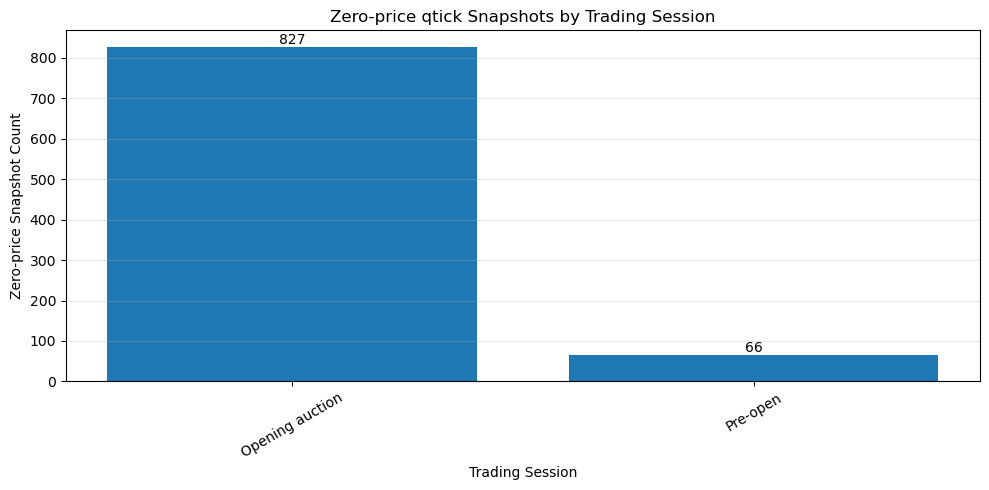

In [176]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    zero_price_session["trading_session"],
    zero_price_session["zero_price_count"]
)

for i, value in enumerate(zero_price_session["zero_price_count"]):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

ax.set_title("Zero-price qtick Snapshots by Trading Session")
ax.set_xlabel("Trading Session")
ax.set_ylabel("Zero-price Snapshot Count")

ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

No negative values were identified in the core price, volume, or amount fields across `qtick`, `qknock`, and `qorder`.

Zero values, however, show strong field- and time-dependent patterns.

In `qtick`, `new_price`, `open`, `sum_volume`, and `sum_amount` contain 893 zero observations. Zero-price snapshots are concentrated around the pre-open and opening auction periods, particularly between 09:15 and 09:25.

The `close` field is zero for all 102,485 qtick observations, indicating that this field is not populated as an intraday snapshot price in the local qtick schema.

### Analysis

The systematic concentration of zero prices around the opening auction suggests a market-state or field-population convention rather than random data corruption.

In addition, the fully zero-valued `close` field confirms that `close` should not be interpreted as the current snapshot price in `qtick`. The appropriate intraday price field is `new_price`.

This also explains why the earlier external validation compared local `new_price` with the CoralDB minute `close` field rather than directly comparing fields with identical names.

### Conclusion

The basic non-negativity validation passes.

Observed zero values are primarily explained by field availability and special trading-state conventions. No evidence of negative-value corruption is identified.

**Classification: Field Definition Difference / Special Trading State, rather than Data Error.**

## 6.4 Timestamp and Sequence Consistency（时间与记录顺序验证）

Market-data records should generally follow chronological order within each trading day.

This section checks the original record sequence before any explicit sorting operation. The objective is to identify timestamp reversals or sequence inconsistencies that may indicate ingestion, storage, or ordering issues.

需要注意的是，同一 timestamp 下存在多条记录并不一定构成异常。例如，逐笔成交数据中可能在同一毫秒发生多笔成交。因此，本节检查的是 timestamp reversal，而不是 timestamp uniqueness。

In [177]:
sequence_tables = {
    "qtick": qtick.copy(),
    "qknock": qknock.copy(),
    "qorder": qorder.copy()
}

sequence_results = []
sequence_details = {}

for table_name, df in sequence_tables.items():

    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    df["time"] = pd.to_datetime(
        df["time"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["date", "time"]
    ).copy()

    df["datetime"] = df.apply(
        lambda x: pd.Timestamp.combine(
            x["date"].date(),
            x["time"].time()
        ),
        axis=1
    )

    # IMPORTANT:
    # preserve original dataframe order
    df["_original_position"] = range(len(df))

    # compare each timestamp with the previous row
    # within the same trading day
    df["previous_datetime"] = (
        df
        .groupby("date")["datetime"]
        .shift(1)
    )

    df["timestamp_reversal"] = (
        df["datetime"]
        < df["previous_datetime"]
    )

    reversal_rows = df[
        df["timestamp_reversal"]
    ].copy()

    sequence_results.append({
        "table": table_name,
        "total_rows": len(df),
        "trading_days": df["date"].nunique(),
        "timestamp_reversal_count": len(reversal_rows),
        "timestamp_reversal_rate": (
            len(reversal_rows) / len(df)
            if len(df) > 0
            else np.nan
        )
    })

    sequence_details[table_name] = reversal_rows


sequence_summary = pd.DataFrame(sequence_results)

sequence_summary

,table,total_rows,trading_days,timestamp_reversal_count,timestamp_reversal_rate
0,qtick,102485,22,0,0.0
1,qknock,735794,22,0,0.0
2,qorder,819766,22,0,0.0


In [178]:
for table_name, reversal_df in sequence_details.items():

    print(f"\n===== {table_name} =====")

    if len(reversal_df) == 0:
        print("No timestamp reversal identified.")

    else:
        display(
            reversal_df[
                [
                    "date",
                    "previous_datetime",
                    "datetime",
                    "_original_position"
                ]
            ].head(20)
        )


===== qtick =====
No timestamp reversal identified.

===== qknock =====
No timestamp reversal identified.

===== qorder =====
No timestamp reversal identified.


In [179]:
same_timestamp_results = []

for table_name, df in sequence_tables.items():

    temp = df.copy()

    temp["date"] = pd.to_datetime(
        temp["date"],
        errors="coerce"
    )

    temp["time"] = pd.to_datetime(
        temp["time"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=["date", "time"]
    )

    timestamp_count = (
        temp
        .groupby(["date", "time"])
        .size()
        .reset_index(name="record_count")
    )

    repeated_timestamp = timestamp_count[
        timestamp_count["record_count"] > 1
    ]

    same_timestamp_results.append({
        "table": table_name,
        "unique_timestamps": len(timestamp_count),
        "repeated_timestamps": len(repeated_timestamp),
        "max_records_same_timestamp": (
            timestamp_count["record_count"].max()
        )
    })


same_timestamp_summary = pd.DataFrame(
    same_timestamp_results
)

same_timestamp_summary

,table,unique_timestamps,repeated_timestamps,max_records_same_timestamp
0,qtick,102485,0,1
1,qknock,366365,91667,521
2,qorder,618187,63756,158


### Observation（现象）

No timestamp reversals are identified in `qtick`, `qknock`, or `qorder`. All three tables preserve chronological record ordering within each trading day.

The same-timestamp analysis, however, shows substantial differences across table types. `qtick` contains 102,485 unique timestamps for 102,485 records, with at most one snapshot per timestamp.

In contrast, `qknock` contains 91,667 repeated timestamps and up to 521 transaction records at the same timestamp. `qorder` contains 63,756 repeated timestamps and up to 158 order records at the same timestamp.

### Analysis（分析）

The absence of timestamp reversals indicates that the raw record sequence is chronologically consistent and provides no evidence of out-of-order ingestion or sequence corruption.

Repeated timestamps in `qknock` and `qorder` are not necessarily duplicate records. Transaction-level and order-level datasets may contain multiple market events within the same timestamp resolution.

This behavior is consistent with the different data granularities of the three tables:

- `qtick`: snapshot-level market state
- `qknock`: transaction-level execution records
- `qorder`: order-level market events

Therefore, timestamp uniqueness is appropriate for `qtick` but should not be used as a duplicate criterion for `qknock` or `qorder`.

### Conclusion（结论）

Timestamp ordering validation passes for all three local market-data tables.

Repeated timestamps in transaction and order data are consistent with event-level market-data structure rather than sequence errors.

Duplicate validation should therefore rely on table-specific business identifiers rather than timestamps alone.

**Classification: No Data Error Identified / Expected Data Granularity Difference.**

## 6.5 Business-key Duplicate Validation（业务主键重复验证）

Repeated timestamps do not necessarily represent duplicate market events. This section evaluates duplicate records using table-specific business identifiers.

The validation keys are defined as:

- `qtick`: `code + date + time`
- `qknock`: `match_no`
- `qorder`: `order_no`

The objective is to distinguish legitimate same-timestamp market activity from potential duplicate ingestion or repeated records.

In [184]:
duplicate_config = {
    "qtick": ["code", "date", "time"],
    "qknock": ["code", "date", "match_no"],
    "qorder": ["code", "date", "order_no"]
}

duplicate_results = []
duplicate_details = {}

for table_name, key_cols in duplicate_config.items():

    df = logic_tables[table_name].copy()

    available_keys = [
        col for col in key_cols
        if col in df.columns
    ]

    if len(available_keys) != len(key_cols):
        print(
            f"{table_name}: missing duplicate key columns"
        )
        continue

    duplicate_mask = df.duplicated(
        subset=key_cols,
        keep=False
    )

    duplicate_rows = df[
        duplicate_mask
    ].copy()

    duplicate_key_count = (
        duplicate_rows[key_cols]
        .drop_duplicates()
        .shape[0]
    )

    duplicate_results.append({
        "table": table_name,
        "business_key": " + ".join(key_cols),
        "total_rows": len(df),
        "duplicate_rows": len(duplicate_rows),
        "duplicate_business_keys": duplicate_key_count,
        "duplicate_row_rate": (
            len(duplicate_rows) / len(df)
            if len(df) > 0
            else np.nan
        )
    })

    duplicate_details[table_name] = duplicate_rows


duplicate_summary = pd.DataFrame(
    duplicate_results
)

duplicate_summary

,table,business_key,total_rows,duplicate_rows,duplicate_business_keys,duplicate_row_rate
0,qtick,code + date + time,102485,0,0,0.0
1,qknock,code + date + match_no,735794,0,0,0.0
2,qorder,code + date + order_no,819766,0,0,0.0


In [185]:
for table_name, duplicate_df in duplicate_details.items():

    print(f"\n===== {table_name} =====")

    if len(duplicate_df) == 0:
        print("No duplicated business key identified.")

    else:
        print(
            f"Duplicated rows: {len(duplicate_df):,}"
        )

        display(
            duplicate_df.head(20)
        )


===== qtick =====
No duplicated business key identified.

===== qknock =====
No duplicated business key identified.

===== qorder =====
No duplicated business key identified.


In [186]:
identifier_config = {
    "qknock": "match_no",
    "qorder": "order_no"
}

identifier_scope_results = []

for table_name, id_col in identifier_config.items():

    df = logic_tables[table_name].copy()

    # Number of unique trading days associated with each identifier
    id_day_count = (
        df.groupby(id_col)["date"]
        .nunique()
        .reset_index(name="trading_day_count")
    )

    repeated_across_days = (
        id_day_count["trading_day_count"] > 1
    ).sum()

    max_days_per_id = (
        id_day_count["trading_day_count"].max()
    )

    # Check duplicate identifier within the same trading day
    within_day_duplicate_mask = df.duplicated(
        subset=["date", id_col],
        keep=False
    )

    within_day_duplicate_rows = df[
        within_day_duplicate_mask
    ].copy()

    within_day_duplicate_keys = (
        within_day_duplicate_rows[
            ["date", id_col]
        ]
        .drop_duplicates()
        .shape[0]
    )

    identifier_scope_results.append({
        "table": table_name,
        "identifier": id_col,
        "identifiers_reused_across_days": repeated_across_days,
        "max_trading_days_per_identifier": max_days_per_id,
        "within_day_duplicate_rows": len(within_day_duplicate_rows),
        "within_day_duplicate_keys": within_day_duplicate_keys
    })


identifier_scope_summary = pd.DataFrame(
    identifier_scope_results
)

identifier_scope_summary

,table,identifier,identifiers_reused_across_days,max_trading_days_per_identifier,within_day_duplicate_rows,within_day_duplicate_keys
0,qknock,match_no,5318,3,0,0
1,qorder,order_no,6486,3,0,0


In [187]:
# =========================
# Inspect Cross-day Reused Identifiers
# =========================

for table_name, id_col in identifier_config.items():

    df = logic_tables[table_name].copy()

    reused_ids = (
        df.groupby(id_col)["date"]
        .nunique()
    )

    reused_ids = reused_ids[
        reused_ids > 1
    ].index

    reused_sample = (
        df[df[id_col].isin(reused_ids)]
        .sort_values([id_col, "date"])
    )

    print(f"\n===== {table_name} =====")

    if len(reused_sample) == 0:
        print("No cross-day identifier reuse identified.")

    else:
        display(
            reused_sample.head(20)
        )


===== qknock =====


,code,date,time,match_no,bid_order_no,ask_order_no,match_price,match_volume,datetime
240125,000009.SZ,2026-03-19,1970-01-01 09:25:00.000,602377,33487,432696,90000,400,2026-03-19 09:25:00.000
312530,000009.SZ,2026-03-23,1970-01-01 09:30:00.050,602377,399236,0,0,1400,2026-03-23 09:30:00.050
240198,000009.SZ,2026-03-19,1970-01-01 09:25:00.000,602427,524580,597560,90000,3300,2026-03-19 09:25:00.000
312527,000009.SZ,2026-03-23,1970-01-01 09:30:00.050,602427,265219,602426,88100,900,2026-03-23 09:30:00.050
240162,000009.SZ,2026-03-19,1970-01-01 09:25:00.000,602455,386477,588677,90000,2000,2026-03-19 09:25:00.000
394397,000009.SZ,2026-03-25,1970-01-01 09:30:00.120,602455,268515,602454,87600,100,2026-03-25 09:30:00.120
240164,000009.SZ,2026-03-19,1970-01-01 09:25:00.000,602456,401477,588677,90000,100,2026-03-19 09:25:00.000
394398,000009.SZ,2026-03-25,1970-01-01 09:30:00.120,602456,279289,602454,87600,2000,2026-03-25 09:30:00.120
240168,000009.SZ,2026-03-19,1970-01-01 09:25:00.000,602457,422826,588677,90000,1000,2026-03-19 09:25:00.000
394399,000009.SZ,2026-03-25,1970-01-01 09:30:00.120,602457,281282,602454,87600,3600,2026-03-25 09:30:00.120



===== qorder =====


,code,date,time,order_no,bs_flag,order_type,order_price,order_volume
639011,000009.SZ,2026-04-02,1970-01-01 09:15:00.010,979,2,0,89200.0,5300
714514,000009.SZ,2026-04-08,1970-01-01 09:15:00.030,979,2,0,93500.0,100
502057,000009.SZ,2026-03-27,1970-01-01 09:15:00.040,1486,2,0,96000.0,300
639014,000009.SZ,2026-04-02,1970-01-01 09:15:00.020,1486,2,0,96900.0,200
197804,000009.SZ,2026-03-17,1970-01-01 09:15:00.040,2243,2,0,102000.0,100
397948,000009.SZ,2026-03-24,1970-01-01 09:15:00.040,2243,2,0,89900.0,100
2,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2293,1,0,91600.0,500
714516,000009.SZ,2026-04-08,1970-01-01 09:15:00.040,2293,2,0,86000.0,22200
437765,000009.SZ,2026-03-25,1970-01-01 09:15:00.050,7197,2,0,96100.0,1000
502070,000009.SZ,2026-03-27,1970-01-01 09:15:00.050,7197,2,0,96800.0,100


### Conclusion

Initial duplicate checks using `match_no` and `order_no` alone identified approximately 1.5% repeated identifiers in `qknock` and `qorder`.

进一步检查 identifier scope 后发现，这些重复编号均发生在不同交易日之间。`qknock` 中共有 5,318 个 `match_no` 被跨交易日复用，`qorder` 中共有 6,486 个 `order_no` 被跨交易日复用，部分编号最多出现在 3 个不同交易日。

However, no identifier duplication is observed within the same trading day.

因此，`match_no` 与 `order_no` 并非 globally unique identifiers，而是具有 trading-day scope。单独使用编号进行重复记录检测会产生 false duplicate classification。

The business keys are therefore redefined as:

- `qtick`: `code + date + time`
- `qknock`: `code + date + match_no`
- `qorder`: `code + date + order_no`

Under the corrected composite business keys, no duplicated market records are identified.

### Difference Classification

**Identifier scope / field semantics difference**

The initially observed duplicate records are not data errors. They arise from the reuse of transaction and order identifiers across trading days.

## 6.6 Price Limit and Boundary Validation（涨跌停与价格边界验证）

Price observations should remain within the applicable daily upper and lower price limits under normal trading conditions.

This section validates whether snapshot prices and transaction prices violate the daily price-limit boundaries recorded in `qtick`.

The analysis first identifies direct boundary violations and then examines observations close to the upper or lower price limits.

价格突破涨跌停边界可能反映数据错误、价格单位问题或复权口径差异；而价格集中在涨跌停附近则可能属于正常的 limit-state market behavior，需要进一步结合交易状态解释。

In [188]:
limit_reference = qtick.copy()

limit_reference["date"] = pd.to_datetime(
    limit_reference["date"],
    errors="coerce"
)

for col in [
    "upper_limit",
    "lower_limit",
    "pre_close"
]:
    limit_reference[col] = pd.to_numeric(
        limit_reference[col],
        errors="coerce"
    )

limit_reference = (
    limit_reference
    .groupby(["code", "date"], as_index=False)
    .agg(
        upper_limit=("upper_limit", "first"),
        lower_limit=("lower_limit", "first"),
        pre_close=("pre_close", "first")
    )
)

limit_reference.head()

,code,date,upper_limit,lower_limit,pre_close
0,000009.SZ,2026-03-11,10.10,8.26,9.18
1,000009.SZ,2026-03-12,10.22,8.36,9.29
2,000009.SZ,2026-03-13,10.11,8.27,9.19
3,000009.SZ,2026-03-16,10.42,8.52,9.47
4,000009.SZ,2026-03-17,10.32,8.44,9.38


In [190]:
# Daily Price-limit Field Consistency
limit_consistency = (
    qtick
    .groupby(["code", "date"])
    .agg(
        upper_limit_unique=("upper_limit", "nunique"),
        lower_limit_unique=("lower_limit", "nunique")
    )
    .reset_index()
)

limit_consistency_summary = pd.DataFrame({
    "metric": [
        "Trading days",
        "Days with multiple upper_limit values",
        "Days with multiple lower_limit values"
    ],
    "value": [
        len(limit_consistency),
        (limit_consistency["upper_limit_unique"] > 1).sum(),
        (limit_consistency["lower_limit_unique"] > 1).sum()
    ]
})

limit_consistency_summary

,metric,value
0,Trading days,22
1,Days with multiple upper_limit values,0
2,Days with multiple lower_limit values,0


In [191]:
# qtick Price Boundary Validation
qtick_limit = qtick.copy()

qtick_limit["date"] = pd.to_datetime(
    qtick_limit["date"],
    errors="coerce"
)

for col in [
    "new_price",
    "upper_limit",
    "lower_limit"
]:
    qtick_limit[col] = pd.to_numeric(
        qtick_limit[col],
        errors="coerce"
    )

qtick_limit_valid = qtick_limit[
    qtick_limit["new_price"] > 0
].copy()

qtick_limit_valid["above_upper_limit"] = (
    qtick_limit_valid["new_price"]
    > qtick_limit_valid["upper_limit"]
)

qtick_limit_valid["below_lower_limit"] = (
    qtick_limit_valid["new_price"]
    < qtick_limit_valid["lower_limit"]
)

qtick_boundary_summary = pd.DataFrame({
    "metric": [
        "Valid positive-price snapshots",
        "Above upper-limit snapshots",
        "Below lower-limit snapshots",
        "Total boundary violations"
    ],
    "value": [
        len(qtick_limit_valid),
        qtick_limit_valid["above_upper_limit"].sum(),
        qtick_limit_valid["below_lower_limit"].sum(),
        (
            qtick_limit_valid["above_upper_limit"]
            | qtick_limit_valid["below_lower_limit"]
        ).sum()
    ]
})

qtick_boundary_summary

,metric,value
0,Valid positive-price snapshots,101592
1,Above upper-limit snapshots,0
2,Below lower-limit snapshots,0
3,Total boundary violations,0


In [192]:
# qknock Trade-price Boundary Validation
qknock_limit = qknock.copy()

qknock_limit["date"] = pd.to_datetime(
    qknock_limit["date"],
    errors="coerce"
)

qknock_limit["match_price"] = pd.to_numeric(
    qknock_limit["match_price"],
    errors="coerce"
)

qknock_limit["trade_price"] = (
    qknock_limit["match_price"] / 10000
)

qknock_limit = qknock_limit.merge(
    limit_reference[
        [
            "code",
            "date",
            "upper_limit",
            "lower_limit"
        ]
    ],
    on=["code", "date"],
    how="left"
)

# match_price = 0 was previously identified
# as a non-trade / special record convention
qknock_trade_valid = qknock_limit[
    qknock_limit["trade_price"] > 0
].copy()

qknock_trade_valid["above_upper_limit"] = (
    qknock_trade_valid["trade_price"]
    > qknock_trade_valid["upper_limit"]
)

qknock_trade_valid["below_lower_limit"] = (
    qknock_trade_valid["trade_price"]
    < qknock_trade_valid["lower_limit"]
)

qknock_boundary_summary = pd.DataFrame({
    "metric": [
        "Valid positive-price transactions",
        "Above upper-limit transactions",
        "Below lower-limit transactions",
        "Total boundary violations"
    ],
    "value": [
        len(qknock_trade_valid),
        qknock_trade_valid["above_upper_limit"].sum(),
        qknock_trade_valid["below_lower_limit"].sum(),
        (
            qknock_trade_valid["above_upper_limit"]
            | qknock_trade_valid["below_lower_limit"]
        ).sum()
    ]
})

qknock_boundary_summary

,metric,value
0,Valid positive-price transactions,530911
1,Above upper-limit transactions,0
2,Below lower-limit transactions,0
3,Total boundary violations,0


In [193]:
# Price Boundary Validation Summary
price_boundary_summary = pd.DataFrame({
    "table": [
        "qtick",
        "qknock"
    ],
    "price_field": [
        "new_price",
        "trade_price"
    ],
    "valid_price_records": [
        len(qtick_limit_valid),
        len(qknock_trade_valid)
    ],
    "above_upper_limit": [
        qtick_limit_valid["above_upper_limit"].sum(),
        qknock_trade_valid["above_upper_limit"].sum()
    ],
    "below_lower_limit": [
        qtick_limit_valid["below_lower_limit"].sum(),
        qknock_trade_valid["below_lower_limit"].sum()
    ]
})

price_boundary_summary["total_violations"] = (
    price_boundary_summary["above_upper_limit"]
    + price_boundary_summary["below_lower_limit"]
)

price_boundary_summary["violation_rate"] = (
    price_boundary_summary["total_violations"]
    / price_boundary_summary["valid_price_records"]
)

price_boundary_summary

,table,price_field,valid_price_records,above_upper_limit,below_lower_limit,total_violations,violation_rate
0,qtick,new_price,101592,0,0,0,0.0
1,qknock,trade_price,530911,0,0,0,0.0


In [194]:
# Near-limit Price Behavior
qtick_limit_valid["distance_to_upper"] = (
    qtick_limit_valid["upper_limit"]
    - qtick_limit_valid["new_price"]
)

qtick_limit_valid["distance_to_lower"] = (
    qtick_limit_valid["new_price"]
    - qtick_limit_valid["lower_limit"]
)

qknock_trade_valid["distance_to_upper"] = (
    qknock_trade_valid["upper_limit"]
    - qknock_trade_valid["trade_price"]
)

qknock_trade_valid["distance_to_lower"] = (
    qknock_trade_valid["trade_price"]
    - qknock_trade_valid["lower_limit"]
)

near_limit_summary = pd.DataFrame({
    "table": [
        "qtick",
        "qknock"
    ],
    "at_upper_limit": [
        np.isclose(
            qtick_limit_valid["distance_to_upper"],
            0,
            atol=1e-8
        ).sum(),
        np.isclose(
            qknock_trade_valid["distance_to_upper"],
            0,
            atol=1e-8
        ).sum()
    ],
    "within_RMB_0.01_of_upper": [
        (
            qtick_limit_valid["distance_to_upper"]
            .between(0, 0.01)
        ).sum(),
        (
            qknock_trade_valid["distance_to_upper"]
            .between(0, 0.01)
        ).sum()
    ],
    "at_lower_limit": [
        np.isclose(
            qtick_limit_valid["distance_to_lower"],
            0,
            atol=1e-8
        ).sum(),
        np.isclose(
            qknock_trade_valid["distance_to_lower"],
            0,
            atol=1e-8
        ).sum()
    ],
    "within_RMB_0.01_of_lower": [
        (
            qtick_limit_valid["distance_to_lower"]
            .between(0, 0.01)
        ).sum(),
        (
            qknock_trade_valid["distance_to_lower"]
            .between(0, 0.01)
        ).sum()
    ]
})

near_limit_summary

,table,at_upper_limit,within_RMB_0.01_of_upper,at_lower_limit,within_RMB_0.01_of_lower
0,qtick,0,0,0,0
1,qknock,0,0,0,0


### Observation and Conclusion

Across the 22 trading days, `upper_limit` and `lower_limit` remain internally consistent within each trading day. No day contains multiple values for either daily price-limit field.

在有效正价格记录中，101,592 条 `qtick` snapshot records 与 530,911 条 `qknock` transaction records 均未出现价格突破当日涨跌停边界的情况。Therefore, no direct price-boundary violation is identified.

The result supports the internal consistency of the price fields and the daily price-limit reference. No evidence of price-unit error, adjustment-related boundary inconsistency, or invalid out-of-range transaction price is observed in the current sample.

### Near-limit Behavior

No snapshot or transaction price is observed exactly at, or within RMB 0.01 of, the daily upper or lower price limit.

因此，当前结果并不能说明数据已经通过“涨跌停状态下的数据行为验证”。更准确地说，the current 22-day sample does not contain a limit-state scenario.

The absence of near-limit observations represents a **sample coverage limitation rather than a data-quality issue**. A broader stock and trading-day sample would be required to validate data behavior during actual limit-up or limit-down periods.

### Difference Classification

**No data error identified.**

The price fields remain within valid daily trading boundaries. The lack of near-limit observations is classified as a **sample coverage limitation**, rather than a field-definition or data-quality difference.

## 6.7 Special Trading State Validation（特殊交易状态验证）

Market-data observations may behave differently during pre-open periods, trading halts, suspended sessions, or other special market states.

Rather than assuming the semantic meaning of status fields, this section first examines the observed state values and their associated price and trading behavior.

The objective is to determine whether previously identified unusual observations can be explained by special trading states or field-state conventions.

In [195]:
state_results = []

# qtick state
if "state" in qtick.columns:

    qtick_state = (
        qtick
        .groupby("state", dropna=False)
        .agg(
            row_count=("code", "size"),
            trading_days=("date", "nunique"),
            positive_price_count=(
                "new_price",
                lambda x: (pd.to_numeric(x, errors="coerce") > 0).sum()
            ),
            zero_price_count=(
                "new_price",
                lambda x: (pd.to_numeric(x, errors="coerce") == 0).sum()
            ),
            positive_volume_count=(
                "new_volume",
                lambda x: (pd.to_numeric(x, errors="coerce") > 0).sum()
            )
        )
        .reset_index()
    )

    qtick_state["table"] = "qtick"

    state_results.append(qtick_state)


# Coral status
if "status" in coral_qmin.columns:

    coral_state = (
        coral_qmin
        .groupby("status", dropna=False)
        .agg(
            row_count=("code", "size"),
            trading_days=("date", "nunique"),
            positive_price_count=(
                "new_price",
                lambda x: (pd.to_numeric(x, errors="coerce") > 0).sum()
            ),
            zero_price_count=(
                "new_price",
                lambda x: (pd.to_numeric(x, errors="coerce") == 0).sum()
            ),
            positive_volume_count=(
                "new_volume",
                lambda x: (pd.to_numeric(x, errors="coerce") > 0).sum()
            )
        )
        .reset_index()
    )

    coral_state = coral_state.rename(
        columns={"status": "state"}
    )

    coral_state["table"] = "CoralDB"

    state_results.append(coral_state)


trading_state_summary = pd.concat(
    state_results,
    ignore_index=True
)

trading_state_summary[
    [
        "table",
        "state",
        "row_count",
        "trading_days",
        "positive_price_count",
        "zero_price_count",
        "positive_volume_count"
    ]
]

,table,state,row_count,trading_days,positive_price_count,zero_price_count,positive_volume_count
0,qtick,0,102485,22,101592,893,74394
1,CoralDB,0,5280,22,5280,0,5253


In [196]:
# Trading State by Session
qtick_state_session = qtick.copy()

qtick_state_session["datetime"] = pd.to_datetime(
    qtick_state_session["datetime"],
    errors="coerce"
)

qtick_state_session["clock_time"] = (
    qtick_state_session["datetime"].dt.time
)


def classify_trading_session(t):

    if t < pd.Timestamp("09:15:00").time():
        return "Pre-open"

    elif t < pd.Timestamp("09:30:00").time():
        return "Opening auction"

    elif t <= pd.Timestamp("11:30:00").time():
        return "Morning continuous"

    elif t < pd.Timestamp("13:00:00").time():
        return "Lunch break"

    elif t <= pd.Timestamp("15:00:00").time():
        return "Afternoon continuous"

    else:
        return "Post-close"


qtick_state_session["trading_session"] = (
    qtick_state_session["clock_time"]
    .apply(classify_trading_session)
)


state_session_summary = (
    qtick_state_session
    .groupby(
        ["state", "trading_session"],
        dropna=False
    )
    .size()
    .reset_index(name="row_count")
    .sort_values(
        ["state", "row_count"],
        ascending=[True, False]
    )
)

state_session_summary

,state,trading_session,row_count
1,0,Morning continuous,51349
0,0,Afternoon continuous,50221
2,0,Opening auction,849
3,0,Pre-open,66


### Observation and Conclusion

Both `qtick.state` and CoralDB `status` remain equal to `0` across all observations in the current 22-day sample.

For `qtick`, `state = 0` is observed across pre-open, opening auction, morning continuous trading, and afternoon continuous trading sessions. Therefore, the observed state value does not distinguish trading sessions within the current sample.

同时，当前样本中未出现任何 non-zero state or status code。This means that the semantic meaning of alternative state values cannot be inferred from the available observations.

No evidence of trading suspension or other special trading states is identified in the current sample. However, this should not be interpreted as a full validation of special-state behavior.

### Investigation

The analysis initially considers whether unusual price or volume observations may be explained by special trading states.

However, `state = 0` covers all observed trading sessions and no alternative state values are present. Therefore, the current sample does not provide sufficient variation to investigate state-dependent market-data behavior.

A broader sample containing suspended securities or explicitly identified special trading sessions would be required to validate the semantic meaning and data behavior of non-zero state codes.

### Difference Classification

**Sample coverage limitation / field semantics unresolved**

No data error is identified. The current sample contains only the baseline state code (`0`), preventing validation of suspension or other special trading-state conventions.

## 6.8 Final Difference Classification（最终差异分类）

The field-level validation identifies several apparent anomalies and cross-source differences. Rather than treating all mismatches as data errors, the findings are classified according to their underlying causes.

最终分类区分真正的数据质量问题与由字段定义、时间聚合规则及样本覆盖范围导致的表观差异。

In [197]:
difference_classification = pd.DataFrame([
    {
        "validation_area": "Missing values",
        "observed_issue": "Almost no NULL values observed",
        "classification": "No data error",
        "interpretation": "Database-level preprocessing appears to remove or encode missing observations."
    },
    {
        "validation_area": "Zero price",
        "observed_issue": "893 zero-price qtick snapshots",
        "classification": "Field / state convention",
        "interpretation": "92.6% of zero-price observations occur during the opening auction and the remainder during pre-open."
    },
    {
        "validation_area": "qknock price scale",
        "observed_issue": "match_price approximately 10,000 times market price",
        "classification": "Field definition difference",
        "interpretation": "qknock match_price uses scaled integer price representation and requires division by 10,000."
    },
    {
        "validation_area": "Minute aggregation",
        "observed_issue": "Direct qknock-to-Coral minute comparison shows large differences",
        "classification": "Timestamp convention difference",
        "interpretation": "Coral minute bars use right-labeled intervals and the 09:31 bar includes the opening auction."
    },
    {
        "validation_area": "Opening minute residual",
        "observed_issue": "Residual volume and amount remain after auction reconstruction",
        "classification": "Timestamp convention difference",
        "interpretation": "Residuals correspond exactly to a late transaction block near the minute boundary."
    },
    {
        "validation_area": "Repeated identifiers",
        "observed_issue": "match_no and order_no repeat across the dataset",
        "classification": "Field semantics difference",
        "interpretation": "Identifiers are reused across trading days and are not globally unique. Composite business keys are required."
    },
    {
        "validation_area": "Price-limit boundary",
        "observed_issue": "No prices exceed daily upper or lower limits",
        "classification": "No data error",
        "interpretation": "All positive snapshot and transaction prices remain within valid daily trading boundaries."
    },
    {
        "validation_area": "Near-limit behavior",
        "observed_issue": "No observations near upper or lower price limits",
        "classification": "Sample coverage limitation",
        "interpretation": "The current sample does not contain a limit-state trading scenario."
    },
    {
        "validation_area": "Special trading state",
        "observed_issue": "Only state/status code 0 is observed",
        "classification": "Sample coverage limitation",
        "interpretation": "Suspension and other special-state behavior cannot be validated from the current sample."
    },
    {
        "validation_area": "Adjustment / corporate action",
        "observed_issue": "No adjustment-related price inconsistency identified",
        "classification": "No adjustment difference identified",
        "interpretation": "No evidence of an adjustment-related mismatch is observed in the current validation sample."
    }
])

difference_classification

,validation_area,observed_issue,classification,interpretation
0,Missing values,Almost no NULL values observed,No data error,Database-level preprocessing appears to remove...
1,Zero price,893 zero-price qtick snapshots,Field / state convention,92.6% of zero-price observations occur during ...
2,qknock price scale,"match_price approximately 10,000 times market ...",Field definition difference,qknock match_price uses scaled integer price r...
3,Minute aggregation,Direct qknock-to-Coral minute comparison shows...,Timestamp convention difference,Coral minute bars use right-labeled intervals ...
4,Opening minute residual,Residual volume and amount remain after auctio...,Timestamp convention difference,Residuals correspond exactly to a late transac...
5,Repeated identifiers,match_no and order_no repeat across the dataset,Field semantics difference,Identifiers are reused across trading days and...
6,Price-limit boundary,No prices exceed daily upper or lower limits,No data error,All positive snapshot and transaction prices r...
7,Near-limit behavior,No observations near upper or lower price limits,Sample coverage limitation,The current sample does not contain a limit-st...
8,Special trading state,Only state/status code 0 is observed,Sample coverage limitation,Suspension and other special-state behavior ca...
9,Adjustment / corporate action,No adjustment-related price inconsistency iden...,No adjustment difference identified,No evidence of an adjustment-related mismatch ...


In [198]:
# Classification Count Summary
classification_summary = (
    difference_classification
    .groupby("classification")
    .size()
    .reset_index(name="finding_count")
    .sort_values(
        "finding_count",
        ascending=False
    )
)

classification_summary

,classification,finding_count
4,No data error,2
5,Sample coverage limitation,2
6,Timestamp convention difference,2
0,Field / state convention,1
1,Field definition difference,1
2,Field semantics difference,1
3,No adjustment difference identified,1


### Final Conclusion

字段级验证未发现市场数据存在系统性损坏或无效的证据。

大多数明显的异常现象可归因于**字段定义差异、标识符作用域、市场状态约定或时间戳聚合规则**，而非底层数据错误。

最典型的例子包括 `qknock.match_price` 的整数缩放口径、`match_no` 与 `order_no` 的 trading-day identifier scope，以及 CoralDB minute bars 的时间窗口与开盘集合竞价纳入规则。

The investigation also demonstrates that exact cross-source comparison should only be performed after reconstructing the semantic and temporal definitions of each field.

No adjustment-related inconsistency or price-boundary violation is identified in the current sample. However, limit-state and special trading-state validation remain constrained by sample coverage because the selected stock and trading period contain no relevant scenarios.

总体而言，该数据集表现出很强的内部一致性。主要的验证风险并非明显的记录损坏，而是**在构建下游研究数据集时对字段语义或聚合规则的误解**。

可用规则：
1. qtick 当前价格用 new_price，不用 close
2. qknock 成交价用 match_price / 10000
3. qknock / qorder 查重必须加 code + date
4. 09:31 分钟数据要特别处理 opening auction allocation
5. qknock 聚分钟时要明确左闭右开还是右标签
6. 对 qtick snapshot 和 qknock trade 做对齐时，用 asof，而不是 exact timestamp
7. 看到 0 price 时先看 session，不要直接删
8. 做第三方对账时，先统一字段单位和时间窗口定义